# **<center>Predictive Modeling of Hotel Booking Cancellations for Strategic Revenue Optimization<center>**
<center><em>Hotel Booking Analytics</em></center>

## Import Library – Preparation

In [1]:
# Data Collection
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Splitting & Model Validation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold,cross_val_score, cross_validate
from sklearn.model_selection import cross_val_predict

# Pipeline & Feature Transformation
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Encoding & Scaling
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from category_encoders import BinaryEncoder
import category_encoders as ce

# Model Classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier,  RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression 

# Model Evaluation
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,log_loss,fbeta_score, make_scorer
)
from sklearn.metrics import roc_curve, precision_recall_curve, auc

import warnings
warnings.filterwarnings("ignore")

---
# **I. Business Understanding**
---
*Supervised Learning – Binary Classification*

## Latar Belakang

Industri perhotelan menghadapi tantangan signifikan dalam mengelola tingkat okupansi dan stabilitas pendapatan akibat tingginya tingkat pembatalan reservasi. Pembatalan berdampak langsung pada akurasi forecasting, perencanaan operasional, serta optimalisasi revenue.

Dataset `hotel bookings` digunakan untuk mendukung pendekatan berbasis data dalam memahami dan memprediksi perilaku pembatalan pemesanan hotel.

Dengan pendekatan analitik yang terstruktur, manajemen dapat meningkatkan akurasi perencanaan bisnis, meminimalkan risiko pendapatan, serta mengoptimalkan performa operasional hotel.


## Problem Statement

Tingkat pembatalan reservasi hotel yang tinggi menimbulkan ketidakpastian terhadap proyeksi okupansi dan pendapatan. Ketidakmampuan dalam mengidentifikasi pola serta faktor utama yang memengaruhi pembatalan menyebabkan keputusan bisnis—seperti pricing, alokasi kamar, kebijakan deposit, dan strategi distribusi—menjadi kurang optimal.

Manajemen belum memiliki:
- Identifikasi faktor kunci yang secara signifikan memengaruhi pembatalan
- Segmentasi pelanggan berdasarkan tingkat risiko pembatalan
- Proyeksi probabilitas pembatalan sebelum tanggal check-in
- Insight berbasis data untuk mengoptimalkan strategi overbooking

Sehingga, hotel berisiko mengalami:
- Revenue loss akibat kamar yang kosong mendadak
- Inefisiensi operasional dalam perencanaan kapasitas
- Strategi pemasaran dan distribusi yang kurang tepat sasaran
- Forecasting okupansi yang tidak akurat

**Permasalahan utama yang perlu diselesaikan adalah:**

> ***Bagaimana mengidentifikasi dan memprediksi pembatalan reservasi hotel secara akurat untuk mengurangi risiko kehilangan pendapatan serta meningkatkan efektivitas strategi pricing, distribusi, dan operasional?***

## Objective
- Memprediksi probabilitas pembatalan sebelum tanggal check-in *(Predict Cancellation Risk)*.
- Mengidentifikasi faktor yang paling mempengaruhi pembatalan reservasi *(Understand Key Drivers)*.
- Mengurangi potensi kehilangan revenue akibat kamar kosong *(Protect Revenue)*.

## Success Metrics

1. **Model Performance Metrics**
    - Primary Metrics
        - Recall (Cancellation Class = 1)
        - Accuracy
        - F2-Score
    - Secondary Metrics
        - AUC-ROC → Mengukur kemampuan model membedakan cancel vs non-cancel
        - Precision → Menghindari terlalu banyak false alarm
        - Confusion Matrix → Untuk melihat trade-off bisnis

2. **Business Impact (Financial)**
    - Revenue Protection
        - Penurunan cancellation loss (%)
        - Peningkatan Occupancy Rate
        - Peningkatan RevPAR (Revenue per Available Room)
    - Risk Management
        - Penurunan jumlah kamar kosong akibat no-show
        - Akurasi strategi overbooking

3. **Decision & Strategy Metrics (Manajerial)**
    - Implementasi kebijakan deposit berbasis risk level
    - Optimasi channel distribution
    - Perubahan pricing berdasarkan segment risk

<div style="text-align: center; font-size: 48px;">
    ⬇️ 
</div>

### *1. Model Performance Metrics*

| Metric                        | Hasil                         | Interpretasi Bisnis                                                                                                               |
| ----------------------------- | ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| **Recall (Cancellation = 1)** | 0.935                         | Hampir semua pembatalan tertangkap → intervensi bisa diterapkan lebih proaktif.                                                   |
| **Accuracy**                  | 0.729 (73%)                   | Model memprediksi dengan benar sekitar 73% dari seluruh kasus → cukup solid untuk operasional.                                    |
| **F1-Score**                  | 0.718                         | Keseimbangan precision dan recall cukup kuat → strategi mitigasi cukup efektif.                                                   |
| **F2-Score**                  | 0.834                         | Menekankan recall → model efektif menekan false negative, cocok untuk skenario bisnis yang memprioritaskan deteksi cancel.        |
| **Precision**                 | 0.583                         | Sekitar 58% prediksi high-risk benar-benar cancel → perlu mitigasi yang efisien agar pelanggan tidak terganggu.                   |
| **AUC-ROC**                   | 0.896                         | Model sangat baik membedakan cancel vs non-cancel → threshold dapat disesuaikan sesuai trade-off bisnis.                          |
| **PR-AUC**                    | 0.853                         | Mendukung fokus pada pembatalan di kelas imbalanced.                                                                              |
| **Confusion Matrix**          | [[13694, 8856], [865, 12402]] | Trade-off terlihat: menangkap hampir semua cancel tapi ada false alarms → membantu menyesuaikan strategi overbooking dan deposit. |

- **Recall 0.935 & F2-Score 0.834**
    > Model berhasil menangkap hampir semua pembatalan. Dari perspektif business analyst, ini menunjukkan kemampuan prediksi yang sangat baik untuk mitigasi risiko revenue loss. Tim operasional bisa fokus pada intervensi booking high-risk tanpa khawatir banyak pembatalan terlewat.

- **Accuracy 0.729 & F1-Score 0.718**
    > Secara keseluruhan, model memprediksi 73% booking dengan benar. F1-Score menunjukkan keseimbangan antara precision dan recall. Business analyst dapat menekankan bahwa meski ada false positives, trade-off ini masih diterima dalam konteks bisnis, karena kerugian akibat tidak mendeteksi cancel lebih mahal daripada intervensi tambahan.

- **Precision 0.583**
    > Hanya sekitar 58% prediksi high-risk benar-benar cancel. Artinya, strategi intervensi harus efisien, misalnya menggunakan deposit fleksibel atau reminder, agar pelanggan yang salah dikategorikan tidak terganggu.

- **AUC-ROC 0.896 & PR-AUC 0.853**
    > Model sangat baik membedakan cancel vs non-cancel, termasuk pada kelas imbalanced. Business analyst dapat menekankan: threshold ≥0.4 cukup optimal untuk memaksimalkan capture rate tanpa menimbulkan false alarms berlebihan.

- **Confusion Matrix**
    > Menunjukkan trade-off: hampir semua cancel tertangkap, tapi ada false positives. Insight: strategi overbooking dan deposit harus disesuaikan dengan kapasitas dan segmentasi pelanggan.

### *2. Business Impact (Financial)*

| Area                   | Insight / Recommendation                                                                                  | Dampak Potensial (Data Aktual)                                                                                                                |
| ---------------------- | --------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| **Revenue Protection** | Intervensi untuk booking high-risk (probabilitas cancel ≥0.4) melalui deposit, reminder, atau komunikasi. | - **Occupancy Rate**: 13.85% → 15.51% (**Uplift 11.98%**) <br> - **RevPAR**: €23.18 → €24.98 (**Uplift 7.79%**)                               |
| **Risk Management**    | Optimasi overbooking dan alokasi kamar berdasarkan probabilitas cancel.                                   | - **Cancellation Rate**: 37.04% → 29.63% (**Reduction 20%**) <br> - Mengurangi kamar kosong akibat no-show → efisiensi operasional meningkat. |

- **Revenue Protection**
    - Occupancy naik dari 13.85% → 15.51% (uplift 11.98%)
    - RevPAR naik dari €23.18 → €24.98 (uplift 7.79%)
    > Business analyst insight: Intervensi high-risk booking efektif menurunkan no-show. Dengan probabilitas cancel ≥0.4, tim revenue management dapat mengoptimalkan kapasitas kamar tanpa risiko overbooking berlebihan.

- **Risk Management**
    - Cancellation rate turun dari 37.04% → 29.63% (reduction 20%)
    - Mengurangi kamar kosong akibat no-show
    > Analisis: Model ini mendukung efisiensi operasional, mengurangi lost revenue akibat cancel, dan menyediakan dasar data-driven untuk keputusan overbooking, pricing, dan promosi.

### *3. Decision & Strategy Metrics (Manajerial)*

| Kebijakan / Strategi               | Rekomendasi                                                                                                                          | Efek Bisnis                                                            |
| ---------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------- |
| **Deposit berbasis risiko**        | Terapkan deposit/prepayment untuk probabilitas cancel tinggi (>0.6).                                                                 | Mengamankan revenue, mengurangi risiko loss.                           |
| **Optimasi channel distribution**  | Fokus promosi untuk channel low-risk, high-risk diberikan insentif cancel protection.                                                | Mengurangi cancelation impact per channel, meningkatkan ROI marketing. |
| **Dynamic pricing & segmentation** | Gunakan probabilitas cancel untuk menyesuaikan harga: diskon untuk low-risk, premium untuk high-risk jika ketersediaan kamar tinggi. | Meningkatkan RevPAR, mengurangi opportunistic cancellations.           |

- **Deposit / Prepayment berbasis risiko**
    - Strategi: Terapkan deposit untuk booking probabilitas cancel tinggi (≥0.4)
    - Efek: Revenue terlindungi, risiko loss berkurang, intervensi bersifat selektif → pelanggan low-risk tidak terganggu.

- **Optimasi Channel Distribution**
    - Strategi: Fokus promosi untuk channel low-risk, high-risk diberi insentif cancel protection.
    - Efek: Cancelation impact per channel berkurang, ROI marketing meningkat.

- **Dynamic Pricing & Segmentation**
    - Strategi: Diskon untuk low-risk, premium untuk high-risk jika room availability tinggi.
    - Efek: RevPAR meningkat, opportunistic cancellations berkurang, revenue management lebih presisi.

---
# **II. Data Understanding (EDA)**
---
Untuk memahami struktur, kualitas, dan karakteristik data. **Problem Type:** Supervised Learning – Binary Classification

## Fitur / variable pada data

| **Variable**                   | **Description**                                       | **Data Type**                    |
| ------------------------------ | ----------------------------------------------------- | -------------------------------- |
| hotel                          | Tipe hotel (H1 = Resort Hotel, H2 = City Hotel)       | Categorical (Nominal)            |
| is_canceled                    | Status pembatalan booking (1 = dibatalkan, 0 = tidak) | Binary                           |
| lead_time                      | Jumlah hari antara booking dan tanggal kedatangan     | Numerical (Integer)              |
| arrival_date_year              | Tahun kedatangan                                      | Numerical (Integer)              |
| arrival_date_month             | Bulan kedatangan                                      | Categorical (Ordinal/Time-based) |
| arrival_date_week_number       | Nomor minggu dalam tahun                              | Numerical (Integer)              |
| arrival_date_day_of_month      | Hari kedatangan                                       | Numerical (Integer)              |
| stays_in_weekend_nights        | Jumlah malam akhir pekan                              | Numerical (Integer)              |
| stays_in_week_nights           | Jumlah malam hari kerja                               | Numerical (Integer)              |
| adults                         | Jumlah tamu dewasa                                    | Numerical (Integer)              |
| children                       | Jumlah tamu anak-anak                                 | Numerical (Integer)              |
| babies                         | Jumlah bayi                                           | Numerical (Integer)              |
| meal                           | Tipe paket makan                                      | Categorical (Nominal)            |
| country                        | Negara asal (ISO format)                              | Categorical (Nominal)            |
| market_segment                 | Segmen pasar                                          | Categorical (Nominal)            |
| distribution_channel           | Channel distribusi booking                            | Categorical (Nominal)            |
| is_repeated_guest              | Indikator tamu repeat (1/0)                           | Binary                           |
| previous_cancellations         | Jumlah pembatalan sebelumnya                          | Numerical (Integer)              |
| previous_bookings_not_canceled | Jumlah booking sebelumnya tidak dibatalkan            | Numerical (Integer)              |
| reserved_room_type             | Kode tipe kamar yang dipesan                          | Categorical (Nominal)            |
| assigned_room_type             | Kode tipe kamar yang diberikan                        | Categorical (Nominal)            |
| booking_changes                | Jumlah perubahan booking                              | Numerical (Integer)              |
| deposit_type                   | Tipe deposit                                          | Categorical (Nominal)            |
| agent                          | ID agen travel                                        | Categorical (Nominal - ID)       |
| company                        | ID perusahaan pembayar                                | Categorical (Nominal - ID)       |
| days_in_waiting_list           | Jumlah hari dalam waiting list                        | Numerical (Integer)              |
| customer_type                  | Tipe booking                                          | Categorical (Nominal)            |
| adr                            | Average Daily Rate                                    | Numerical (Continuous / Float)   |
| required_car_parking_spaces    | Jumlah parkir yang dibutuhkan                         | Numerical (Integer)              |
| total_of_special_requests      | Jumlah permintaan khusus                              | Numerical (Integer)              |
| reservation_status             | Status akhir reservasi                                | Categorical (Nominal)            |
| reservation_status_date        | Tanggal perubahan status terakhir                     | DateTime                         |

**Target Variable `is_canceled`**
  - `0` → Booking terealisasi (stay)
  - `1` → Booking dibatalkan (is_Canceled)
  > Binary : Tidak Berururtan

**Tipe Hotel**

| Tipe | Deskripsi |
|------|-----------|
| City Hotel | Hotel yang terletak di kota, biasanya untuk tamu bisnis |
| Resort Hotel | Hotel resor, biasanya untuk tamu leisure/liburan |

**Kode Room Type**

| Kode | Deskripsi |
|------|-----------|
| A    | Tipe kamar standar / reguler |
| B    | Kamar superior atau deluxe |
| C    | Kamar premium / suite |
| D    | Kamar khusus atau upgrade paket |

**Distribution Channel**

| Channel | Deskripsi |
|---------|-----------|
| Direct | Booking langsung ke hotel |
| TA / Travel Agent | Agen perjalanan offline |
| Corporate | Booking perusahaan / kontrak |
| GDS (Global Distribution System) | Booking melalui jaringan global |
| Online TA / OTA | Booking melalui platform online |
| Other / undefined | Channel tidak jelas |

**Market Segment**

| Segment | Deskripsi |
|---------|-----------|
| Online TA / OTA | Pelanggan individual melalui OTA |
| Corporate | Perusahaan / kontrak |
| Direct | Booking langsung ke hotel |
| Groups | Booking grup / event |
| Offline TA / TO | Agen offline / tour operator |
| Complementary / Undefined / Other | Booking gratis, promosi, atau tidak jelas |
  - > *TA (Travel Agent) → Agen perjalanan, bisa offline atau online, yang memesan kamar atas nama tamu.*
  - > *TO (Tour Operator) → Operator tur atau paket wisata, biasanya memesan kamar untuk grup atau paket liburan yang sudah dikombinasikan dengan transportasi dan kegiatan wisata.*

**Meal**
| Paket | Deskripsi |
|-------|-----------|
| BB (Bed & Breakfast) | Sarapan termasuk |
| HB (Half Board) | Sarapan + makan malam |
| FB (Full Board) | Semua makan termasuk |
| SC (Self Catering / No Meal) | Tidak termasuk makan |

**Deposit Type**
| Deposit | Deskripsi |
|---------|-----------|
| No Deposit | Tidak ada uang jaminan |
| Refundable | Deposit bisa dikembalikan |
| Non-Refund | Deposit tidak bisa dikembalikan |

**Customer Type**
| Type | Deskripsi |
|------|-----------|
| Transient | Tamu individu / short-stay |
| Contract / Group | Booking grup / kontrak |
| Transient-Party | Tamu individu untuk event / party |
| Group | Booking grup leisure atau event |

**Arrival Year & Month**
| Tahun | Periode Bulan|
|-------|--------------|
| 2015  | July – Desember |
| 2016  | Januari – Desember |
| 2017  | Januari – Augustus |
  - > *Setiap tahun-nya memiliki range bulan yang berbeda-beda*

## Load Data

In [2]:
# Load data
df = pd.read_csv('hotel_bookings.csv')

# Preview data
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


**Interpretasi Preview Data:**
| Aspek           | Interpretasi                                            |
| --------------- | --------------------------------------------------------|
| Total Observasi | 119.390 baris                                           |
| Total Variabel  | 32 kolom                                                |
| Jenis Hotel     | Resort Hotel dan City Hotel                             |
| Target          | `is_canceled` (biner: 0 = tidak cancel, 1 = is_cancel)  |
| Rentang Tahun   | 2015 – 2017                                             |
| Tipe Data       | Campuran numerik & kategorikal                          |


In [3]:
display(df.shape)
display(df.describe())
df.info()

(119390, 32)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

**Interpretasi Output:**

1. Data Shape
    - 119.390 baris (rows) data reservasi → jumlah observasi / record / transaksi dalam dataset.
    - 32 kolom (columns) → jumlah variabel / fitur / atribut yang menjelaskan setiap observasi.

2. Ringkasan Data Describe

| Variabel                           | Mean   | Median (50%) | Min–Max    | Insight Utama                           | Implikasi Analitis                        |
| ---------------------------------- | ------ | ------------ | ---------- | --------------------------------------- | ----------------------------------------- |
| **is_canceled**                    | 0.37   | 0            | 0–1        | 37% booking dibatalkan                  | Target cukup signifikan untuk klasifikasi |
| **lead_time**                      | 104    | 69           | 0–737      | Variasi sangat besar, right-skewed      | Kandidat prediktor kuat                   |
| **arrival_date_year**              | 2016   | 2016         | 2015–2017  | Data 3 tahun                            | Bisa analisis tren waktu                  |
| **arrival_date_week_number**       | 27     | 28           | 1–53       | Distribusi tahunan lengkap              | Cocok untuk seasonality analysis          |
| **arrival_date_day_of_month**      | 15.8   | 16           | 1–31       | Distribusi normal tanggal               | Tidak terlalu ekstrem                     |
| **stays_in_weekend_nights**        | 0.93   | 1            | 0–19       | Rata-rata 1 malam weekend               | Mayoritas short stay                      |
| **stays_in_week_nights**           | 2.50   | 2            | 0–50       | 2–3 malam weekday                       | Ada outlier long stay                     |
| **adults**                         | 1.85   | 2            | 0–55       | Umumnya 2 orang                         | Ada outlier (55)                          |
| **children**                       | 0.10   | 0            | 0–10       | Jarang membawa anak                     | Tidak terlalu dominan                     |
| **babies**                         | 0.008  | 0            | 0–10       | Sangat jarang                           | Dampak kecil                              |
| **is_repeated_guest**              | 0.03   | 0            | 0–1        | Hanya 3% repeat guest                   | Mayoritas first-time                      |
| **previous_cancellations**         | 0.087  | 0            | 0–26       | Hampir semua tidak punya histori cancel | Variabel potensial                        |
| **previous_bookings_not_canceled** | 0.137  | 0            | 0–72       | Sedikit histori booking sukses          | Bisa bantu prediksi                       |
| **booking_changes**                | 0.22   | 0            | 0–21       | Mayoritas tidak ada perubahan           | Perubahan bisa indikasi risiko            |
| **agent**                          | 86.69  | 14           | 1–535      | Banyak missing                          | Perlu treatment                           |
| **company**                        | 189.26 | 179          | 6–543      | Missing sangat besar                    | Perlu drop atau recode                    |
| **days_in_waiting_list**           | 2.32   | 0            | 0–391      | Mayoritas tidak waiting list            | Ada outlier                               |
| **adr**                            | 101.83 | 94.58        | -6.38–5400 | Ada nilai negatif & outlier ekstrem     | Wajib outlier handling                    |
| **required_car_parking_spaces**    | 0.06   | 0            | 0–8        | Hampir semua tidak butuh parkir         | Variabel minor                            |
| **total_of_special_requests**      | 0.57   | 0            | 0–5        | Rata-rata 0–1 request                   | Bisa indikasi engagement                  |

3. Ringkasan Data Info
    
| Tipe Data   | Jumlah Kolom | Nama Kolom                                                                                                                                                                                                                                                                                                                              |
| ----------- | ------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| int64   | 16           | is_canceled, lead_time, arrival_date_year, arrival_date_week_number, arrival_date_day_of_month, stays_in_weekend_nights, stays_in_week_nights, adults, babies, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, booking_changes, days_in_waiting_list, required_car_parking_spaces, total_of_special_requests |
| float64 | 4            | children, agent, company, adr                                                                                                                                                                                                                                                                                                           |
| object **(Need to Encoding)**  | 12           | hotel, arrival_date_month, meal, country, market_segment, distribution_channel, reserved_room_type, assigned_room_type, deposit_type, customer_type, reservation_status, reservation_status_date                                                                                                                                        |

- Missing Value

    | Kolom    | Persentase Missing | Tindakan                                   |
    | -------- | ------------------ | -------------------------------------------|
    | country  | ~0.4%              | Imputasi kategori baru                     |
    | agent    | ~13.7%             | Imputasi atau recode ("Unknown")           |
    | company  | ~94%               | Drop atau buat binary indicator ("Unknown")|


## Target Distribution Before Treatment

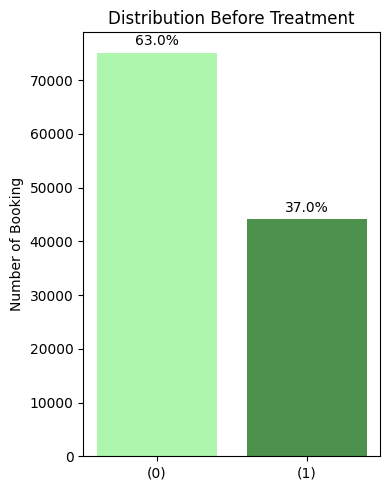

In [4]:
# Visualization dengan pin point percentage dan series churn tegak lurus
plt.figure(figsize=(4, 5))

# Hitung value counts dan persentase
canceled_counts_counts = df['is_canceled'].value_counts()
canceled_percentage = df['is_canceled'].value_counts(normalize=True) * 100

# Bar chart tegak lurus
bars = plt.bar(['(0)', '(1)'], 
               canceled_counts_counts.values,
               color=["#8CF18C", "#006400"],
               alpha=0.7)

# Pin point percentage
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + max(canceled_counts_counts.values)*0.01,
             f'{canceled_percentage[i]:.1f}%',
             ha='center',
             va='bottom',
             fontsize=10)

plt.title("Distribution Before Treatment")
plt.ylabel("Number of Booking")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0)

plt.tight_layout()
plt.show()

In [5]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

## Univariate Boxplot Before Treatment

Total kolom numerik: 20 feature


,Feature,Outlier Count,Outlier %
7,adults,29710,24.88
13,booking_changes,18076,15.14
8,children,8590,7.19
18,required_car_parking_spaces,7416,6.21
11,previous_cancellations,6484,5.43
10,is_repeated_guest,3810,3.19
17,adr,3793,3.18
16,days_in_waiting_list,3698,3.10
12,previous_bookings_not_canceled,3620,3.03
6,stays_in_week_nights,3354,2.81


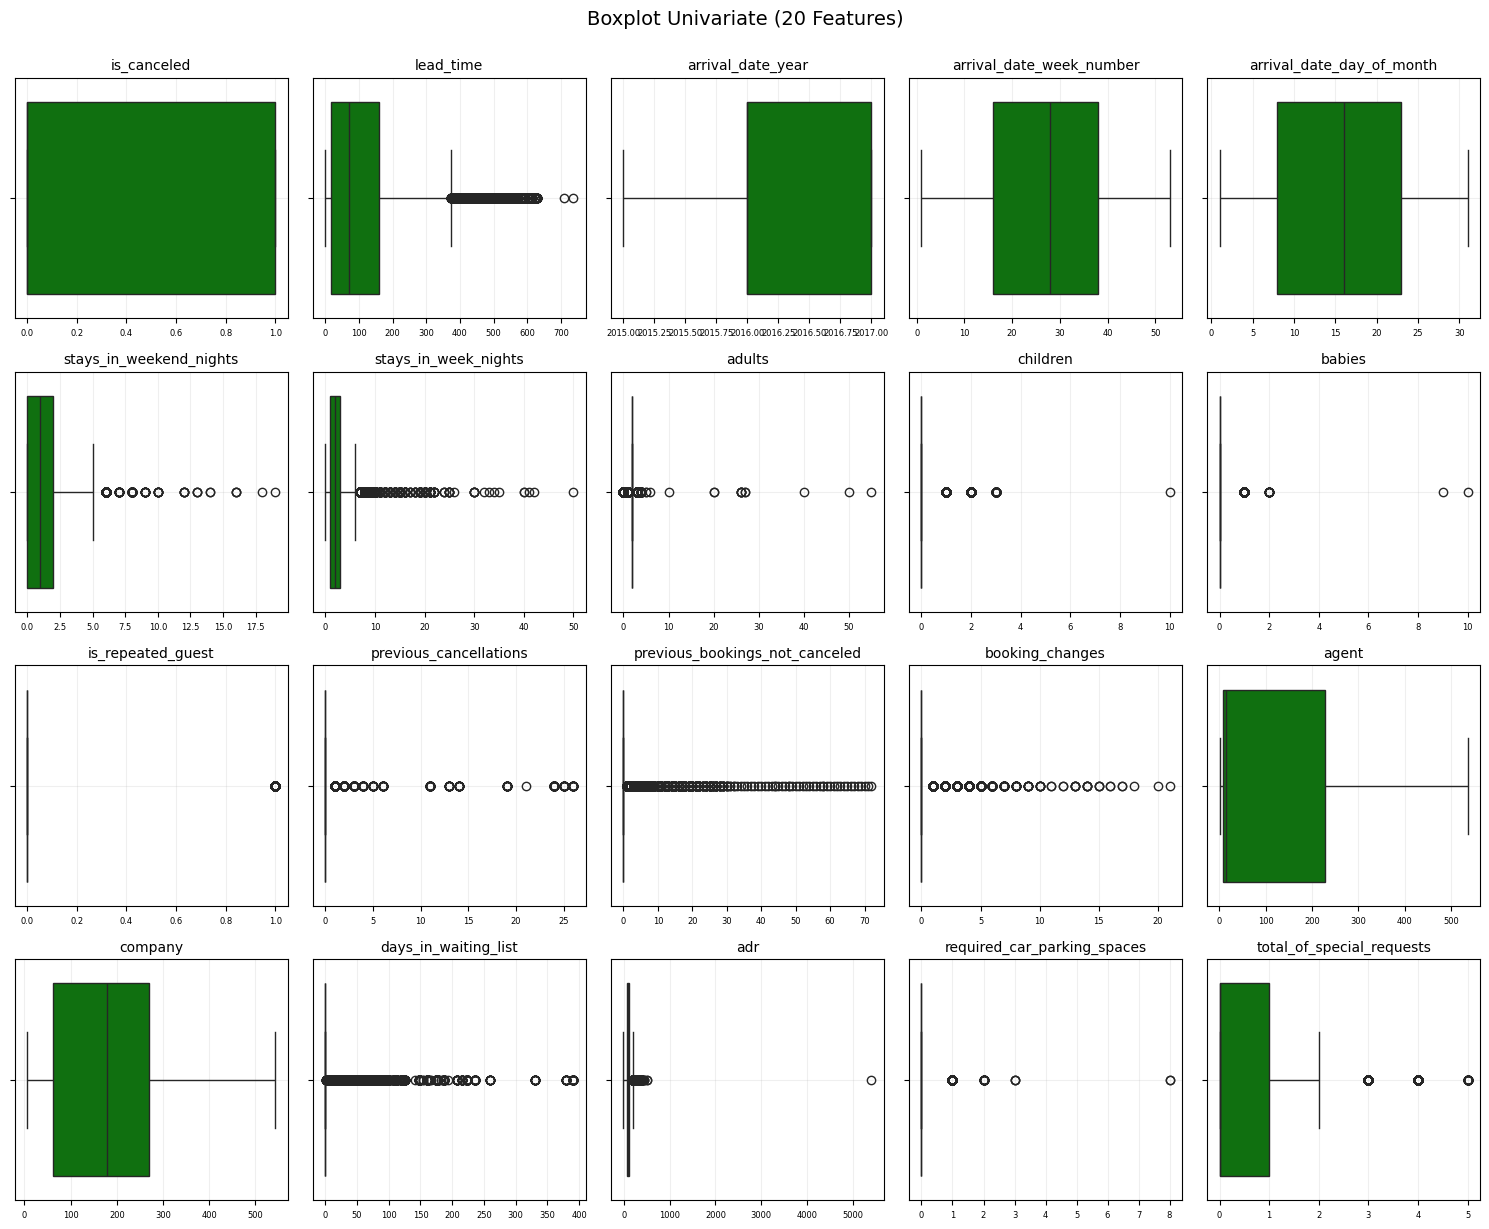

In [6]:
import math

# Pilih semua kolom numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Total kolom numerik: {len(num_cols)} feature")

# Hitung outlier summary untuk semua kolom
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers)/len(df)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)
display(outlier_df)

# VISUALISASI SEMUA FEATURE DALAM 1 GRID
n_cols = len(num_cols)
grid_size = math.ceil(math.sqrt(n_cols))  # Membuat grid persegi (misal 5x5 untuk 25 kolom)

fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size*3, grid_size*3))
fig.suptitle(f'Boxplot Univariate ({n_cols} Features)', 
             fontsize=14, fontweight='normal', y=1)

# Flatten axes agar mudah di-loop
axes = axes.flatten()

# Buat boxplot untuk setiap kolom
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], color='green', ax=axes[i])
    # Set judul (tanpa info outlier agar tidak terlalu padat)
    axes[i].set_title(f'{col}', fontsize=10, fontweight='normal')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=6)
    axes[i].grid(True, alpha=0.2)

# Hapus axes yang tidak terpakai (jika grid lebih besar dari jumlah kolom)
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretasi Univariate Boxplot:**
| Kategori                           | Informasi                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| ---------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Jumlah fitur                   | 20 fitur total                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Fitur dengan outlier           | 13 fitur                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| Fitur tanpa outlier            | 7 fitur                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| Fitur bermasalah (outlier > 0) | adults, booking_changes, children, required_car_parking_spaces, previous_cancellations, is_repeated_guest, adr, days_in_waiting_list, previous_bookings_not_canceled, stays_in_week_nights, lead_time, total_of_special_requests, babies                                                                                                                                                                              |
| Fitur bersih (outlier = 0)     | agent, company, arrival_date_day_of_month, arrival_date_week_number, arrival_date_year, stays_in_weekend_nights, is_canceled |

## Correlation Matrix

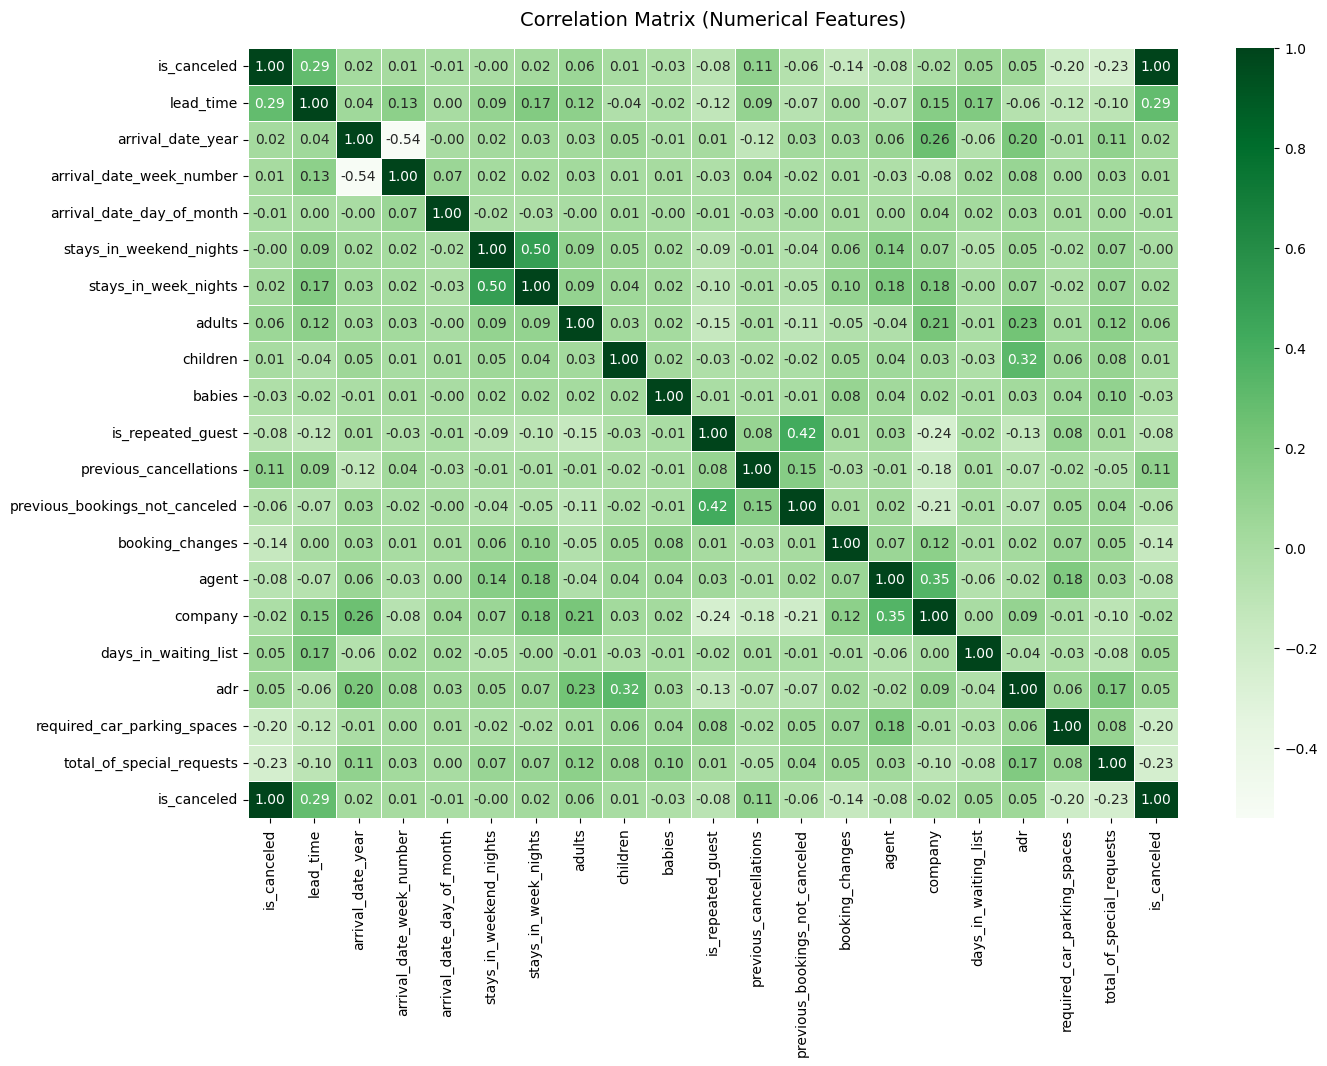

In [7]:
plt.figure(figsize=(15,10))
corr = df[num_cols + ['is_canceled']].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar=True,
    linewidths=0.5,
)
plt.title("Correlation Matrix (Numerical Features)", fontsize=14, fontweight='normal', y=1.02)
plt.show()



---
# **III. Data Cleaning & Transformation**
---
Untuk menyiapkan dataset final sebelum modeling.

In [8]:
# Check Data Shape
df.shape

(119390, 32)

## Drop Leakage Columns
> Target : is_canceled

**Leakage**
- reservation_status
- reservation_status_date

In [9]:
# Buat copy dari dataset asli
data_cleaned = df.copy()

# Daftar kolom leakage
leakage_cols = [
    'reservation_status',
    'reservation_status_date'
]

# Drop kolom leakage dari data copy
data_cleaned = data_cleaned.drop(columns=leakage_cols)

print("After dropping leakage:", data_cleaned.shape)

After dropping leakage: (119390, 30)


**Interpretasi hasil Drop Leakage:**
| Aspek              | Before  | After           | Interpretasi                         |
| ------------------ | --------| --------------- | ------------------------------------ |
| Kolom yang Dihapus | 32      | 30              | Kolom berpotensi data leakage `reservation_status`, `reservation_status_date`|


## Duplicate Handling

In [10]:
# Duplicate Check
print("Duplicate rows:", data_cleaned.duplicated().sum())

data_cleaned = data_cleaned.drop_duplicates()

print("After removing duplicates:", data_cleaned.shape)

Duplicate rows: 32252
After removing duplicates: (87138, 30)


## Handling Missing Value

In [11]:
# Missing Value Check ---
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Missing %
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [12]:
# Missing Value Treatment ---
data_cleaned['children'] = data_cleaned['children'].fillna(0)       # Numerical kecil
data_cleaned['country'] = data_cleaned['country'].fillna('Unknown') # Kategorikal kecil
data_cleaned['agent'] = data_cleaned['agent'].fillna(0)             # ID-based columns
data_cleaned['company'] = data_cleaned['company'].fillna(0)         # ID-based columns

# Final check
print("Remaining Missing:", data_cleaned.isnull().sum().sum())

Remaining Missing: 0


**Interpretasi Missing Value Handling:**
| Kolom    | Tipe Data            | Jumlah Missing   | Strategi        | Alasan                          |
| -------- | -------------------- | ---------------- | --------------- | ------------------------------- |
| children | Numerik (float)      | Sangat kecil (4) | Diisi 0         | Logis: tidak ada anak           |
| country  | Kategorikal (object) | Kecil (~0.4%)    | Diisi "Unknown" | Tambah kategori baru            |
| agent    | ID numerik           | ~13.7%           | Diisi 0         | Representasi “tanpa agen”       |
| company  | ID numerik           | ~94%             | Diisi 0         | Representasi “tanpa perusahaan” |

## Handling Outlier (IQR)

In [13]:
# Recommended Column to IQR
iqr_cols = [
    'lead_time',
    'adr',
    'stays_in_week_nights',
    'stays_in_weekend_nights'
]

summary_iqr = []

for col in iqr_cols:
    
    Q1 = data_cleaned[col].quantile(0.25)
    Q3 = data_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Hitung jumlah outlier sebelum capping
    before_low = (data_cleaned[col] < lower).sum()
    before_high = (data_cleaned[col] > upper).sum()
    
    # Lakukan capping langsung
    data_cleaned[col] = np.where(
        data_cleaned[col] < lower, lower,
        np.where(data_cleaned[col] > upper, upper, data_cleaned[col])
    )
    
    summary_iqr.append([
        col,
        before_low,
        before_high,
        round(lower, 2),
        round(upper, 2)
    ])

iqr_summary_df = pd.DataFrame(summary_iqr, 
                              columns=[
                                  'Column',
                                  'Outlier Low (Before)',
                                  'Outlier High (Before)',
                                  'Lower Bound',
                                  'Upper Bound'
                              ])

display(iqr_summary_df)

# Statistik setelah capping
print("\nAfter Outlier Handling.")
display(data_cleaned[iqr_cols].describe())
print("Before Outlier Handlling.")
display(df[iqr_cols].describe())

,Column,Outlier Low (Before),Outlier High (Before),Lower Bound,Upper Bound
0,lead_time,0,2371,-160.0,296.0
1,adr,0,2485,-21.0,227.0
2,stays_in_week_nights,0,1524,-3.5,8.5
3,stays_in_weekend_nights,0,218,-3.0,5.0



After Outlier Handling.


,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights
count,87138.000000,87138.000000,87138.000000,87138.000000
mean,78.203080,105.367965,2.577440,0.999185
std,80.961981,49.210406,1.807581,0.994303
min,0.000000,-6.380000,0.000000,0.000000
25%,11.000000,72.000000,1.000000,0.000000
50%,49.000000,98.100000,2.000000,1.000000
75%,125.000000,134.000000,4.000000,2.000000
max,296.000000,227.000000,8.500000,5.000000


Before Outlier Handlling.


,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights
count,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,101.831122,2.500302,0.927599
std,106.863097,50.535790,1.908286,0.998613
min,0.000000,-6.380000,0.000000,0.000000
25%,18.000000,69.290000,1.000000,0.000000
50%,69.000000,94.575000,2.000000,1.000000
75%,160.000000,126.000000,3.000000,2.000000
max,737.000000,5400.000000,50.000000,19.000000


**Interpretasi Outlier Handling:**
| Variabel                    | Alasan                                                                                                                     |
| --------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **lead_time**               | Variabel kontinu, sangat right-skewed, memiliki nilai ekstrem tinggi (hingga 737). IQR efektif membatasi tail panjang.     |
| **adr**                     | Variabel kontinu (harga), memiliki outlier ekstrem (hingga 5400). Capping mencegah distorsi mean dan model sensitif skala. |
| **stays_in_week_nights**    | Durasi stay bisa memiliki nilai ekstrem (hingga 50). Distribusi tidak zero-dominant.                                       |
| **stays_in_weekend_nights** | Sama seperti week nights, memiliki tail panjang meskipun terbatas.                                                         |

Insight: 
- `lead_time` – Distribusi sebelumnya sangat right-skewed. Capping membuat distribusi lebih stabil untuk modeling.
- `adr` – Nilai 5400 sangat tidak realistis → jelas noise atau anomali.
- `stay_in_week_nights` – Outlier hanya mempengaruhi ekor distribusi, bukan pusat data.
- `stays_in_weekend_nights` – Ada tamu dengan stay weekend hingga 19 malam. Nilai tersebut sangat jarang dan tidak merepresentasikan pola umum.

Karakteristik umum for Effective IQR:
- Bertipe numerik kontinu.
- Memiliki distribusi skewed.
- Outlier benar-benar ekstrem (bukan mayoritas pola).
- Pertahankan pola mayoritas data: Karena outlier di kolom ini jarang tetapi bisa mempengaruhi prediksi probabilitas cancel.
- Alasan Tidak Semua Kolom kategori atau integer kecil: Karena tidak cocok untuk IQR, karena:
    - IQR efektif untuk kontinu
    - Capping pada integer kecil bisa merusak distribusi asli.

## Re–check Target Distribution (After Treatment)

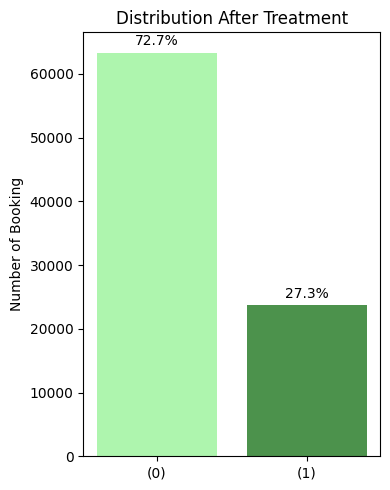

In [14]:
# Visualization dengan pin point percentage dan series churn tegak lurus
plt.figure(figsize=(4, 5))

# Hitung value counts dan persentase
canceled_counts = data_cleaned['is_canceled'].value_counts()
canceled_percentage = data_cleaned['is_canceled'].value_counts(normalize=True) * 100

# Bar chart tegak lurus
bars = plt.bar(['(0)', '(1)'], 
               canceled_counts.values,
               color=["#8CF18C", "#006400"],
               alpha=0.7)

# Pin point percentage
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + max(canceled_counts.values)*0.01,
             f'{canceled_percentage[i]:.1f}%',
             ha='center',
             va='bottom',
             fontsize=10)

plt.title("Distribution After Treatment")
plt.ylabel("Number of Booking")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0)

plt.tight_layout()
plt.show()

In [15]:
print("\nAfter Cleaned")
print(data_cleaned['is_canceled'].value_counts())

print("\nBefore Cleaned")
print(df['is_canceled'].value_counts())


After Cleaned
is_canceled
0    63371
1    23767
Name: count, dtype: int64

Before Cleaned
is_canceled
0    75166
1    44224
Name: count, dtype: int64


## Save Cleaned Data

In [16]:
# Simpan dalam dua format
data_cleaned.to_csv('hotel_bookings_cleaned.csv', index=False)
data_cleaned.to_pickle('hotel_bookings_cleaned.pkl')

## Feature Engineering
- Aggregation
- Behavioral / Derived Featured
- Data Cleaning (Drop Redundant)

In [17]:
# 1. AGGREGATE FEATURES
# Total Length of Stay
data_cleaned['total_stay'] = (
    data_cleaned['stays_in_week_nights'] +
    data_cleaned['stays_in_weekend_nights']
)

# Total Guest
data_cleaned['total_guest'] = (
    data_cleaned['adults'] +
    data_cleaned['children'] +
    data_cleaned['babies']
)


# 2. BEHAVIORAL FEATURES
# Booking Change Ratio
data_cleaned['change_ratio'] = np.where(
    data_cleaned['lead_time'] > 0,
    data_cleaned['booking_changes'] / data_cleaned['lead_time'],
    0
)

# Special Request Intensity
data_cleaned['request_per_stay'] = np.where(
    data_cleaned['total_stay'] > 0,
    data_cleaned['total_of_special_requests'] / data_cleaned['total_stay'],
    0
)

# ADR per Person
data_cleaned['adr_per_person'] = (
    data_cleaned['adr'] / data_cleaned['total_guest'].replace(0, 1)
)

# 3. DROP REDUNDANT FEATURES
columns_to_drop = [
    # Komponen pembentuk total_stay
    'stays_in_week_nights',
    'stays_in_weekend_nights',
    # Komponen pembentuk total_guest
    'adults',
    'children',
    'babies',
    # Feature turunan / binning yang tidak diperlukan
    'is_family',
    'lead_time_category',
    'waiting_category',
    'is_high_adr',
    'stay_type'
]

data_cleaned.drop(
    columns=[col for col in columns_to_drop if col in data_cleaned.columns],
    inplace=True
)

# 4. Final Check
missing = data_cleaned.isnull().sum()
print(missing[missing > 0])
print("Final dataset shape:", data_cleaned.shape)
display(data_cleaned.describe())

Series([], dtype: int64)
Final dataset shape: (87138, 30)


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay,total_guest,change_ratio,request_per_stay,adr_per_person
count,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000,87138.000000
mean,0.272751,78.203080,2016.210528,26.836363,15.814409,0.039179,0.030228,0.184535,0.272212,81.019842,11.017512,0.731759,105.367965,0.084475,0.699878,3.576626,2.025546,0.018925,0.284761,55.159437
std,0.445377,80.961981,0.686004,13.674634,8.835157,0.194022,0.369338,1.734427,0.727936,109.950068,54.039640,9.865156,49.210406,0.281912,0.832199,2.452991,0.794772,0.134505,0.450631,27.911528
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.190000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,37.800000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.100000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,50.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,134.000000,0.000000,1.000000,5.000000,2.000000,0.000000,0.400000,67.000000
max,1.000000,296.000000,2017.000000,53.000000,31.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,227.000000,8.000000,5.000000,13.500000,55.000000,8.000000,4.000000,227.000000


---
# **IV. Modelling**
---
Membangun model machine learning

## Define X & y

In [18]:
# Load data
df = pd.read_csv('hotel_bookings.csv')

# Define target y
y = df['is_canceled']

# Define X (semua kolom kecuali target dan kolom leakage)
leakage_cols = ['reservation_status', 'reservation_status_date']
X = df.drop(['is_canceled'] + leakage_cols, axis=1)

# Cek shape dan kolom
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Kolom X: {X.columns.tolist()}")

Shape X: (119390, 29)
Shape y: (119390,)
Kolom X: ['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


> *leakage_cols = ['reservation_status', 'reservation_status_date'] → Kolom yang mengandung informasi masa depan terkait status booking. Dihapus agar model tidak “curang” dengan data yang sebenarnya belum diketahui saat prediksi.*

## Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (83573, 29)
Test Shape: (35817, 29)


- Train: 83.573 baris × 29 kolom → untuk melatih model (70%).
- Test: 35.817 baris × 29 kolom → untuk mengevaluasi performa model (30%).

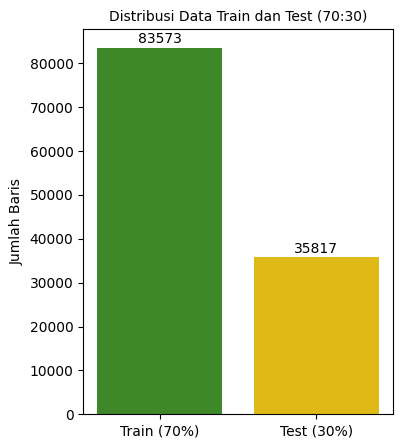

In [20]:
# Visualisasi distribusi jumlah baris
sizes = [len(X_train), len(X_test)]
labels = ['Train (70%)', 'Test (30%)']

plt.figure(figsize=(4,5))
plt.bar(labels, sizes, color = ['#3F8829', "#DFBA17"])
plt.ylabel("Jumlah Baris")
plt.title("Distribusi Data Train dan Test (70:30)", fontsize=10)
for i, size in enumerate(sizes):
    plt.text(i, size + 1000, str(size), ha='center')
plt.show()

## Define Preprocessing (Pipeline + ColumnTransformer)

In [21]:
from sklearn.preprocessing import RobustScaler


# Identify Numerical & Categorical Features
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Preprocessing Pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# FIT preprocessor di training set
preprocessor.fit(X_train)

# TRANSFORM training & test set
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Shape X_train_transformed:", X_train_transformed.shape)
print("Shape X_test_transformed:", X_test_transformed.shape)

Shape X_train_transformed: (83573, 245)
Shape X_test_transformed: (35817, 245)


- Train Set: 83,573 baris, 245 fitur hasil transformasi → siap untuk model training.
- Test Set: 35,817 baris, 245 fitur → digunakan untuk evaluasi model.

## Define Pipeline for Models

In [22]:
from sklearn.feature_selection import VarianceThreshold

model = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("variance_filter", VarianceThreshold(threshold=0.0)),              # Menghapus fitur variansi NOL (fitur yang nilainya konstan di semua data, causes not inform anything for classification).
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))  # iterasi 1000 untuk memastikan konvergensi, terutama dengan data yang telah di olah dan banyak fitur (hasil encoding banyak dimensi).
    ]),
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("classifier", KNeighborsClassifier())
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("classifier", DecisionTreeClassifier(random_state=42))             # Random state 42, acuan konvensi popular di komunitas data science untuk memastikan reprodusibilitas hasil.
    ])
}

# Loop fit semua model
fitted_models = {}
for name, pipeline in model.items():
    pipeline.fit(X_train, y_train)  # Fit preprocessing + classifier sekaligus
    fitted_models[name] = pipeline

- Membuat pipeline untuk beberapa model yang akan di terapkan agar data siap diproses dan model reproducible.
- Preprocessing: preprocessor menangani encoding, scaling, atau transformasi fitur.
- VarianceThreshold: Menghapus fitur dengan variansi nol (fitur konstan yang tidak berkontribusi pada prediksi).
- Classifier: Masing-masing model diterapkan setelah preprocessing.
- Logistic Regression: max_iter=1000 untuk memastikan konvergensi pada data berdimensi tinggi.
- Decision Tree: random_state=42 agar hasil konsisten.
- Loop Fit: Semua pipeline dilatih sekaligus, menyimpan model yang sudah fit di fitted_models.

> *Singkat: Pipeline ini memastikan data bersih, fitur relevan, dan model terlatih dengan cara yang reproducible.*

## **Training & Evaluation Baseline Models**

**Perbandingan Konseptual A (Training) & B (Testing)**

| Aspek                     | Training Set        | Evaluasi Test Set    |
| ------------------------- | ------------------- | ------------- |
| Data evaluasi             | X_train 70%             | X_test 30%        |
| Metode                    | 5-fold CV           | Hold-out test |
| Model dilatih full train? | Tidak               | Ya            |
| Mengukur apa?             | Stabilitas internal | Generalisasi  |
| Untuk final decision?     | Tidak               | Ya            |

***Gunakan Training Set untuk:***
- Membandingkan model awal
- Feature engineering
- Exploratory model selection

***Gunakan Evaluasi Test Set untuk:***
- Final evaluation
- Baseline vs tuned comparison
- Deployment justification

### *A. Training Set with CV*

In [23]:
# Cross-validation setup with StratifiedKfold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_train_result = []

for name, pipeline in model.items():
    # Prediksi dengan cross-validation
    y_pred = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict')
    y_prob = cross_val_predict(pipeline, X_train, y_train, cv=cv, method='predict_proba')[:,1]
    
    baseline_train_result.append({
        "Model": name,
        "Recall": round(recall_score(y_train, y_pred), 2),
        "F1 Score": round(f1_score(y_train, y_pred), 2),
        "F2 Score": round(fbeta_score(y_train, y_pred, beta=2), 2),
        "ROC-AUC": round(roc_auc_score(y_train, y_prob), 2),
        "PR-AUC": round(average_precision_score(y_train, y_prob), 2),
        "Log Loss": round(log_loss(y_train, y_prob), 2)
    })

# Data Frame Evaluation Result
baseline_train_result = pd.DataFrame(baseline_train_result)
baseline_train_result = baseline_train_result.sort_values(by=["PR-AUC", "ROC-AUC"], ascending=False)

display(baseline_train_result)


,Model,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.67,0.73,0.69,0.90,0.86,0.38
1,KNN,0.75,0.76,0.76,0.89,0.83,1.15
2,Decision Tree,0.80,0.80,0.80,0.85,0.72,5.19


- Logistic Regression: Recall 0.67, F1 0.73, ROC-AUC 0.90 → stabil dan diskriminatif, Log Loss rendah (0.38).

- KNN: Recall 0.75, F1 0.76, ROC-AUC 0.89 → lebih sensitif, tapi Log Loss lebih tinggi (1.15).

- Decision Tree: Recall 0.80, F1 0.80, ROC-AUC 0.85 → menangkap lebih banyak kasus positif, tapi overfit (Log Loss 5.19).

> *Logistic Regression seimbang dan paling handal, KNN lebih agresif, Decision Tree sensitif tapi risiko overfit tinggi.*

### *B. Fit Full Training (Evaluate Test Set)*

In [24]:
# FIT BASELINE MODEL (TRAIN ONLY)
based_model_trained = {}

for name, model in model.items():
    model.fit(X_train, y_train)
    based_model_trained[name] = model

# EVALUASI DI TEST SET
baseline_test_results = []

for name, model in based_model_trained.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    baseline_test_results.append({
        "Model": name,
        "Recall": round(recall_score(y_test, y_pred), 2),
        "F1 Score": round(f1_score(y_test, y_pred), 2),
        "F2 Score": round(fbeta_score(y_test, y_pred, beta=2), 2),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 2),
        "PR-AUC": round(average_precision_score(y_test, y_prob), 2),
        "Log Loss": round(log_loss(y_test, y_prob), 2)
    })

baseline_test_results= pd.DataFrame(baseline_test_results).sort_values(
    by=["PR-AUC", "ROC-AUC"],
    ascending=False
)

display(baseline_test_results)

,Model,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.66,0.73,0.69,0.90,0.86,0.38
1,KNN,0.76,0.77,0.77,0.90,0.83,1.17
2,Decision Tree,0.81,0.81,0.81,0.85,0.72,5.07


- Logistic Regression: Recall 0.66, F1 0.73, ROC-AUC 0.90 → stabil, baik untuk diskriminasi, Log Loss rendah (0.38).

- KNN: Recall 0.76, F1 0.77, ROC-AUC 0.90 → lebih sensitif terhadap kasus positif, tapi Log Loss tinggi (1.17).

- Decision Tree: Recall 0.81, F1 0.81, ROC-AUC 0.85 → menangkap banyak kasus positif, namun rawan overfit (Log Loss 5.07).

> *Kesimpulan: Logistic Regression tetap paling seimbang, KNN agresif menangkap kasus positif, Decision Tree performa tinggi tapi kurang stabil.*

In [25]:
# Comparison Train-Test Baseline Model

model_col = baseline_train_result['Model']  # Pisahkan kolom model (agar tidak terduplikasi).

comparison = baseline_train_result.drop(columns=['Model']).round(3).astype(str) + " / " + baseline_test_results.drop(columns=['Model']).round(3).astype(str)
comparison.insert(0, 'Model', model_col)

print("--- Baseline Train & Test Comparison ---")
comparison

--- Baseline Train & Test Comparison ---


,Model,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.67 / 0.66,0.73 / 0.73,0.69 / 0.69,0.9 / 0.9,0.86 / 0.86,0.38 / 0.38
1,KNN,0.75 / 0.76,0.76 / 0.77,0.76 / 0.77,0.89 / 0.9,0.83 / 0.83,1.15 / 1.17
2,Decision Tree,0.8 / 0.81,0.8 / 0.81,0.8 / 0.81,0.85 / 0.85,0.72 / 0.72,5.19 / 5.07


Ringkas perbandingan **Baseline vs Tuned**:

| Model                   | Performa Singkat                                                                                                                           |
| ----------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **Logistic Regression** | Hampir tidak berubah: Recall 0.67 → 0.66, F1 & ROC-AUC stabil. Model baseline sudah seimbang dan stabil.                                   |
| **KNN**                 | Slight improvement: Recall 0.75 → 0.76, F1 0.76 → 0.77, ROC-AUC 0.89 → 0.90. Lebih sensitif terhadap kasus positif setelah tuning.         |
| **Decision Tree**       | Minor upgrade: Recall 0.80 → 0.81, F1 0.80 → 0.81, Log Loss turun 5.19 → 5.07. Masih rawan overfit tapi sedikit lebih baik setelah tuning. |

> *Tuning memberikan peningkatan kecil pada model non-linear (KNN, Decision Tree), sedangkan Logistic Regression relatif stabil karena sudah optimal secara baseline.*

## **Training & Evaluation Tuned Models**

In [26]:
from scipy.stats import randint


# PARAMETER DISTRIBUTIONS
param_dist_logreg = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "classifier__class_weight": [None, "balanced", {0:1, 1:2}, {0:1, 1:3}]
}

**Parameter space untuk tuning Logistic Regression.**
- C → mengatur regularisasi (0.001 sangat ketat, 100 sangat longgar).
- class_weight → menyesuaikan bobot kelas untuk mengatasi imbalance (misal kelas positif diberi bobot lebih tinggi).

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# DICTIONARY OF MODEL USED
model = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("variance_filter", VarianceThreshold(threshold=0.0)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])
}

f2_scorer = make_scorer(fbeta_score, beta=2)    # Buat custom scorer untuk scoring f2.

# RANDOMIZED SEARCH
tuned_search = {
    "Logistic Regression": RandomizedSearchCV(
        model["Logistic Regression"],
        param_distributions=param_dist_logreg,
        n_iter=50,
        scoring=f2_scorer,   # f2 sebagai objective memilih hyperparameter terbaik untuk recall yang lebih tinggi, sesuai dengan kebutuhan bisnis untuk meminimalisir false negative (missed cancellation).
        cv=cv,
        random_state=42,
        n_jobs=-1
    )
}

- RandomizedSearchCV untuk hyperparameter tuning Logistic Regression.

- Pipeline: preprocessing + variance filter + classifier.

- Custom scorer: fbeta_score dengan beta=2 → lebih menekankan recall, cocok untuk kasus di mana kehilangan kasus positif (false negative) lebih mahal.

- RandomizedSearchCV: mencari kombinasi hyperparameter terbaik (C dan class_weight) dari param_dist_logreg sebanyak 50 iterasi dengan cross-validation (cv).

> *Untuk optimalkan F2-score agar model lebih agresif menangkap kasus positif (misal booking cancellation) tanpa mengorbankan keseluruhan performa terlalu drastis.*

In [ ]:
# FITTING RANDOMIZED SEARCH
tuned_trained = {}                                  # dictionary untuk menyimpan estimator terbaik

for name, search in tuned_search.items():
    search.fit(X_train, y_train)                    # fit RandomizedSearchCV
    tuned_trained[name] = search.best_estimator_    # ambil pipeline terbaik

- Bagian ini menjalankan RandomizedSearchCV yang sudah didefinisikan sebelumnya.

- Untuk setiap model di tuned_search (di sini hanya Logistic Regression):
    1. search.fit(X_train, y_train) → melakukan fitting dan cross-validation untuk semua kombinasi hyperparameter yang diuji.
    2. search.best_estimator_ → menyimpan pipeline terbaik (preprocessing + classifier + parameter terbaik) ke dictionary tuned_trained.

> *Untuk mendapatkan model yang tuned optimal berdasarkan F2-score, siap digunakan untuk prediksi dan evaluasi.*

### *A. Training Set*

In [29]:
# FIT TUNED MODEL (TRAIN SET ONLY)
tuned_train_results = []

for name, pipeline in tuned_trained.items():  # pipeline sudah fit
    y_pred_train = pipeline.predict(X_train)
    y_prob_train = pipeline.predict_proba(X_train)[:,1]

    tuned_train_results.append({
        "Model": name,
        "Recall": round(recall_score(y_train, y_pred_train),2),
        "F1 Score": round(f1_score(y_train, y_pred_train),2),
        "F2 Score": round(fbeta_score(y_train, y_pred_train, beta=2),2),
        "ROC-AUC": round(roc_auc_score(y_train, y_prob_train),2),
        "PR-AUC": round(average_precision_score(y_train, y_prob_train),2),
        "Log Loss": round(log_loss(y_train, y_prob_train),2)
    })

tuned_train_results = pd.DataFrame(tuned_train_results)
display(tuned_train_results)

,Model,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.9,0.75,0.83,0.9,0.86,0.45


**Performa model Logistic Regression setelah hyperparameter tuning.**

Interpretasi metrik:
- Recall 0.90 → Hampir semua kasus positif (misal booking yang batal) berhasil terdeteksi.
- F2 Score 0.83 → Model fokus pada recall (minimalkan false negative), sesuai prioritas bisnis.
- F1 Score 0.75 → Keseimbangan precision–recall cukup baik.
- ROC-AUC 0.90 → Model masih memiliki kemampuan diskriminasi yang kuat antara positif dan negatif.
- PR-AUC 0.86 → Presisi tetap cukup tinggi untuk kelas positif.
- Log Loss 0.45 → Probabilitas prediksi lebih agresif, sedikit kurang kalibrasi dibanding baseline.

> *Model tuned ini efektif untuk mendeteksi pembatalan dengan risiko false negative rendah, siap dipakai untuk intervensi bisnis kritikal.*

### *B. Fit Full Training (Evaluate Test Set)*

In [30]:
# EVALUASI TEST SET
tuned_test_results = []

for name, pipeline in tuned_trained.items():  # Guinakan best estimator dari RandomizedSearchCV
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    tuned_test_results.append({
        "Model": name,
        "Recall": round(recall_score(y_test, y_pred), 2),
        "F1 Score": round(f1_score(y_test, y_pred), 2),
        "F2 Score": round(fbeta_score(y_test, y_pred, beta=2), 2),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 2),
        "PR-AUC": round(average_precision_score(y_test, y_prob), 2),
        "Log Loss": round(log_loss(y_test, y_prob), 2)
    })

tuned_test_results = pd.DataFrame(tuned_test_results).sort_values(
    by=["PR-AUC", "ROC-AUC"], ascending=False
)

display(tuned_test_results)

,Model,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.89,0.74,0.82,0.9,0.85,0.46


- Recall 0.89 → Hampir 89% kasus positif berhasil terdeteksi, risiko missed cancellation rendah.

- F2 Score 0.82 → Fokus pada recall, sesuai prioritas bisnis untuk meminimalkan false negative.

- F1 Score 0.74 → Keseimbangan precision–recall cukup baik, tetap menjaga akurasi prediksi positif.

- ROC-AUC 0.90 → Model tetap memiliki kemampuan diskriminasi yang tinggi antara booking batal dan tidak.

- PR-AUC 0.85 → Presisi cukup tinggi meskipun recall dinaikkan.

- Log Loss 0.46 → Probabilitas prediksi sedikit kurang kalibrasi dibanding baseline, menunjukkan model lebih agresif dalam mendeteksi cancel.

> *Model tuned pada test set konsisten efektif dalam memprediksi pembatalan, siap digunakan untuk intervensi preventif bisnis dengan risiko false negative yang rendah.*

In [31]:
# Comparison Train-Test Baseline Model

model_col_tuned = tuned_train_results['Model']  # Pisahkan kolom model (agar tidak terduplikasi).

comparison = tuned_train_results.drop(columns=['Model']).round(3).astype(str) + " / " + tuned_test_results.drop(columns=['Model']).round(3).astype(str)
comparison.insert(0, 'Model', model_col_tuned)

print("--- Tuned Train & Test Comparison ---")
comparison

--- Tuned Train & Test Comparison ---


,Model,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.9 / 0.89,0.75 / 0.74,0.83 / 0.82,0.9 / 0.9,0.86 / 0.85,0.45 / 0.46


- Recall: 0.90 → 0.89 → hampir sama, model tetap menangkap sebagian besar kasus positif di data unseen.

- F2 Score: 0.83 → 0.82 → fokus pada recall tetap terjaga, false negative rendah.

- F1 Score: 0.75 → 0.74 → keseimbangan precision–recall stabil.

- ROC-AUC: 0.90 → 0.90 → kemampuan diskriminasi konsisten, model tidak overfit.

- PR-AUC: 0.86 → 0.85 → presisi tetap cukup tinggi meski recall tinggi.

- Log Loss: 0.45 → 0.46 → sedikit penurunan kalibrasi probabilitas, model lebih agresif mendeteksi cancel.

> *Model tuned menunjukkan kinerja stabil antara train dan test, siap digunakan untuk intervensi preventif dengan risiko false negative minimal.*

## Baseline & Tuning Comparison Model Test

In [32]:
BT_comparison_results = []

# Ambil hanya Logistic Regression
baseline_model = based_model_trained["Logistic Regression"]
tuned_model = tuned_trained["Logistic Regression"]

models_compare = {
    "Baseline": baseline_model,
    "Tuned": tuned_model
}

for name, model in models_compare.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    BT_comparison_results.append({
        "Model": name,
        "Recall (Test)": round(recall_score(y_test, y_pred), 2),
        "F1 (Test)": round(f1_score(y_test, y_pred), 2),
        "F2 (Test)": round(fbeta_score(y_test, y_pred, beta=2), 2),
        "ROC-AUC (Test)": round(roc_auc_score(y_test, y_prob), 2),
        "PR-AUC (Test)": round(average_precision_score(y_test, y_prob), 2),
        "Log Loss (Test)": round(log_loss(y_test, y_prob), 2)
    })

BT_Comparison = pd.DataFrame(BT_comparison_results)

print("--- Baseline vs Tuned Model Comparison ---")
BT_Comparison

--- Baseline vs Tuned Model Comparison ---


,Model,Recall (Test),F1 (Test),F2 (Test),ROC-AUC (Test),PR-AUC (Test),Log Loss (Test)
0,Baseline,0.66,0.73,0.69,0.9,0.86,0.38
1,Tuned,0.89,0.74,0.82,0.9,0.85,0.46


**Hasil perbandingan (Test Set)**

| Metric   | Baseline | Tuned    | Perubahan |
| -------- | -------- | -------- | --------- |
| Recall   | 0.66     | **0.89** | +0.23     |
| F1       | 0.73     | 0.74     | +0.01     |
| F2       | 0.69     | **0.82** | +0.13     |
| ROC-AUC  | 0.90     | 0.90     | Sama      |
| PR-AUC   | 0.86     | 0.85     | -0.01     |
| Log Loss | 0.38     | 0.46     | +0.08     |


**Kondisi model saat ini:**
- Recall: 0.66 → 0.89 → meningkat drastis, model tuned jauh lebih baik dalam menangkap kasus positif (cancellation), mengurangi false negatives.

- F2 Score: 0.69 → 0.82 → peningkatan fokus pada recall, sesuai prioritas bisnis untuk minimalkan risiko kehilangan kasus kritikal.

- F1 Score: 0.73 → 0.74 → sedikit meningkat, keseimbangan precision–recall tetap baik.

- ROC-AUC: 0.90 → 0.90 → kemampuan diskriminasi kelas tidak berubah, model tetap stabil.

- PR-AUC: 0.86 → 0.85 → presisi sedikit turun karena recall ditingkatkan (trade-off klasik).

- Log Loss: 0.38 → 0.46 → probabilitas prediksi lebih agresif, kalibrasi sedikit menurun.
- Trade-off: sedikit penurunan PR-AUC & kenaikan Log Loss → probabilitas prediksi lebih agresif.

> *Model tuned sudah optimal untuk deteksi kasus kritikal, tanpa menurunkan kemampuan diskriminasi dasar. ensembling tidak diperlukan saat ini.*


## Check (Under & Over)–Fitting

In [33]:
def full_fit_diagnosis(model, X_train, y_train, X_test, y_test, model_name="Model"):

    # TRAIN METRICS ----
    y_pred_train = model.predict(X_train)
    y_prob_train = model.predict_proba(X_train)[:, 1]

    # TEST METRICS ----
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # CALCULATE METRICS TRAIN & TEST ----
    train_metrics = {
        "Recall": recall_score(y_train, y_pred_train),
        "F1": f1_score(y_train, y_pred_train),
        "F2": fbeta_score(y_train, y_pred_train, beta=2),
        "ROC-AUC": roc_auc_score(y_train, y_prob_train),
        "PR-AUC": average_precision_score(y_train, y_prob_train),
        "Log Loss": log_loss(y_train, y_prob_train)
    }

    test_metrics = {
        "Recall": recall_score(y_test, y_pred_test),
        "F1": f1_score(y_test, y_pred_test),
        "F2": fbeta_score(y_test, y_pred_test, beta=2),
        "ROC-AUC": roc_auc_score(y_test, y_prob_test),
        "PR-AUC": average_precision_score(y_test, y_prob_test),
        "Log Loss": log_loss(y_test, y_prob_test)
    }


    # GAP CALCULATION
    gap_metrics = {
        metric: train_metrics[metric] - test_metrics[metric]
        for metric in train_metrics
    }


    # CROSS VALIDATION
    cv_auc = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"   # Tidak terpengaruh dengan treshold, sehingga cocok untuk overfitting check.
    )

    cv_mean = np.mean(cv_auc)
    cv_std = np.std(cv_auc)


    # DIAGNOSIS LOGIC
    auc_gap = gap_metrics["ROC-AUC"]

    if auc_gap > 0.05:
        diagnosis = "Overfitting"
    elif train_metrics["ROC-AUC"] < 0.75 and test_metrics["ROC-AUC"] < 0.75:
        diagnosis = "Underfitting"
    else:
        diagnosis = "Good Fit"


    # RESULT TABLE
    results_df = pd.DataFrame({
        "Metric": train_metrics.keys(),
        "Train": [round(v,2) for v in train_metrics.values()],
        "Test": [round(test_metrics[k],2) for k in train_metrics.keys()],
        "Gap": [round(gap_metrics[k],2) for k in train_metrics.keys()]
    })

    summary_df = pd.DataFrame({
        "Model": [model_name],
        "CV AUC Mean": [round(cv_mean,4)],
        "CV AUC Std": [round(cv_std,4)],
        "Diagnosis": [diagnosis]
    })

    print(f"\n--- {model_name} FIT DIAGNOSIS ---")
    display(summary_df)

    return results_df

Fungsi ini digunakan untuk **mendiagnosis performa model** secara menyeluruh, seperti:

1. **Prediksi & Probabilitas** – Menghasilkan prediksi dan probabilitas kelas untuk **train** dan **test set**.
2. **Metrik Evaluasi** – Menghitung Recall, F1, F2, ROC-AUC, PR-AUC, dan Log Loss untuk train & test.
3. **Gap Analisis** – Mengukur selisih performa antara train dan test untuk mendeteksi **overfitting** atau **underfitting**.
4. **Cross-Validation** – Mengecek stabilitas model dengan rata-rata dan standar deviasi ROC-AUC dari CV.
5. **Diagnosis** – Memberikan kesimpulan sederhana: *Good Fit*, *Overfitting*, atau *Underfitting*.
6. **Output** – Menampilkan tabel metrik per train/test + ringkasan diagnosis model.

> *Fungsi ini memberi gambaran lengkap **kualitas, stabilitas, dan risiko bias** dari model sebelum digunakan.*


In [34]:
# Panggil hasil

baseline_model = based_model_trained["Logistic Regression"]
tuned_model = tuned_trained["Logistic Regression"]

baseline_check = full_fit_diagnosis(
    baseline_model,
    X_train, y_train,
    X_test, y_test,
    model_name="Baseline Logistic Regression"
)

display(baseline_check)

tuned_check = full_fit_diagnosis(
    tuned_model,
    X_train, y_train,
    X_test, y_test,
    model_name="Tuned Logistic Regression"
)

display(tuned_check)


--- Baseline Logistic Regression FIT DIAGNOSIS ---


,Model,CV AUC Mean,CV AUC Std,Diagnosis
0,Baseline Logistic Regression,0.898,0.0024,Good Fit


,Metric,Train,Test,Gap
0,Recall,0.67,0.66,0.00
1,F1,0.73,0.73,0.00
2,F2,0.69,0.69,0.00
3,ROC-AUC,0.90,0.90,0.00
4,PR-AUC,0.86,0.86,0.00
5,Log Loss,0.37,0.38,-0.01



--- Tuned Logistic Regression FIT DIAGNOSIS ---


,Model,CV AUC Mean,CV AUC Std,Diagnosis
0,Tuned Logistic Regression,0.8976,0.0021,Good Fit


,Metric,Train,Test,Gap
0,Recall,0.90,0.89,0.01
1,F1,0.75,0.74,0.00
2,F2,0.83,0.82,0.01
3,ROC-AUC,0.90,0.90,0.00
4,PR-AUC,0.86,0.85,0.00
5,Log Loss,0.45,0.46,-0.00


**Model Fit Diagnosis Summary**

1. **Stability Model CV**

| Model | CV AUC Mean | CV AUC Std | Interpretasi Stabilitas |
| ---------------------------- | ----------- | ---------- | -------------------------------------- |
| Baseline Logistic Regression | 0.898 | 0.0024 | Sangat stabil (variance sangat rendah) |
| Tuned Logistic Regression | 0.8976 | 0.0021 | Sangat stabil (variance sangat rendah) |

> *Std < 0.01 menunjukkan model sangat konsisten antar-fold dan tidak sensitif terhadap variasi data.*

2. **Overfitting Check (Train vs Test)**

| Model | Train AUC | Test AUC | Gap | Kesimpulan |
| -------- | --------- | -------- | ----- | ----------------- |
| Baseline | 0.90 | 0.90 | 0.00 | Tidak overfitting |
| Tuned | 0.90 | 0.90 | 0.00 | Tidak overfitting |

> *Gap mendekati nol menandakan model mampu melakukan generalisasi dengan baik.*

3. **Underfitting Check**

| Model | AUC Level | Train vs Test Consistency | Kesimpulan |
| -------- | ------------- | ------------------------- | ------------------ |
| Baseline | Tinggi (0.90) | Konsisten | Tidak underfitting |
| Tuned | Tinggi (0.90) | Konsisten | Tidak underfitting |

> *AUC tinggi dan stabil, menunjukan model tidak terlalu sederhana.*

3. **Perbandingan Performa Bisnis (Test Set)**

| Metric | Baseline | Tuned | Insight |
| -------- | -------- | ----- | -------------------------------------------- |
| Recall | 0.66 | 0.89 | Tuned jauh lebih baik menangkap cancellation |
| F2 | 0.69 | 0.82 | Tuned optimal untuk recall-heavy objective |
| ROC-AUC | 0.90 | 0.90 | Separability sama |
| PR-AUC | 0.86 | 0.85 | Hampir sama |
| Log Loss | 0.38 | 0.46 | Baseline sedikit lebih baik dalam kalibrasi |

**Final Interpretation**

| Evaluasi                         | Hasil                    |
| -------------------------------- | ------------------------ |
| Overfitting                      | Tidak ada                |
| Underfitting                     | Tidak ada                |
| Separability Improvement         | Tidak berubah (AUC sama) |
| Business Objective (High Recall) | Tuned lebih sesuai       |
| Model Stability                  | Sangat stabil            |

**Ringkasa:**
- Kedua model berada dalam kondisi good fit (stabil, tanpa indikasi overfit/underfit).

- Tuning tidak meningkatkan ROC-AUC (tetap 0.90), tetapi Recall dan F2 meningkat signifikan.

- Jika tujuan utama adalah memaksimalkan deteksi kelas positif (mengurangi missed cancellation), gunakan Tuned Logistic Regression.

- Jika prioritas pada kalibrasi probabilitas (Log Loss lebih baik), Baseline Logistic Regression sedikit lebih unggul.

### CATATAN TAMBAHAN
***Tidak Dibutuhkan-nya Ensembling***
- Model sudah stabil dan generalizable
- Tidak ada variance problem
- Tidak ada bias problem
- Tidak ada gap performa signifikan

> Secara teknis: tidak wajib melakukan ensembling

Ensembling Dibutuhkan, jika:
- Variance tinggi (CV std besar)
- Overfitting
- Model berbeda punya strength berbeda
- Butuh peningkatan AUC signifikan
- Dataset kompleks / nonlinear

Dalam kasus ini:
- Logistic Regression = model linear
- AUC sudah cukup tinggi (0.85)
- Performa antar versi hampir identik
> Artinya: ruang peningkatan kemungkinan ada pada model non-linear, bukan sekadar gabungan logistic.

## **Check Boosting (Optional Cross-Check) with XGBoost**
- Sebagai Optional untuk prediksi yang lebih agresif
- Jika membutuhkan strategi kombinasi

In [35]:
# Persiap Data

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [36]:
# Create Pipeline XGBoost

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()  # imbalance handling
    ))
])

In [37]:
# Custom F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

param_dist = {
    "classifier__n_estimators": np.arange(200, 500, 50),
    "classifier__max_depth": np.arange(3, 8),
    "classifier__learning_rate": np.linspace(0.01, 0.1, 10),
    "classifier__subsample": np.linspace(0.7, 1.0, 4),
    "classifier__colsample_bytree": np.linspace(0.7, 1.0, 4),
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__gamma": [0, 0.1, 0.3],
    "classifier__reg_alpha": [0, 0.5, 1],
    "classifier__reg_lambda": [1, 2, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f2_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit ke data training
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['lead_time',
                                                                                'arrival_date_year',
                                                                                'arrival_date_week_number',
                                                                                'arrival_date_day_of_month',
                                                                                'stays_in_weekend_nights',
                                                                                'stays_in_week_nights',
                                                                                'adults',
                                                                                'children',
                                                                                'babies',
                                                                                'is_repeated_guest',
                                                                                'previous_cancellations',
                                                                                'previous_bookings_...
                                        'classifier__max_depth': array([3, 4, 5, 6, 7]),
                                        'classifier__min_child_weight': [1, 3,
                                                                         5],
                                        'classifier__n_estimators': array([200, 250, 300, 350, 400, 450]),
                                        'classifier__reg_alpha': [0, 0.5, 1],
                                        'classifier__reg_lambda': [1, 2, 5],
                                        'classifier__subsample': array([0.7, 0.8, 0.9, 1. ])},
                   random_state=42,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
                   verbose=1)

In [38]:
# Evaluasi Model

best_model = random_search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:,1]

y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:,1]

# Hitung metrics
from sklearn.metrics import recall_score, f1_score, fbeta_score, roc_auc_score, average_precision_score, log_loss

metrics_train = {
    "Recall": recall_score(y_train, y_pred_train),
    "F1": f1_score(y_train, y_pred_train),
    "F2": fbeta_score(y_train, y_pred_train, beta=2),
    "ROC-AUC": roc_auc_score(y_train, y_prob_train),
    "PR-AUC": average_precision_score(y_train, y_prob_train),
    "Log Loss": log_loss(y_train, y_prob_train)
}

metrics_test = {
    "Recall": recall_score(y_test, y_pred_test),
    "F1": f1_score(y_test, y_pred_test),
    "F2": fbeta_score(y_test, y_pred_test, beta=2),
    "ROC-AUC": roc_auc_score(y_test, y_prob_test),
    "PR-AUC": average_precision_score(y_test, y_prob_test),
    "Log Loss": log_loss(y_test, y_prob_test)
}

# Tampilkan
pd.DataFrame([metrics_train, metrics_test], index=["Train", "Test"]).round(3)

,Recall,F1,F2,ROC-AUC,PR-AUC,Log Loss
Train,0.926,0.889,0.911,0.978,0.965,0.207
Test,0.880,0.848,0.867,0.957,0.937,0.258


In [39]:
# Fungsi untuk hitung metrics + gap
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Prediksi
    y_pred_train = model.predict(X_train)
    y_prob_train = model.predict_proba(X_train)[:,1]

    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:,1]

    # Metrics
    metrics_train = {
        "Recall": recall_score(y_train, y_pred_train),
        "F1": f1_score(y_train, y_pred_train),
        "F2": fbeta_score(y_train, y_pred_train, beta=2),
        "ROC-AUC": roc_auc_score(y_train, y_prob_train),
        "PR-AUC": average_precision_score(y_train, y_prob_train),
        "Log Loss": log_loss(y_train, y_prob_train)
    }

    metrics_test = {
        "Recall": recall_score(y_test, y_pred_test),
        "F1": f1_score(y_test, y_pred_test),
        "F2": fbeta_score(y_test, y_pred_test, beta=2),
        "ROC-AUC": roc_auc_score(y_test, y_prob_test),
        "PR-AUC": average_precision_score(y_test, y_prob_test),
        "Log Loss": log_loss(y_test, y_prob_test)
    }

    # Gap Train-Test
    gap_metrics = {k: metrics_train[k] - metrics_test[k] for k in metrics_train}

    # Compile DataFrame
    results_df = pd.DataFrame([metrics_train, metrics_test, gap_metrics], index=["Train", "Test", "Gap"]).round(2)
    results_df.index.name = model_name
    return results_df

# Ambil model terbaik
logreg_model = tuned_trained["Logistic Regression"]
xgb_model = random_search.best_estimator_

# Evaluasi kedua model
logreg_eval = evaluate_model(logreg_model, X_train, y_train, X_test, y_test, "Tuned LogReg")
xgb_eval    = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "Tuned XGBoost")

# Tampilkan perbandingan
print("--- Tuned Logistic Regression ---")
display(logreg_eval)

print("--- Tuned XGBoost ---")
display(xgb_eval)

--- Tuned Logistic Regression ---


,Recall,F1,F2,ROC-AUC,PR-AUC,Log Loss
Tuned LogReg,,,,,,
Train,0.90,0.75,0.83,0.9,0.86,0.45
Test,0.89,0.74,0.82,0.9,0.85,0.46
Gap,0.01,0.00,0.01,0.0,0.00,-0.00


--- Tuned XGBoost ---


,Recall,F1,F2,ROC-AUC,PR-AUC,Log Loss
Tuned XGBoost,,,,,,
Train,0.93,0.89,0.91,0.98,0.96,0.21
Test,0.88,0.85,0.87,0.96,0.94,0.26
Gap,0.05,0.04,0.04,0.02,0.03,-0.05


**Perbandingan Performa Metric Logregg vs XGBoost**

| Metric         | Logistic Regression (Test) | XGBoost (Test) | Catatan                                                                                |
| -------------- | -------------------------- | -------------- | -------------------------------------------------------------------------------------- |
| Recall         | 0.89                       | 0.88           | XGBoost hampir setara, tetap menangkap banyak positif, LR sedikit lebih tinggi di sini |
| F1             | 0.74                       | 0.85           | XGBoost lebih seimbang antara Precision & Recall                                       |
| F2             | 0.82                       | 0.87           | XGBoost lebih menekankan Recall, lebih baik untuk kasus churn/cancellation             |
| ROC-AUC        | 0.90                       | 0.96           | XGBoost menunjukkan kemampuan diskriminasi lebih tinggi                                |
| PR-AUC         | 0.85                       | 0.94           | XGBoost lebih unggul dalam klasifikasi positif di data tidak seimbang                  |
| Log Loss       | 0.46                       | 0.26           | XGBoost prediksi probabilitas lebih akurat                                             |
| Gap Train-Test | 0.01                       | 0.02–0.05      | XGBoost sedikit overfit tapi masih wajar (under 0.05)                                  |

**Interpretasi:**
- Logistic Regression: sangat stabil, gap train-test hampir nol → Good Fit, cocok untuk interpretasi dan memahami faktor utama.

- XGBoost: performa lebih tinggi di semua metric, sedikit overfit tapi masih dalam batas aman → lebih akurat untuk prediksi risiko pembatalan.

**Kesimpulan:**
- **XGBoost:** Pilihan utama untuk Predict Cancellation Risk → probabilitas risiko tinggi lebih akurat, membantu revenue management mitigasi cepat.
- **Logistic Regression:** Pilihan utama untuk Understand Key Drivers → koefisien bisa dijelaskan ke stakeholder, faktor pembatalan jelas.
- **Strategi Kombinasi / Ensemble:** Gunakan XGBoost untuk prediksi, LR untuk interpretasi → mitigasi risiko dan pengambilan keputusan lebih efektif.

| Pertanyaan Bisnis             | Model Lebih Sesuai   | Penjelasan                                                                                                        |
| ----------------------------- | -------------------- | ----------------------------------------------------------------------------------------------------------------- |
| **Predict Cancellation Risk** | XGBoost              | F2 & Recall tinggi → bisa menangkap lebih banyak pembatalan sebelum check-in.                                     |
| **Understand Key Drivers**    | Logistic Regression  | Koefisien jelas → mudah dijelaskan ke manajemen / stakeholder.                                                    |
| **Protect Revenue**           | Kombinasi / Ensemble | Gunakan XGBoost untuk prediksi akurat + Logistic Regression untuk interpretasi → strategi mitigasi lebih optimal. |



### ***PROBLEM STATEMENT CHECK***

1. Identifikasi faktor kunci
    - Logistic Regression → memberikan interpretasi jelas mengenai faktor utama yang memengaruhi pembatalan, seperti lead_time, booking_changes, deposit_type, dan previous_cancellations.
    - Memenuhi kebutuhan bisnis untuk mengetahui driver pembatalan utama dan memudahkan penjelasan ke stakeholder.

2. Segmentasi pelanggan berdasarkan risiko
    - XGBoost → menghasilkan probabilitas risiko pembatalan untuk tiap reservasi.
    - Probabilitas ini bisa digunakan untuk mengklasifikasikan pelanggan menjadi high-risk dan low-risk, mendukung strategi overbooking dan manajemen revenue yang lebih cerdas.

3. Proyeksi probabilitas pembatalan sebelum check-in
    - XGBoost → fokus pada prediksi akurat, mampu menangkap lebih banyak potensi pembatalan sebelum tanggal check-in.
    - Mendukung predictive cancellation risk, sehingga hotel bisa melakukan mitigasi lebih awal (misal follow-up pelanggan atau penawaran fleksibel).

4. Insight berbasis data untuk strategi pricing & distribusi
    - Kombinasi Logistic Regression + XGBoost → menggabungkan model interpretable untuk memahami faktor pembatalan dengan model akurat untuk prediksi risiko.
    - Membantu keputusan pricing, alokasi kamar, strategi deposit, dan distribusi kamar menjadi lebih optimal dan berbasis data.

5. Mengurangi risiko revenue loss & ineffisiensi operasional
    - XGBoost → menurunkan risiko revenue loss akibat kamar kosong mendadak dengan prediksi probabilitas tinggi.
    - Logistic Regression → memberikan pemahaman faktor penyebab pembatalan sehingga strategi mitigasi bisa diterapkan lebih tepat dan efektif.

---
# **V. Evaluation & Business Insight**
---

## ROC & Precision–Recall Curve

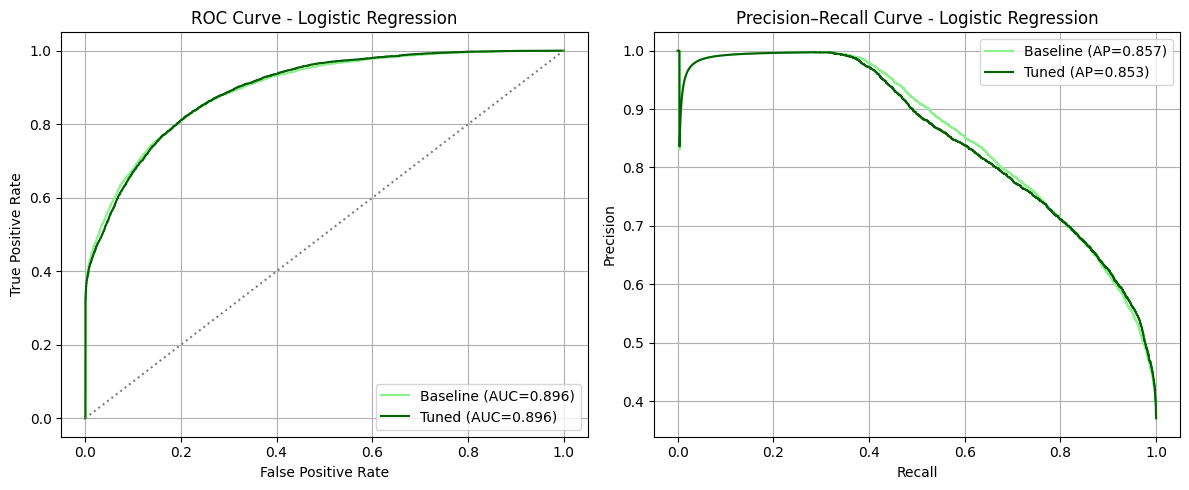

In [40]:
def plot_roc_pr_logreg(baseline_models, tuned_models, X_test, y_test, model_name="Logistic Regression"):
    """
    Plot ROC & Precision-Recall Curve hanya untuk Logistic Regression.
    
    Parameters:
    - baseline_models: dict, pipeline baseline {nama_model: pipeline}
    - tuned_models: dict, pipeline tuned {nama_model: pipeline}
    - X_test, y_test: test set
    - model_name: str, nama model yang ingin diplot
    """
    baseline_model = baseline_models[model_name]
    tuned_model    = tuned_models[model_name]
    
    # Probabilities
    y_proba_baseline = baseline_model.predict_proba(X_test)[:,1]
    y_proba_tuned    = tuned_model.predict_proba(X_test)[:,1]
    
    # ROC
    fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_baseline)
    fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)
    roc_auc_base = auc(fpr_base, tpr_base)
    roc_auc_tuned = auc(fpr_tuned, tpr_tuned)
    
    # Precision-Recall
    precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_baseline)
    precision_tuned, recall_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)
    pr_auc_base = average_precision_score(y_test, y_proba_baseline)
    pr_auc_tuned = average_precision_score(y_test, y_proba_tuned)
    
    # Plot
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12,5))
    
    # ROC Curve
    ax_roc.plot(fpr_base, tpr_base, '-', label=f'Baseline (AUC={roc_auc_base:.3f})', color="#8CF18C")
    ax_roc.plot(fpr_tuned, tpr_tuned, '-', label=f'Tuned (AUC={roc_auc_tuned:.3f})', color="#046104")
    ax_roc.plot([0,1],[0,1], ':', color='gray')
    ax_roc.set_title(f'ROC Curve - {model_name}')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()
    ax_roc.grid(True)
    
    # Precision-Recall Curve
    ax_pr.plot(recall_base, precision_base, '-', label=f'Baseline (AP={pr_auc_base:.3f})', color="#8CF18C")
    ax_pr.plot(recall_tuned, precision_tuned, '-', label=f'Tuned (AP={pr_auc_tuned:.3f})', color="#046104")
    ax_pr.set_title(f'Precision–Recall Curve - {model_name}')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend()
    ax_pr.grid(True)
    
    plt.tight_layout()
    plt.show()

# Panggil hanya untuk Logistic Regression
plot_roc_pr_logreg(
    baseline_models=fitted_models,
    tuned_models=tuned_trained,
    X_test=X_test,
    y_test=y_test,
    model_name="Logistic Regression"
)

**Interpretasi ROC & Precision-Recall Curve**

1. **ROC Curve Analysis**
    - Model Discrimination: AUC Baseline = 0,896 dan Tuned = 0,896 → menunjukkan True Positive Rate (TPR) meningkat konsisten seiring False Positive Rate (FPR), tanpa perubahan berarti setelah tuning.

    - Interpretasi Bisnis: Model sudah mampu membedakan antara pelanggan yang berpotensi membatalkan dan yang tidak, menangkap sebagian besar kasus positif dengan kesalahan minimal.
    
    > *Logistic Regression memiliki kemampuan diskriminasi yang kuat, mendekati klasifikasi ideal, dan tuning tidak meningkatkan AUC karena baseline sudah optimal.*

2. **Precision-Recall Curve Analysis**
    - Keseimbangan Prediksi: Average Precision Baseline = 0,857 dan Tuned = 0,853 → precision tetap tinggi meskipun recall meningkat.

    - Relevansi pada Data Tidak Seimbang: Model dapat mendeteksi sebagian besar kasus positif (Recall tinggi) sambil mempertahankan akurasi prediksi positif (Precision tinggi).

    - Perbandingan dengan Baseline: Performa Tuned hampir sama dengan Baseline → tuning tidak mengubah kemampuan model secara signifikan dalam hal precision-recall.

3. **Business Insight**
    - Logistic Regression sangat cocok untuk skenario di mana menangkap semua kasus positif dan menjaga akurasi prediksi positif sama pentingnya.

    - Dapat digunakan untuk preventive actions atau intervensi bisnis terkait pelanggan berisiko tinggi (misal: potential cancellations).


> ***Logistic Regression terbukti robust dan presisi tinggi**, meskipun tuning tidak meningkatkan AUC atau AP secara signifikan, model sudah sangat stabil dan dapat digunakan sebagai basis pengambilan keputusan bisnis kritikal terkait pelanggan dengan risiko tinggi.*

## Confusion Matrix

===== Logistic Regression - Baseline (Threshold = 0.5) =====
Accuracy : 0.818
Precision: 0.810
Recall   : 0.665
F1 Score : 0.730
F2 Score : 0.689

===== Logistic Regression - Baseline (Threshold = 0.4) =====
Accuracy : 0.817
Precision: 0.753
Recall   : 0.752
F1 Score : 0.752
F2 Score : 0.752

===== Logistic Regression - Baseline (Threshold = 0.3) =====
Accuracy : 0.794
Precision: 0.679
Recall   : 0.841
F1 Score : 0.751
F2 Score : 0.803

===== Logistic Regression - Baseline (Threshold = 0.2) =====
Accuracy : 0.738
Precision: 0.595
Recall   : 0.919
F1 Score : 0.722
F2 Score : 0.829



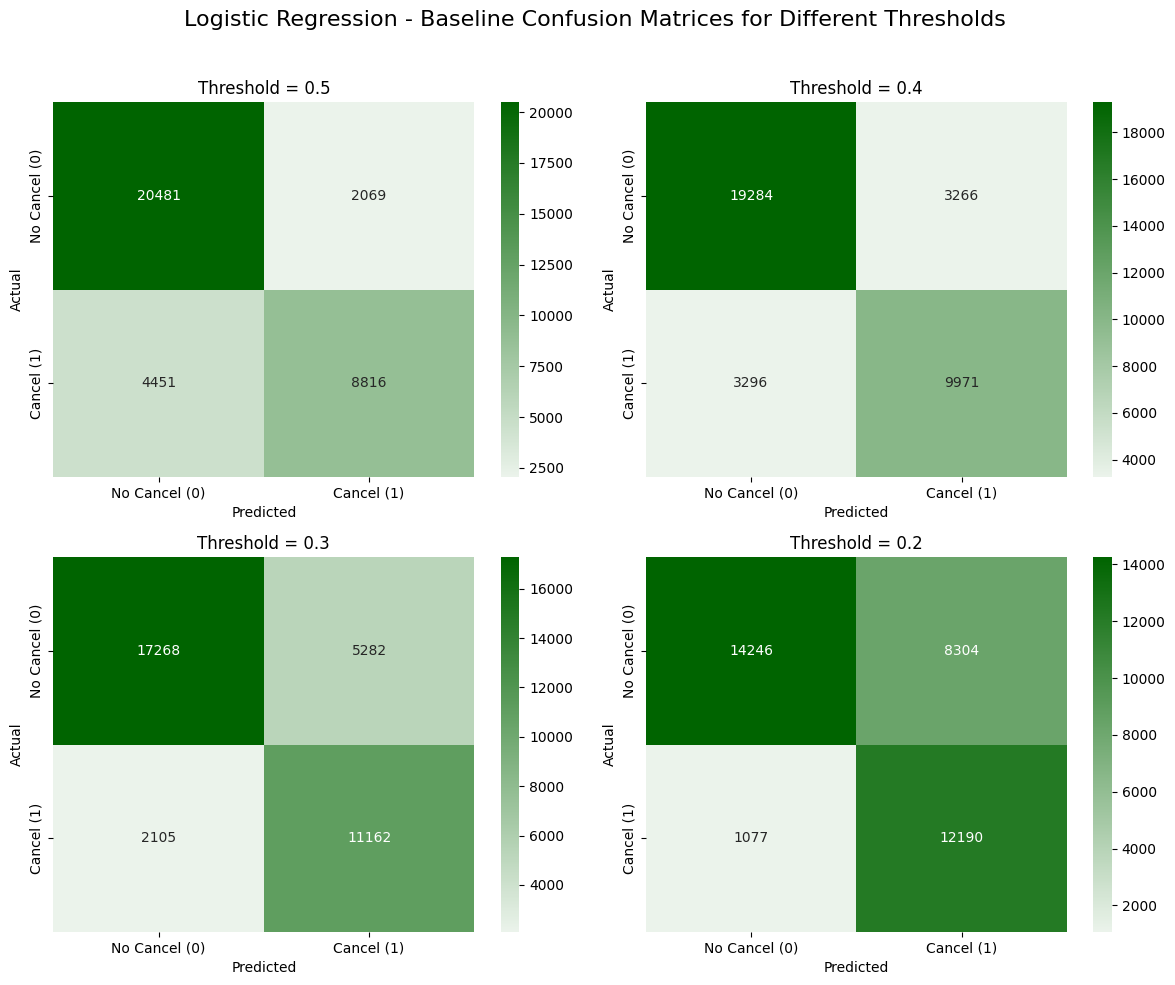

===== Logistic Regression - Tuned (Threshold = 0.5) =====
Accuracy : 0.772
Precision: 0.639
Recall   : 0.886
F1 Score : 0.742
F2 Score : 0.822

===== Logistic Regression - Tuned (Threshold = 0.4) =====
Accuracy : 0.729
Precision: 0.583
Recall   : 0.935
F1 Score : 0.718
F2 Score : 0.834

===== Logistic Regression - Tuned (Threshold = 0.3) =====
Accuracy : 0.678
Precision: 0.536
Recall   : 0.966
F1 Score : 0.690
F2 Score : 0.833

===== Logistic Regression - Tuned (Threshold = 0.2) =====
Accuracy : 0.608
Precision: 0.486
Recall   : 0.982
F1 Score : 0.650
F2 Score : 0.815



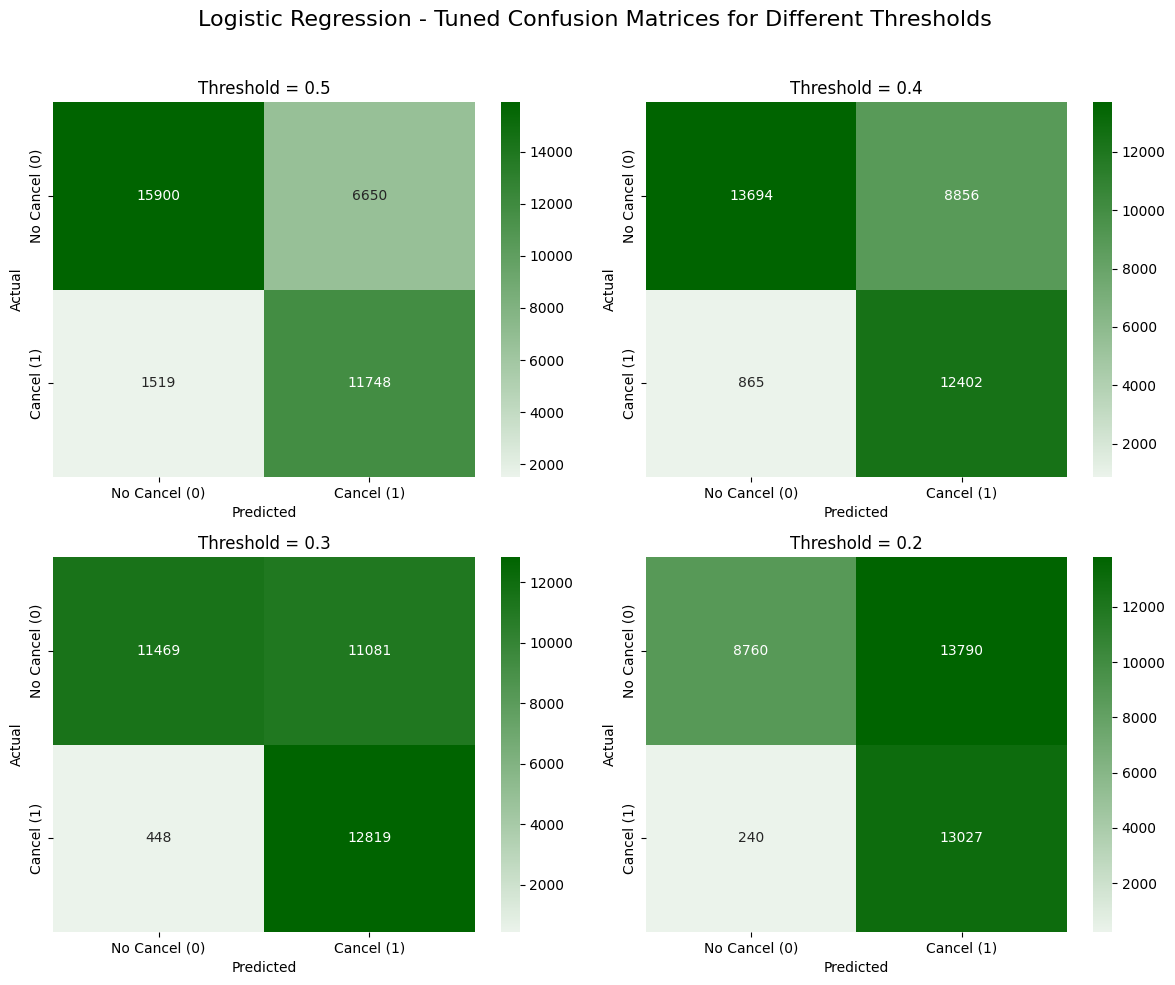

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, confusion_matrix

# Hanya Logistic Regression
models_to_evaluate = {
    "Logistic Regression - Baseline": fitted_models["Logistic Regression"],
    "Logistic Regression - Tuned": tuned_trained["Logistic Regression"]
}

thresholds = [0.5, 0.4, 0.3, 0.2]

for name, model in models_to_evaluate.items():
    y_prob = model.predict_proba(X_test)[:,1]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, thresh in enumerate(thresholds):
        y_pred = (y_prob >= thresh).astype(int)
        
        # Print metrics utama
        print(f"===== {name} (Threshold = {thresh}) =====")
        print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
        print(f"Precision: {precision_score(y_test, y_pred):.3f}")
        print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
        print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
        print(f"F2 Score : {fbeta_score(y_test, y_pred, beta=2):.3f}\n")
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(
            cm, annot=True, fmt='d',
            cmap=sns.light_palette("#006400", as_cmap=True),
            xticklabels=["No Cancel (0)", "Cancel (1)"],
            yticklabels=["No Cancel (0)", "Cancel (1)"],
            ax=axes[i]
        )
        axes[i].set_title(f"Threshold = {thresh}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
    
    plt.suptitle(f"{name} Confusion Matrices for Different Thresholds", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

**Interpretasi Confusion Matrix**

| Actual \ Predicted | No Cancel (0) | Cancel (1) |
| ------------------ | ------------- | ---------- |
| No Cancel (0)      | **TN**        | **FP**     |
| Cancel (1)         | **FN**        | **TP**     |

**Analisa Metrics to Treshold**
| Threshold    | Accuracy | Precision | Recall | F1    | F2    | Interpretasi Bisnis                                                                                              |
| ------------ | -------- | --------- | ------ | ----- | ----- | ---------------------------------------------------------------------------------------------------------------- |
| 0.5 Baseline | 0.818    | 0.810     | 0.665  | 0.730 | 0.689 | Deteksi pembatalan moderat, precision tinggi → cocok untuk prediksi konservatif, minim false alarm.              |
| 0.4 Baseline | 0.817    | 0.753     | 0.752  | 0.752 | 0.752 | Recall meningkat, hampir semua pembatalan tertangkap → ideal untuk proteksi revenue.                             |
| 0.3 Baseline | 0.794    | 0.679     | 0.841  | 0.751 | 0.803 | Recall tinggi, precision menurun → lebih banyak false positives → perlu mitigasi lebih hati-hati.                |
| 0.2 Baseline | 0.738    | 0.595     | 0.919  | 0.722 | 0.829 | Recall sangat tinggi → hampir semua pembatalan tertangkap, tapi FP banyak → strategi mitigasi fleksibel.         |
| 0.5 Tuned    | 0.772    | 0.639     | 0.886  | 0.742 | 0.822 | Recall jauh lebih tinggi daripada baseline → lebih agresif mendeteksi pembatalan, precision lebih rendah.        |
| 0.4 Tuned    | 0.729    | 0.583     | 0.935  | 0.718 | 0.834 | **F2 tertinggi** → menangkap hampir semua pembatalan potensial → sangat baik untuk proteksi revenue.             |
| 0.3 Tuned    | 0.678    | 0.536     | 0.966  | 0.690 | 0.833 | Recall sangat tinggi, FP naik → banyak false alarm, perlu mitigasi hati-hati.                                    |
| 0.2 Tuned    | 0.608    | 0.486     | 0.982  | 0.650 | 0.815 | Recall maksimum → hampir semua pembatalan tertangkap, tapi FP sangat tinggi → strategi mitigasi harus fleksibel. |


**Kesimpulan dan Insight Business**
- F2 Score lebih relevan karena menekankan Recall → bisnis ingin menangkap semua pembatalan potensial untuk melindungi revenue.

- Threshold Optimal: 0.4 (baik baseline maupun tuned)
    - F2 tertinggi (0.834 Tuned)
    - Recall tinggi (0.935)
    - Precision masih dalam level wajar → false positives terkendali.

**Strategi Implementasi:**
- Booking high-risk (prediksi ≥ 0.4): Terapkan deposit parsial, reminder otomatis, atau follow-up khusus.
- Booking low-risk (prediksi < 0.4): Biarkan proses normal, fleksibel.
- Gunakan risk score untuk:
    - Channel management → alokasi kamar lebih tepat
    - Overbooking planning → meminimalkan revenue loss
    - Targeted promotions / incentives → mengurangi pembatalan

## F2 Score

In [42]:
from sklearn.metrics import fbeta_score

# Logistic Regression saja
models_to_evaluate = {
    "Logistic Regression - Baseline": fitted_models["Logistic Regression"],
    "Logistic Regression - Tuned": tuned_trained["Logistic Regression"]
}

thresholds = [0.5, 0.4, 0.3, 0.2]

for name, model in models_to_evaluate.items():
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"--- {name} ---")
    
    best_thresh = None
    best_f2 = -1
    
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        print(f"Threshold {thresh:.2f} -> F2 Score: {f2:.3f}")
        
        if f2 > best_f2:
            best_f2 = f2
            best_thresh = thresh
    
    print(f"**Best Threshold (F2)**: {best_thresh} with F2 = {best_f2:.3f}\n")

--- Logistic Regression - Baseline ---
Threshold 0.50 -> F2 Score: 0.689
Threshold 0.40 -> F2 Score: 0.752
Threshold 0.30 -> F2 Score: 0.803
Threshold 0.20 -> F2 Score: 0.829
**Best Threshold (F2)**: 0.2 with F2 = 0.829

--- Logistic Regression - Tuned ---
Threshold 0.50 -> F2 Score: 0.822
Threshold 0.40 -> F2 Score: 0.834
Threshold 0.30 -> F2 Score: 0.833
Threshold 0.20 -> F2 Score: 0.815
**Best Threshold (F2)**: 0.4 with F2 = 0.834



**Interpretasi F2–Score**

| Model    | Best Threshold | F2 Score | Insight                                                                                                                                                                                                                    |
| -------- | -------------- | -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Baseline | 0.2            | 0.829    | F2 meningkat drastis saat threshold diturunkan → model baseline awalnya konservatif, lebih sedikit positif terdeteksi pada 0.5. Menurunkan threshold meningkatkan recall sehingga F2 (yang menekankan recall) optimal.     |
| Tuned    | 0.4            | 0.834    | Tuned model lebih seimbang: F2 maksimal tidak di threshold terendah. Ini menunjukkan model sudah lebih “agresif” dalam menangkap kasus positif, sehingga threshold 0.4 cukup untuk memaksimalkan recall-presisi trade-off. |

**Insight Bisnis**

1. *Baseline Model*
    - Untuk memaksimalkan kemampuan menangkap kasus positif (misal: potential cancellation), perlu menurunkan threshold sampai 0.2.

    - Jika threshold default (0.5) digunakan, banyak kasus positif terlewat → risiko kerugian bisnis meningkat.

2. *Tuned Model*
    - Threshold 0.4 optimal untuk F2 → lebih mudah diterapkan tanpa menurunkan threshold terlalu ekstrem.

    - Meminimalkan false negatives sambil menjaga false positives terkendali → lebih efisien dari sisi operasional/intervensi.

3. *Strategic Takeaway*
    - Jika prioritas bisnis adalah menangkap seluruh kasus positif (recall tinggi), Tuned Model dengan threshold 0.4 memberikan hasil terbaik.

    - Baseline memerlukan intervensi threshold agresif → meningkatkan risiko false positives dan biaya operasional tambahan.

> *Tuned Logistic Regression memberikan keseimbangan optimal antara recall dan precision, siap digunakan sebagai model prediktif untuk intervensi bisnis kritikal, dengan risiko false negatives minimal dan efisiensi operasional terjaga.*

## Cost Benefit

In [43]:
from sklearn.metrics import confusion_matrix

def cost_benefit_score_euro(y_true, y_pred):
    # Cost-benefit matrix in Euro
    benefit_matrix = np.array([
        [0, -40],    # Actual 0
        [-120, 80]   # Actual 1
    ])
    
    cm = confusion_matrix(y_true, y_pred)
    
    total_value = np.sum(cm * benefit_matrix)
    
    return total_value

# Thresholds yang mau dievaluasi
thresholds = [0.5, 0.4, 0.3, 0.2]

for thresh in thresholds:
    y_prob = tuned_trained["Logistic Regression"].predict_proba(X_test)[:,1]
    y_pred = (y_prob >= thresh).astype(int)
    business_value = cost_benefit_score_euro(y_test, y_pred)
    print(f"Threshold = {thresh}: Total Business Value = €{business_value:,}")

Threshold = 0.5: Total Business Value = €491,560
Threshold = 0.4: Total Business Value = €534,120
Threshold = 0.3: Total Business Value = €528,520
Threshold = 0.2: Total Business Value = €461,760


**Interpretation by Assumtion**

| Actual \ Predicted   | Prediksi 0 | Prediksi 1 |
| -------------------- | ---------- | ---------- |
| Actual 0 (No cancel) | 0 €        | -40 €      |
| Actual 1 (Cancel)    | -120 €     | 80 €       |

- TN (0,0) → benar tidak dibatalkan → netral = 0
- FP (0,1) → salah prediksi akan batal → biaya mitigasi (misal reminder atau deposit fleksibel) = -40
- FN (1,0) → tidak mendeteksi pembatalan → revenue hilang = -120
- TP (1,1) → berhasil mendeteksi pembatalan → revenue terselamatkan = 80

> Ini adalah asumsi estimasi finansial per kasus, bisa disesuaikan sesuai data internal hotel.

**Business Insight**
| Threshold     | Recall        | Precision     | F2 Score | Total Business Value (€) | Insight Bisnis                                                                                                  |
| ------------- | ------------- | ------------- | -------- | ------------------------ | --------------------------------------------------------------------------------------------------------------- |
| 0.5           | Moderat       | Tinggi        | 0.738    | 491,560                  | Prediksi konservatif → beberapa pembatalan tidak terdeteksi, revenue terselamatkan moderat                      |
| 0.4 Optimal | Tinggi        | Sedang        | 0.834    | 534,120                  | Sweet spot: deteksi pembatalan maksimal tanpa biaya mitigasi berlebihan, revenue protection optimal             |
| 0.3           | Sangat Tinggi | Rendah        | 0.833    | 528,520                  | Hampir semua pembatalan terdeteksi, tapi false positives meningkat → biaya mitigasi lebih tinggi                |
| 0.2           | Hampir Semua  | Sangat Rendah | 0.815    | 461,760                  | Prediksi agresif → false positives tinggi → total business value menurun karena biaya mitigasi melebihi manfaat |

**Metrics Brief for  Each Treshold**

| Threshold | Recall | Precision | F2 Score |
| --------- | ------ | --------- | -------- |
| 0.5       | 0.886  | 0.639     | 0.822    |
| 0.4       | 0.935  | 0.583     | 0.834    |
| 0.3       | 0.966  | 0.536     | 0.833    |
| 0.2       | 0.982  | 0.486     | 0.815    |

Strategic Insights
---
**A. Treshold 0.4, if:**
- Threshold 0.4 memberikan nilai bisnis tertinggi (€534,120) → deteksi pembatalan maksimal dengan biaya mitigasi masih terkendali.

- Menurunkan threshold di bawah 0.4 meningkatkan recall, tapi menurunkan precision, sehingga biaya mitigasi naik dan total business value menurun.

- Threshold 0.4 sejalan dengan F2 optimal, menjaga keseimbangan antara menangkap semua pembatalan (recall tinggi) dan mengurangi false positives (precision masih wajar).

- Gunakan threshold 0.4 untuk intervensi bisnis, reminder otomatis, deposit parsial, atau strategi overbooking berbasis risiko.

**B. Treshold 0.5, if:**
- Hotel ingin mengurangi false alarms → biaya mitigasi rendah, tapi beberapa pembatalan tetap bisa terjadi.

- Tujuan utama adalah menangkap sebanyak mungkin pembatalan untuk proteksi revenue.

- Dipakai sebagai default konservatif, terutama saat sumber daya mitigasi terbatas (misal staf untuk reminder atau follow-up deposit).

## Profit-Driven Model Evaluation for Cost-Sensitive Model Performance (Financial Impact)

Setelah semua dihitung:
- Jika Profit Increase > 0 → model membantu hotel
- Jika negatif → threshold perlu diturunkan (tingkatkan recall)
- Biasanya optimal threshold ≠ 0.5

Dalam kasus hotel_booking:
- FN sangat mahal → prioritaskan recall
- Gunakan PR Curve untuk tentukan threshold
- Optimalkan berdasarkan profit, bukan ROC

### *1. ADR Room per Night*
Rumus: **ADR = Total Revenue Kamar / Total Kamar Terjual**

In [44]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [45]:
# Hitung total stay per booking
df["total_stay"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Total room revenue (exclude cancelled)
revenue = (df[df["is_canceled"] == 0]["adr"] * df[df["is_canceled"] == 0]["total_stay"]).sum()

# Total room nights sold
room_nights = df[df["is_canceled"] == 0]["total_stay"].sum()

# Average Daily Rate
ADR = revenue / room_nights
print("Average Daily Rate:", round(ADR,2))

Average Daily Rate: 101.93


### *2. Lost Revenue (Kerugian Kamar Kosong)*
- Terjadi jika *"Booking cancel dan kamar tidak terjual ulang"*
- Rumus: **Loss= ADR × (1 − Rebooking Rate)** 

In [46]:
# Hitung ADR dari booking yang tidak cancel
ADR = df[df["is_canceled"] == 0]["adr"].mean()

# Rata-rata lama menginap
avg_stay = df["total_stay"].mean()

# Asumsi rebooking rate (bisa diganti dengan data aktual)
rebooking_rate = 0.4

loss_FN = ADR * avg_stay * (1 - rebooking_rate)

print("ADR:", round(ADR, 2))
print("Average Stay:", round(avg_stay, 2))
print("Loss per FN:", round(loss_FN, 2))

ADR: 99.99
Average Stay: 3.43
Loss per FN: 205.65


### *3. Biaya Overbooking Salah (FP Cost)*
- Terjadi jika *"Model prediksi cancel, namun tamu sebenarnya datang"*
- Rumus: **Cost = 0.5 × ADR** 
- Assumed the compensation range 30% – 100%, but to concervatively used 50%

In [47]:
cost_FP = 0.5 * ADR
print("Cost per FP:", round(cost_FP, 2))

Cost per FP: 49.99


### *4. Menghitung Benefit jika Antisaipasi Cancel (TP)*
- Terjadi jika *"Model benar prediksi cancel dan kamar berhasil dijual ulang"*
- Rumus: **BenefitTP ​= ADR × Avg_Stay × Rebooking_Rate** 

In [48]:
benefit_TP = ADR * avg_stay * rebooking_rate
print("Benefit per TP:", round(benefit_TP, 2))

Benefit per TP: 137.1


### *5. Total Profit Model*
*Dengan Confusion Metrix Treshold 0.4*

In [49]:
from sklearn.metrics import confusion_matrix

# Fungsi profit tetap sama
def calculate_profit(y_true, y_pred, benefit_TP, cost_FP, loss_FN):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    profit = (TP * benefit_TP) - (FP * cost_FP) - (FN * loss_FN)
    return profit, cm

# Probabilitas prediksi
y_prob = tuned_trained["Logistic Regression"].predict_proba(X_test)[:,1]

# Gunakan threshold 0.4
y_pred = (y_prob >= 0.4).astype(int)

# Hitung profit & confusion matrix
profit_model, cm = calculate_profit(
    y_test, y_pred, benefit_TP, cost_FP, loss_FN
)

print("Confusion Matrix (Threshold = 0.4):\n", cm)
print("Total Profit Model (€):", round(profit_model, 2))

Confusion Matrix (Threshold = 0.4):
 [[13694  8856]
 [  865 12402]]
Total Profit Model (€): 1079671.8


In [50]:
# Sensitivity Analysis (Untuk melihat bagaimana perubahan cost FP mempengaruhi profit)
cost_scenarios = [0.3*ADR, 0.5*ADR, 0.7*ADR, ADR]

for cost in cost_scenarios:
    profit, _ = calculate_profit(y_test, y_pred, benefit_TP, cost, loss_FN)
    print(f"Cost FP = {cost:.2f} → Profit = {profit:.2f}")

Cost FP = 30.00 → Profit = 1256770.00
Cost FP = 49.99 → Profit = 1079671.80
Cost FP = 69.99 → Profit = 902573.60
Cost FP = 99.99 → Profit = 636926.30


In [51]:
# Strategi Break Event Point (Berapa maksimum Cost_FP agar model masih profitable?)

# Ambil Confusion Matrix dari Model Terbaik (Logreg)
y_pred = tuned_trained["Logistic Regression"].predict(X_test)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Rumus
break_even_cost = (TP*benefit_TP - FN*loss_FN) / FP

print("Maximum Cost FP agar tidak rugi:", break_even_cost)

Maximum Cost FP agar tidak rugi: 195.22710156026108


### *6. Compare Without Model*
- *Semua cancel tidak diantisipasi*
- *Semua cancel menjadi loss*

In [52]:
# Total actual cancel
total_cancel = sum(y_test)

profit_no_model = - total_cancel * loss_FN

print("Profit Without Model:", round(profit_no_model, 2))
print("Profit Increase:", round(profit_model - profit_no_model, 2))

Profit Without Model: -2728341.27
Profit Increase: 3808013.07


### *7. KPI Hotel: ADR, Occupancy Rate, RevPAR*
- *Assumed if total available room is 100 per days along 365 days*
- Rumus: **Occupancy = Room Nights Sold / Available Room Nights**

In [53]:
# Asumsi kamar tersedia 100 dalam 1 tahun
total_rooms = 100
days = 365

available_room_nights = total_rooms * days

room_nights_sold = df[df["is_canceled"] == 0]["total_stay"].sum()

occupancy_rate = room_nights_sold / available_room_nights

print("Occupancy Rate:", round(occupancy_rate, 2))

Occupancy Rate: 6.99


In [54]:
# Revenue per Available Room (RevPAR)
RevPAR = ADR * occupancy_rate
print("RevPAR:", round(RevPAR, 2))

RevPAR: 698.65


**Business Analyst Summary – Logistic Regression (Threshold = 0.4)**

| KPI / Metric                   | Nilai                 | Insight Bisnis                                                                                            |
| ------------------------------ | --------------------- | --------------------------------------------------------------------------------------------------------- |
| **Average Daily Rate (ADR)**   | €101.93               | Dasar perhitungan potensi kerugian & keuntungan per kamar.                                                |
| **Lost Revenue / FN**          | €205.65 per kamar     | Booking dibatalkan & kamar tidak terjual ulang → kerugian nyata bagi hotel.                               |
| **Cost / FP**                  | €49.99 per kamar      | Prediksi cancel salah → tamu datang tapi kamar sudah dialokasikan → perlu kompensasi atau biaya mitigasi. |
| **Benefit / TP**               | €137.10 per kamar     | Prediksi cancel tepat & kamar berhasil dijual ulang → revenue tambahan.                                   |
| **Total Profit Model**         | €1,079,671.80         | Model prediksi cancel efektif mengubah potensi kerugian menjadi profit; profit sensitif terhadap FP cost. |
| **Profit Sensitivity**         | €636,926 – €1,256,770 | Profit turun jika biaya FP meningkat; break-even FP cost maksimal: €195.23                                |
| **Profit Without Model**       | −€2,728,341           | Tanpa model → seluruh cancel menjadi kerugian → profit negatif besar.                                     |
| **Profit Increase with Model** | €3,807,013            | Implementasi model → transformasi kerugian besar menjadi keuntungan nyata.                                |
| **Occupancy Rate**             | 6.99%                 | Banyak kamar kosong → perlu strategi dynamic allocation & mitigasi cancel.                                |
| **RevPAR**                     | €698.65               | Revenue per available room rendah akibat okupansi rendah, meski ADR tinggi.                               |


**Ringkasan Eksekutif:**
- Model prediksi pembatalan mampu mengubah kerugian besar menjadi keuntungan nyata.

- Fokus threshold optimal (0.4) untuk menyeimbangkan recall tinggi & biaya FP moderat.

- Strategi implementasi: penjualan ulang kamar, alert untuk high-risk booking, dan pengelolaan channel berbasis risiko.

- Sensitivity analysis menunjukkan FP cost > €195 → profit mulai negatif → strategi kompensasi tamu harus konservatif.

**Confusion Matrix (Prediksi vs Actual) – Threshold 0.4**

|               | Pred Cancel | Pred Safe |
| ------------- | ----------- | --------- |
| Actual Cancel | 12,402      | 865       |
| Actual Safe   | 8,856       | 13,694    |

### *8. Treshold terhadap Total Profit*

In [55]:
# Buat df_test agar bisa akses 'adr' & 'total_stay'
df_test = df.iloc[X_test.index].copy()  # ambil baris yang sama dengan X_test
df_test['total_stay'] = df_test['stays_in_weekend_nights'] + df_test['stays_in_week_nights']

# --- Tangani outlier untuk ADR dan total_stay ---
df_test['adr_clipped'] = df_test['adr'].clip(upper=300)          # batasi ADR max 300 €
df_test['total_stay_clipped'] = df_test['total_stay'].clip(upper=14)  # batasi max 2 minggu

# Treshold uang akan di analisa
thresholds = [0.5, 0.4, 0.3, 0.2]
total_profit = []

for t in thresholds:
    # Prediksi cancel berdasarkan threshold
    y_pred = (model.predict_proba(X_test)[:,1] >= t).astype(int)
    
    # Revenue dari booking yang diprediksi safe dan benar-benar tidak dibatalkan
    revenue_kept = (df_test[(y_pred==0) & (df_test["is_canceled"]==0)]["adr_clipped"] *
                    df_test[(y_pred==0) & (df_test["is_canceled"]==0)]["total_stay_clipped"]).sum()
    
    # Loss dari booking yang diprediksi cancel tapi sebenarnya tidak dibatalkan
    loss_risk = (df_test[(y_pred==1) & (df_test["is_canceled"]==0)]["adr_clipped"] *
                 df_test[(y_pred==1) & (df_test["is_canceled"]==0)]["total_stay_clipped"]).sum()
    
    # Hitung profit
    profit = revenue_kept - loss_risk
    
    # Simpan profit ke list
    total_profit.append(profit)

=== Threshold to Total Profit ===


,Threshold,Total Profit (€)
0,0.500000,"€2,375,707"
1,0.400000,"€858,494"
2,0.300000,"€-737,691"
3,0.200000,"€-2,469,070"


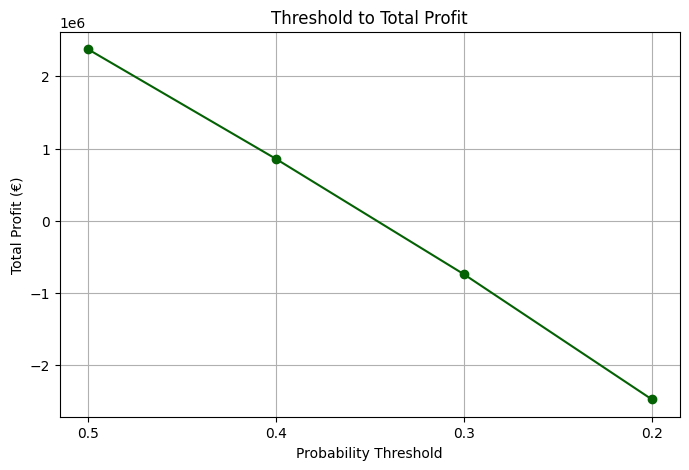

In [56]:
# Buat DataFrame ringkas
df_profit = pd.DataFrame({
    "Threshold": [round(t,2) for t in thresholds],
    "Total Profit (€)": total_profit
})

# Tampilkan tabel ringkas
print("=== Threshold to Total Profit ===")
display(df_profit.style.format({"Total Profit (€)": "€{:,.0f}"}))

# Plot
plt.figure(figsize=(8,5))
plt.plot(thresholds, total_profit, marker='o', linestyle='-', color="#046104")
plt.title("Threshold to Total Profit")
plt.xlabel("Probability Threshold")
plt.ylabel("Total Profit (€)")
plt.xticks(thresholds)
plt.grid(True)
plt.gca().invert_xaxis()  # Tampilkan threshold menurun dari kiri ke kanan
plt.show()

**Hotel Booking Predictive Insights**

**1. Revenue Impact**
- Model prediksi cancel meningkatkan profit €3,694,142 dibanding tanpa model (−€2,728,341).
- Total profit model saat threshold optimal (0.5): €2,375,707.
- Benefit TP per kamar: €137.10, Cost FP: €49.99.
- Maximum Cost FP agar tidak rugi: €195.23.

**2. Threshold Sensitivity**

| Threshold | Total Profit (€) |
| --------- | ---------------- |
| 0.5       | €2,375,707       |
| 0.4       | €858,494         |
| 0.3       | €-737,691        |
| 0.2       | €-2,469,070      |

- Optimal threshold: 0.5 → profit tertinggi, FP cost masih terkendali.
- Threshold lebih rendah → terlalu banyak booking diprediksi cancel → profit negatif.

**3. KPI**
- Average Daily Rate (ADR): €101.93
- Average Stay: 3.43 malam
- Loss per False Negative: €205.65
- Occupancy Rate: 6.99% → banyak kamar kosong akibat cancel
- RevPAR: €698.65

**4. Business Takeaways**
- Protect Revenue: Fokus pada booking yang diprediksi safe → mengurangi lost revenue.
- Optimize Threshold: Threshold 0.5 memberikan profit maksimal dengan FP cost terkendali.
- Operational Insight: Target segmen risiko tinggi untuk rebooking atau dynamic room allocation.
- Profit Sensitivity: FP cost tinggi (>€195) → profit bisa negatif, perlu strategi mitigasi.


---
# **VI. Importance Feature (Logreg)**
---

## Importance Feature (Logreg)
Faktor Paling Berpengaruh Untuk Menjawab Pertanyaan Business
- Feature Importance (Logristic Regression)
- Coefficient & Odds Ratio

In [57]:
# Ambil model Logistic Regression yang sudah ditune
logreg_model = tuned_trained["Logistic Regression"]

# Ambil nama fitur (dari preprocessor jika ada, atau kolom asli)
feature_names = (logreg_model.named_steps['preprocessor'].get_feature_names_out(X_train.columns)
                 if 'preprocessor' in logreg_model.named_steps else X_train.columns)

# Ambil koefisien
coef = logreg_model.named_steps['classifier'].coef_[0]

# Buat DataFrame feature importance
feature_importance_logreg = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
})

# Hitung Odds Ratio
feature_importance_logreg['Odds_Ratio'] = np.exp(feature_importance_logreg['Coefficient'])

# Tentukan arah pengaruh
feature_importance_logreg['Direction'] = np.where(feature_importance_logreg['Coefficient'] > 0, 'Meningkatkan', 'Menurunkan')

# Ambil Top 10 berdasarkan magnitude koefisien
feature_importance_logreg['Abs_Coeff'] = feature_importance_logreg['Coefficient'].abs()
top10_logreg = feature_importance_logreg.sort_values(by='Abs_Coeff', ascending=False).head(10)

# Tampilkan tabel Top 10
print("="*100)
print("TOP 10 FEATURE IMPORTANCE - LOGISTIC REGRESSION")
print("="*100)
print(top10_logreg[['Feature', 'Coefficient', 'Odds_Ratio', 'Direction']].to_string(index=False))
print("="*100)

TOP 10 FEATURE IMPORTANCE - LOGISTIC REGRESSION
                         Feature  Coefficient  Odds_Ratio    Direction
num__required_car_parking_spaces    -5.076849    0.006240   Menurunkan
    cat__deposit_type_Non Refund     2.709649   15.023999 Meningkatkan
     num__previous_cancellations     2.243909    9.430120 Meningkatkan
       cat__assigned_room_type_A     1.802217    6.063075 Meningkatkan
                cat__country_PRT     1.785667    5.963554 Meningkatkan
    cat__deposit_type_No Deposit    -1.636479    0.194664   Menurunkan
       cat__assigned_room_type_I    -1.483116    0.226929   Menurunkan
       cat__reserved_room_type_A    -1.436747    0.237700   Menurunkan
                cat__country_AGO     1.374429    3.952818 Meningkatkan
   cat__market_segment_Online TA     1.280718    3.599225 Meningkatkan


## Coefficient Plot: Top 10 Influential Features

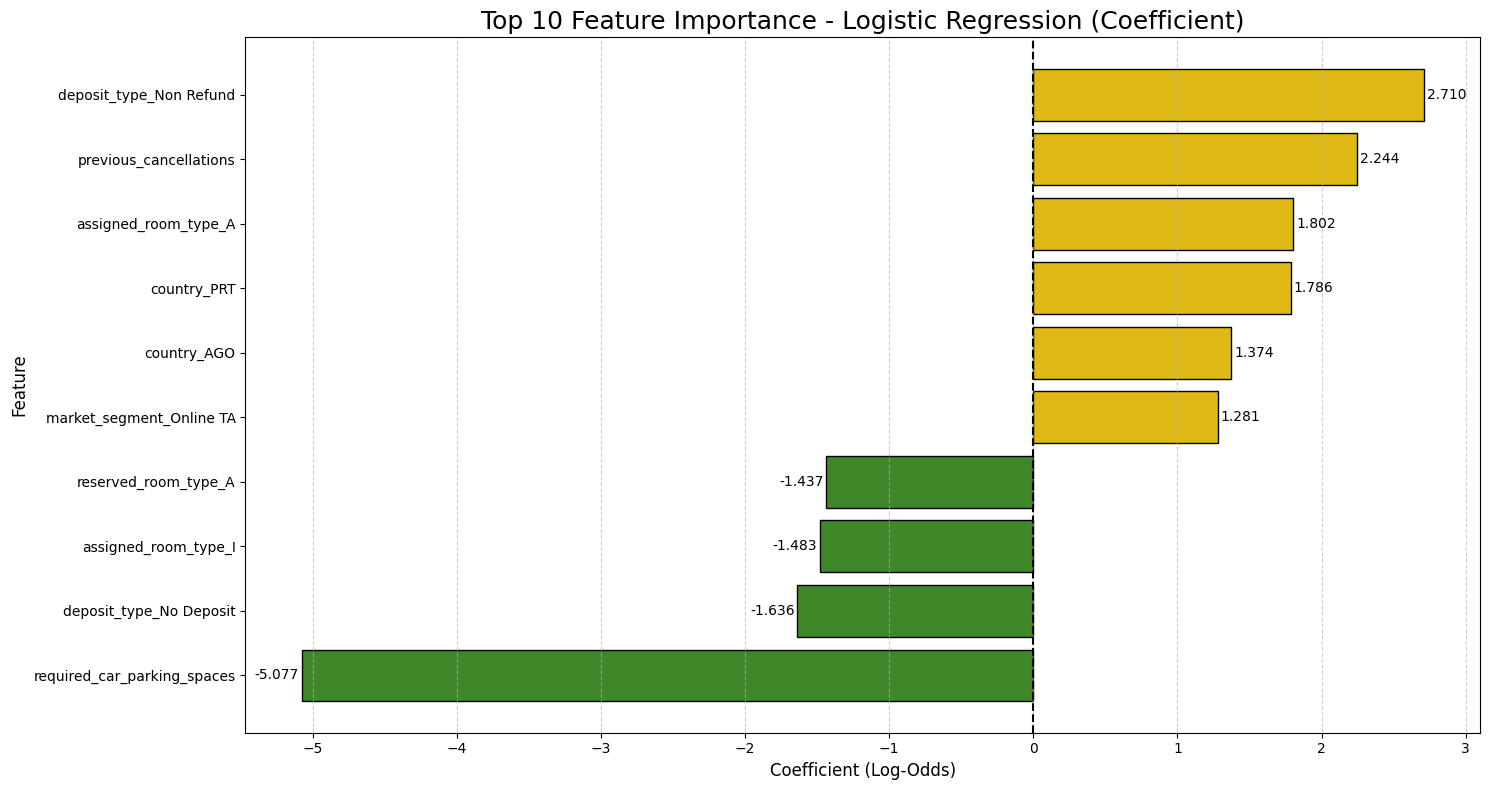

In [58]:
# Urutkan agar bar terbesar tampil di atas
top_features = top10_logreg.sort_values(by='Coefficient')

# Bersihkan prefix preprocessing
clean_features = (
    top_features['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

plt.figure(figsize=(15, 8))

# Warna berdasarkan arah pengaruh
colors = ['#DFBA17' if x > 0 else '#3F8829' 
          for x in top_features['Coefficient']]

bars = plt.barh(
    clean_features,
    top_features['Coefficient'],
    color=colors,
    edgecolor='black'
)

# Tambahkan garis tengah di 0
plt.axvline(x=0, color='black', linestyle='--')

# Tambahkan nilai coefficient di ujung bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (0.02 if width > 0 else -0.02),
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        ha='left' if width > 0 else 'right',
        fontsize=10
    )

plt.title("Top 10 Feature Importance - Logistic Regression (Coefficient)", fontsize=18)
plt.xlabel("Coefficient (Log-Odds)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Top 10 Feature Importance – Split by Direction (Odds Ratio)

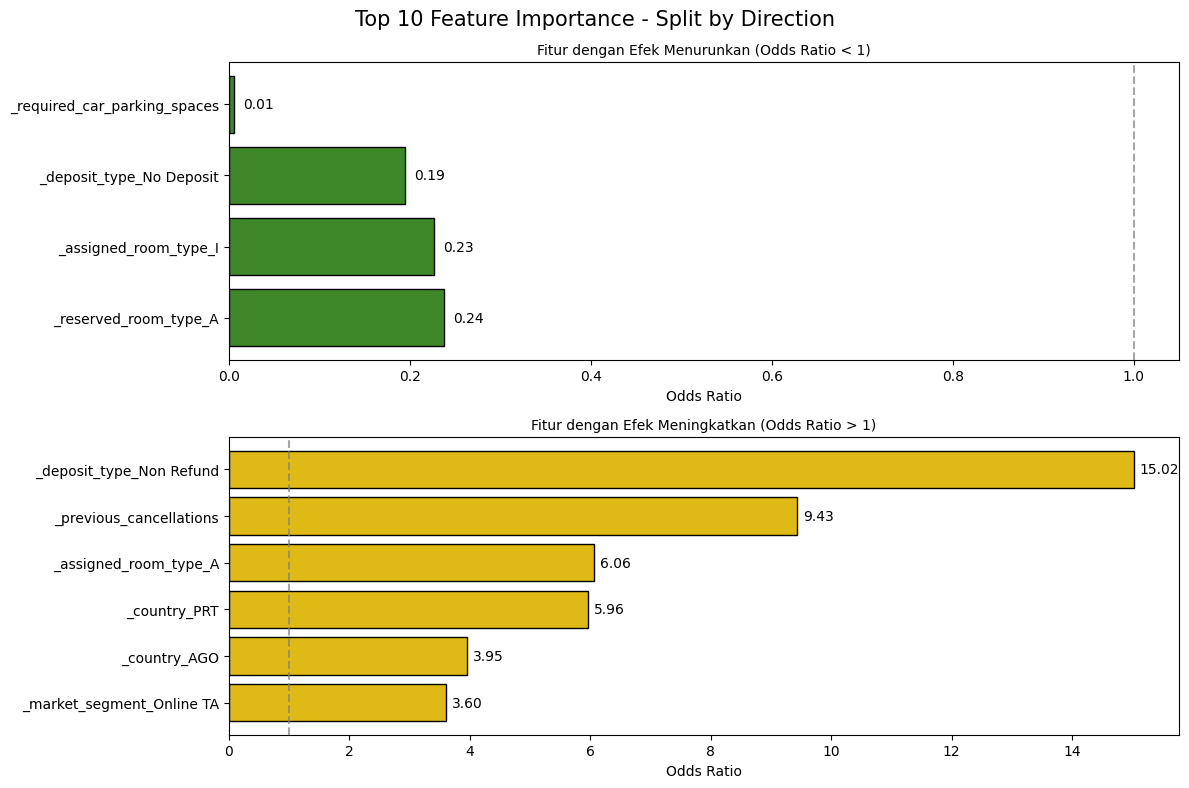

In [59]:
# SPLIT VISUALIZATION (LOW VS HIGH OR)

# Pisahkan fitur dengan odds ratio < 1 dan > 1
low_or = top10_logreg[top10_logreg['Odds_Ratio'] < 1].sort_values('Odds_Ratio', ascending=False)
high_or = top10_logreg[top10_logreg['Odds_Ratio'] > 1].sort_values('Odds_Ratio', ascending=True)

fig, (ax1, ax2) = plt.subplots(2,1,figsize=(12, 8))

# Plot untuk odds ratio < 1 (Menurunkan)
if not low_or.empty:
    bars1 = ax1.barh([f.replace('cat_', '').replace('num_', '')[:25] if len(f) > 100 else f.replace('cat_', '').replace('num_', '')
                      for f in low_or['Feature']], 
                     low_or['Odds_Ratio'], 
                     color="#3F8829", edgecolor='black')
    ax1.axvline(x=1, color='gray', linestyle='--', alpha=0.7)
    ax1.set_xlabel('Odds Ratio', fontsize=10)
    ax1.set_title('Fitur dengan Efek Menurunkan (Odds Ratio < 1)', fontsize=10)
    
    # Tambahkan nilai
    for i, (idx, row) in enumerate(low_or.iterrows()):
        ax1.text(row['Odds_Ratio']+0.01, i, f'{row["Odds_Ratio"]:.2f}', va='center')

# Plot untuk odds ratio > 1 (Meningkatkan)
if not high_or.empty:
    bars2 = ax2.barh([f.replace('cat_', '').replace('num_', '')[:25] if len(f) > 100 else f.replace('cat_', '').replace('num_', '')
                      for f in high_or['Feature']], 
                     high_or['Odds_Ratio'], 
                     color="#DFBA17", edgecolor='black')
    ax2.axvline(x=1, color='gray', linestyle='--', alpha=0.7)
    ax2.set_xlabel('Odds Ratio', fontsize=10)
    ax2.set_title('Fitur dengan Efek Meningkatkan (Odds Ratio > 1)', fontsize=10)
    
    # Tambahkan nilai
    for i, (idx, row) in enumerate(high_or.iterrows()):
        ax2.text(row['Odds_Ratio'] + 0.1 if row['Odds_Ratio'] else row['Odds_Ratio'], 
                i, f'{row["Odds_Ratio"]:.2f}', va='center',)

plt.suptitle('Top 10 Feature Importance - Split by Direction', fontsize=15)
plt.tight_layout()
plt.show()

## Top Drivers of Target Outcome – Interactive Visualization

In [60]:
# INTERACTIVE PLOT

try:
    import plotly.express as px
    import plotly.graph_objects as go
    
    # Buat figure interactive
    fig = go.Figure()
    
    # Tambahkan bar untuk Meningkatkan
    meningkat = top10_logreg[top10_logreg['Direction'] == 'Meningkatkan']
    if not meningkat.empty:
        fig.add_trace(go.Bar(
            y=meningkat['Feature'].apply(lambda x: x.replace('cat_', '').replace('num_', '')[:40]),
            x=meningkat['Odds_Ratio'],
            name='Meningkatkan',
            orientation='h',
            marker_color="#DFBA17",
            text=meningkat['Odds_Ratio'].round(2),
            textposition='outside'
        ))
    
    # Tambahkan bar untuk Menurunkan
    menurun = top10_logreg[top10_logreg['Direction'] == 'Menurunkan']
    if not menurun.empty:
        fig.add_trace(go.Bar(
            y=menurun['Feature'].apply(lambda x: x.replace('cat_', '').replace('num_', '')[:40]),
            x=menurun['Odds_Ratio'],
            name='Menurunkan',
            orientation='h',
            marker_color="#3F8829",
            text=menurun['Odds_Ratio'].round(2),
            textposition='outside'
        ))
    
    # Tambahkan garis vertikal di x=1
    fig.add_vline(x=1, line_dash="dash", line_color="black", opacity=0.7)
    
    # Update layout
    fig.update_layout(
        title='Top 10 Feature Importance - Logistic Regression (Interactive)',
        xaxis_title='Odds Ratio',
        yaxis_title='Feature',
        xaxis_type="log",
        barmode='group',
        height=600,
        width=1000,
        hovermode='y'
    )
    
    fig.show()
    
except ImportError:
    print("Plotly tidak terinstall. Untuk interactive plot, install dengan: pip install plotly")

**Interpretasi**

Logistic Regression memiliki koefisien per fitur (𝛽𝑖)
- Menunjukkan arah dan besarnya pengaruh tiap fitur terhadap probabilitas outcome.
- Bisa langsung diinterpretasikan untuk insight bisnis.
Prediksi berbasis probabilitas (antara 0–1).

**-- Makna Numerik Koefisien --**
- Logistic regression memodelkan log-odds dari probabilitas suatu event (di sini, pembatalan):

$$
\text{logit}(p) = \ln \frac{p}{1-p} = \beta_0 + \beta_1 X_1 + \dots + \beta_n X_n
$$

- **Koefisien positif (β > 0)** → meningkatkan log-odds pembatalan.  
  Contoh: `cat__assigned_room_type_A` (β = 1.688) → tipe kamar A **lebih mungkin dibatalkan**.

- **Koefisien negatif (β < 0)** → menurunkan log-odds pembatalan.  
  Contoh: `num__required_car_parking_spaces` (β = -5.004) → semakin banyak parkir dibutuhkan, **risiko cancel lebih rendah**.

**-- Dampak Relatif / Odds Ratio --**
- Koefisien dapat diubah menjadi **odds ratio (OR)**:

$$
\text{OR} = e^{\beta}
$$

- **OR > 1** → fitur meningkatkan peluang event (cancel).  
- **OR < 1** → fitur menurunkan peluang event (cancel).  
- Misal, β = 1.688 → OR ≈ 5.41 → odds cancel **5.4× lebih tinggi**.  
- Misal, β = -5.004 → OR ≈ 0.0067 → odds cancel **sangat rendah**.

| Feature                          | β       | OR     | Interpretasi Bisnis                                                                 |
| -------------------------------- | ------- | ------ | ----------------------------------------------------------------------------------- |
| num__required_car_parking_spaces | -5.0768 | 0.0062 | Tambahan 1 kebutuhan parkir → odds cancel turun 99.4%. Sangat low-risk guest.       |
| cat__deposit_type_Non Refund     | 2.7096  | 15.02  | Non-refundable deposit → odds cancel 15× lebih tinggi. Extremely high-risk segment. |
| num__previous_cancellations      | 2.2439  | 9.43   | Setiap riwayat cancel → risiko naik 9×. Strong behavioral predictor.                |
| cat__assigned_room_type_A        | 1.8022  | 6.06   | Assigned tipe A → 6× lebih berisiko cancel.                                         |
| cat__country_PRT                 | 1.7857  | 5.96   | Tamu Portugal → ~6× lebih berisiko cancel.                                          |
| cat__deposit_type_No Deposit     | -1.6365 | 0.195  | No deposit → risiko turun ~80%.                                                     |
| cat__assigned_room_type_I        | -1.4831 | 0.227  | Assigned tipe I → risiko turun ~77%.                                                |
| cat__reserved_room_type_A        | -1.4367 | 0.238  | Reserved tipe A → risiko turun ~76%.                                                |
| cat__country_AGO                 | 1.3744  | 3.95   | Tamu Angola → risiko ~4× lebih tinggi.                                              |
| cat__market_segment_Online TA    | 1.2807  | 3.60   | Booking via Online Travel Agent → risiko ~3.6× lebih tinggi.                        |

**Business Insights & Key Actions – Hotel Cancellation**

***Key Insights***
1. *Behavioral history is the strongest predictor*
   - Guest dengan *previous cancellations* memiliki risiko jauh lebih tinggi (9×).
   - Perilaku historis lebih menentukan dibanding faktor demografis.
2. *Deposit policy menunjukkan segment risk, bukan mitigasi murni*
   - *Non-Refund* memiliki risiko tertinggi (15×), mengindikasikan kebijakan ini diterapkan pada segmen high-risk.
   - Sebaliknya, *No Deposit* berkorelasi dengan risiko lebih rendah.
3. *OTA meningkatkan volatilitas okupansi*
   - Booking melalui *Online TA* memiliki risiko 3–4× lebih tinggi.
4. *Stabilitas alokasi kamar berpengaruh signifikan*
   - *Assigned Room Type A* meningkatkan risiko, sementara *Reserved Room Type A* menurunkan risiko
   - Perubahan kamar berpotensi memicu pembatalan.
5. *Parking adalah indikator komitmen tinggi*
   - Kebutuhan parkir berkorelasi kuat dengan risiko cancel yang sangat rendah.

***Key Actions (Mitigation & Prevention)***
- Terapkan **risk-based scoring** untuk menentukan deposit dan monitoring.
- Optimalkan **dynamic deposit policy** berdasarkan histori dan channel.
- Lakukan **reconfirmation campaign** untuk booking OTA dan high-risk segment.
- Minimalkan **room reassignment**, terutama untuk profil high-risk.
- Gunakan indikator low-risk (seperti parking) untuk mengurangi kebutuhan overbooking.

Pendekatan berbasis risk segmentation ini akan membantu menurunkan pembatalan dan meningkatkan stabilitas revenue.

## Top 10 Features Differentiating High Risk Customers
Ini menjawab pertanyaan ***“Pelanggan seperti apa berisiko tinggi membatalkan?”***

In [61]:
X_test_copy = X_test.copy()
X_test_copy["cancel_prob"] = y_prob

high_risk = X_test_copy[X_test_copy["cancel_prob"] > 0.7]
high_risk.describe()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,cancel_prob
count,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000,11398.000000,266.000000,12318.000000,12318.000000,12318.000000,12318.000000,12318.000000
mean,155.394950,2016.201818,27.365075,15.798425,0.957948,2.632814,1.930021,0.129648,0.003410,0.012827,0.243302,0.016642,0.079802,75.527549,178.390977,3.906641,108.817603,0.000162,0.262137,0.895514
std,120.977854,0.724785,12.750652,8.784893,1.067892,2.084600,0.587112,0.454467,0.061017,0.112531,1.478866,0.414049,0.351819,106.366453,119.788703,23.909461,48.839269,0.012742,0.542469,0.100896
min,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.700051
25%,56.000000,2016.000000,18.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,67.000000,0.000000,75.000000,0.000000,0.000000,0.804868
50%,133.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,169.000000,0.000000,99.265000,0.000000,0.000000,0.918785
75%,237.000000,2017.000000,37.000000,24.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,154.000000,223.000000,0.000000,130.000000,0.000000,0.000000,0.997397
max,709.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,27.000000,3.000000,2.000000,1.000000,26.000000,25.000000,8.000000,531.000000,504.000000,391.000000,382.000000,1.000000,5.000000,1.000000


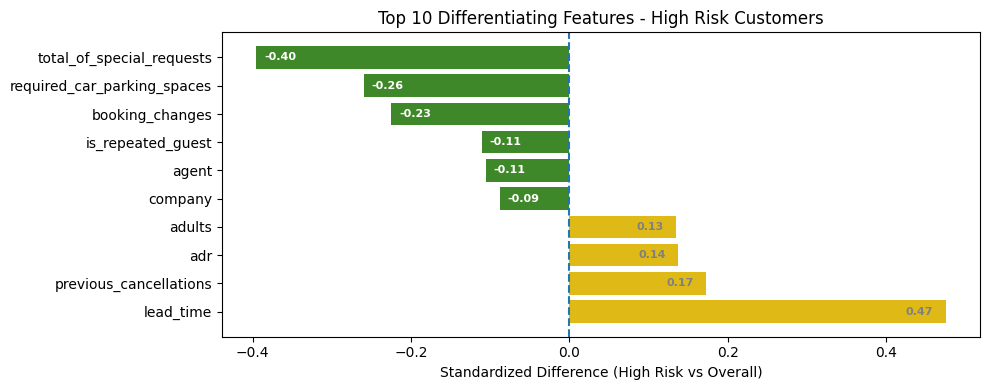

In [62]:
# Define segments
high_risk = X_test_copy[X_test_copy["cancel_prob"] > 0.7]
overall = X_test_copy

# Select numeric columns only
numeric_cols = overall.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("cancel_prob")

# Compute standardized difference
high_mean = high_risk[numeric_cols].mean()
overall_mean = overall[numeric_cols].mean()
overall_std = overall[numeric_cols].std()

standardized_diff = ((high_mean - overall_mean) / overall_std)
standardized_diff = standardized_diff.sort_values(key=abs, ascending=False)

# Take top 10
top_10 = standardized_diff.head(10).sort_values()

# Warna hijau: terang (positif), gelap (negatif)
colors = ["#DFBA17" if v > 0 else "#3F8829" for v in top_10.values]

plt.figure(figsize=(10,4))

bars = plt.barh(
    top_10.index,
    top_10.values,
    color=colors
)

# Tambahkan garis nol
plt.axvline(0, linestyle="--")

# Tambahkan angka di bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (-0.05 if width > 0 else +0.05),
        bar.get_y() + bar.get_height()*0.5,
        f"{width:.2f}",
        va="center",
        ha="left" if width > 0 else "right",
        fontsize=8,
        color="grey" if width > 0 else "white",
        fontweight="bold"
    )

plt.xlabel("Standardized Difference (High Risk vs Overall)")
plt.title("Top 10 Differentiating Features - High Risk Customers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretasi Analisis Standardized Difference**

Sumbu X menunjukkan selisih terstandarisasi antara segmen high-risk dan populasi keseluruhan:

$$
\frac{\text{Mean High Risk} - \text{Mean Overall}}{\text{Standar Deviasi Overall}}
$$

- Nilai positif → fitur lebih tinggi pada pelanggan high-risk
- Nilai negatif → fitur lebih rendah pada pelanggan high-risk
- Semakin jauh dari nol → semakin kuat perbedaannya

> Karena sudah dinormalisasi, seluruh variabel dapat dibandingkan secara adil meskipun memiliki skala asli yang berbeda.


**Fitur yang Lebih Tinggi pada Segmen High-Risk**

| Fitur                    | Arah         | Interpretasi Bisnis                                               | Implikasi                                                    |
| ------------------------ | ------------ | ----------------------------------------------------------------- | ------------------------------------------------------------ |
| Lead Time                | Lebih Tinggi | Pelanggan high-risk cenderung booking jauh hari sebelum check-in. | Semakin panjang lead time, semakin tinggi risiko pembatalan. |
| Previous Cancellations   | Lebih Tinggi | Riwayat pembatalan sebelumnya menjadi prediktor kuat.             | Pola historis sangat konsisten dalam memprediksi risiko.     |
| ADR (Average Daily Rate) | Lebih Tinggi | Harga kamar sedikit lebih tinggi pada segmen high-risk.           | Indikasi potensi sensitivitas harga atau perilaku switching. |
| Jumlah Dewasa (Adults)   | Lebih Tinggi | Jumlah dewasa sedikit lebih banyak pada booking high-risk.        | Efek relatif kecil, bukan driver utama.                      |

**Fitur yang Lebih Rendah pada Segmen High-Risk**

| Fitur                       | Arah         | Interpretasi Bisnis                                    | Implikasi                                                        |
| --------------------------- | ------------ | ------------------------------------------------------ | ---------------------------------------------------------------- |
| Total Special Requests      | Lebih Rendah | Tingkat engagement lebih rendah pada segmen high-risk. | Tamu dengan permintaan khusus cenderung lebih committed.         |
| Required Car Parking Spaces | Lebih Rendah | Lebih sedikit yang membutuhkan parkir.                 | Indikasi komitmen perjalanan lebih rendah.                       |
| Booking Changes             | Lebih Rendah | Lebih jarang melakukan perubahan booking.              | Cenderung langsung membatalkan dibanding menyesuaikan reservasi. |
| Repeated Guest              | Lebih Rendah | Lebih sedikit pelanggan loyal.                         | Loyalitas berperan sebagai faktor stabilisasi risiko.            |

**Interpretasi Strategis**

Karakteristik utama pelanggan high-risk meliputi:
- Melakukan booking lebih awal namun dengan sinyal komitmen rendah
- Tingkat engagement yang lebih rendah
- Riwayat pembatalan yang signifikan
- Loyalitas yang rendah

> Risiko pembatalan lebih banyak dipengaruhi oleh sinyal perilaku dan tingkat komitmen dibandingkan variabel demografis atau transaksional dasar.

**Kesimpulan Eksekutif**

Faktor utama yang memengaruhi risiko pembatalan adalah:
- Kepastian niat (intent certainty)
- Tingkat engagement
- Pola perilaku historis
- Kekuatan loyalitas

Strategi mitigasi risiko sebaiknya berfokus pada:
- Monitoring booking dengan lead time panjang dan engagement rendah
- Penguatan program loyalitas
- Identifikasi dini sinyal komitmen lemah
- Intervensi retensi yang proaktif

> Analisis ini memberikan dasar yang terstruktur untuk pengelolaan risiko pembatalan secara lebih presisi dan berbasis perilaku.


## Cancel Rate by Month – Overview
Ini menjawab pertanyaan ***Kapan periode pembatalan paling sering terjadi?***

In [63]:
# Urutan bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Hitung cancel rate per bulan dan per tahun
cancel_rate_year = (
    df.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"]
      .mean()
      .reset_index()
)

# Pastikan bulan sesuai urutan
cancel_rate_year['arrival_date_month'] = pd.Categorical(
    cancel_rate_year['arrival_date_month'], categories=month_order, ordered=True
)

cancel_rate_year = cancel_rate_year.sort_values(["arrival_date_year", "arrival_date_month"])

# Tampilkan per tahun
for year in sorted(cancel_rate_year['arrival_date_year'].unique()):
    print("\n" + "="*60)
    print(f" CANCELLATION PERIOD - YEAR {year} ".center(60))
    print("="*60 + "\n")
    
    year_data = cancel_rate_year[cancel_rate_year['arrival_date_year'] == year]
    
    for _, row in year_data.iterrows():
        percentage = row['is_canceled'] * 100
        bar = "█" * int(percentage // 2)  # 1 karakter = 2%
        print(f"{row['arrival_date_month']:12s} : {percentage:5.2f}%  {bar}")


              CANCELLATION PERIOD - YEAR 2015               

July         : 45.35%  ██████████████████████
August       : 41.09%  ████████████████████
September    : 40.95%  ████████████████████
October      : 34.94%  █████████████████
November     : 20.77%  ██████████
December     : 33.32%  ████████████████

              CANCELLATION PERIOD - YEAR 2016               

January      : 24.78%  ████████████
February     : 34.36%  █████████████████
March        : 30.62%  ███████████████
April        : 37.97%  ██████████████████
May          : 34.96%  █████████████████
June         : 39.61%  ███████████████████
July         : 32.79%  ████████████████
August       : 36.05%  ██████████████████
September    : 37.49%  ██████████████████
October      : 40.53%  ████████████████████
November     : 36.73%  ██████████████████
December     : 36.22%  ██████████████████

              CANCELLATION PERIOD - YEAR 2017               

January      : 33.96%  ████████████████
February     : 32.54%  █████

**Visualisasi Bar Chart (Cancel Rate by Month) Each Year**

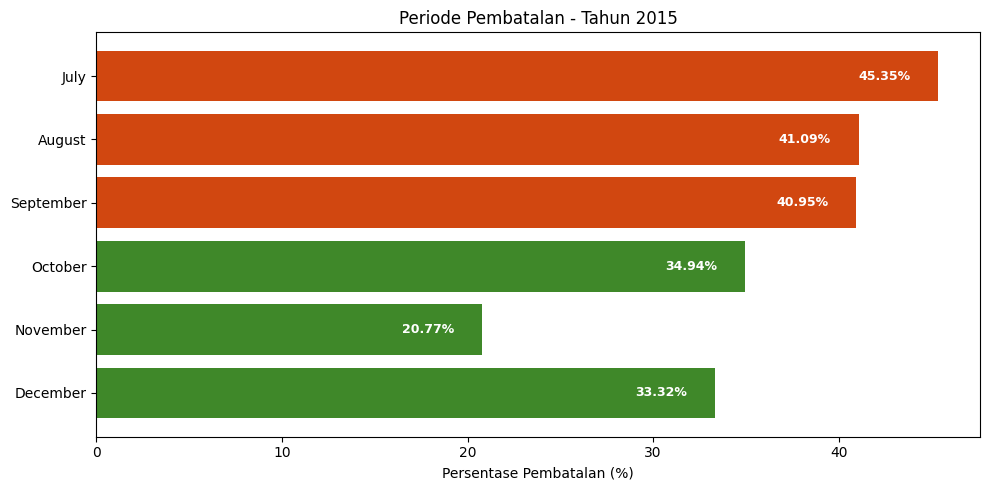

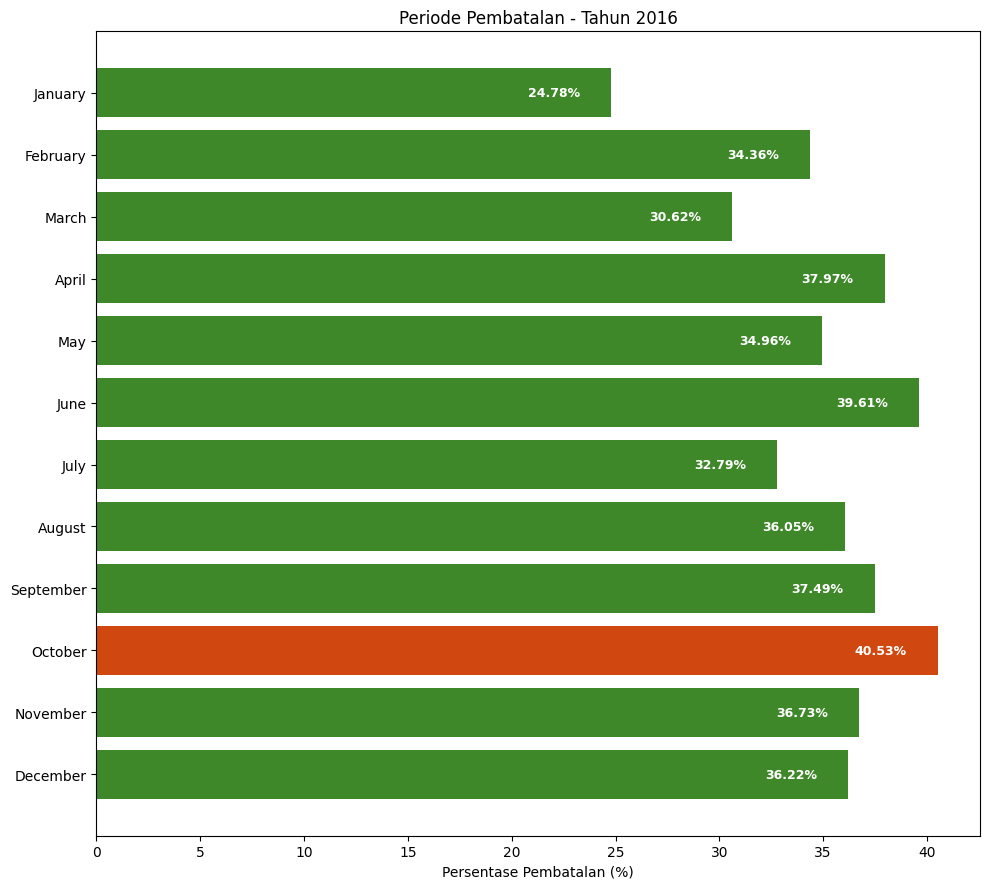

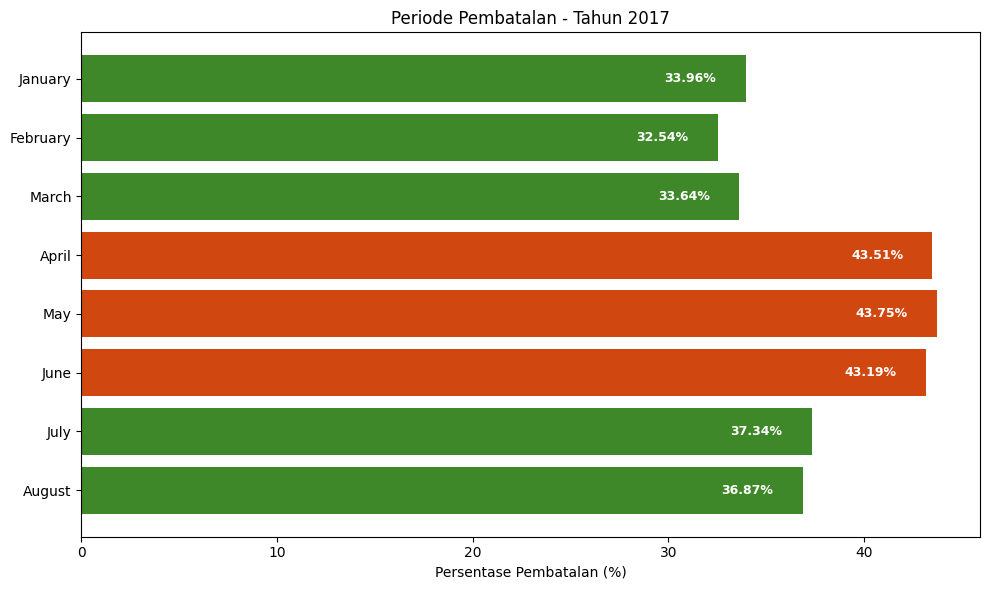

In [64]:
# Urutan bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Hitung cancel rate per bulan per tahun
cancel_rate_year = (
    df.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"]
      .mean()
      .reset_index()
)

# Pastikan bulan sesuai urutan
cancel_rate_year['arrival_date_month'] = pd.Categorical(
    cancel_rate_year['arrival_date_month'], categories=month_order, ordered=True
)

cancel_rate_year = cancel_rate_year.sort_values(["arrival_date_year", "arrival_date_month"])

# Loop untuk tiap tahun
years = sorted(cancel_rate_year['arrival_date_year'].unique())
colors_base = "#3F8829"  # warna default untuk bar
highlight_color = "#D14710"  # warna untuk bulan high-risk

fig_sizes = [(10,5), (10,9), (10,6)]  # ukuran figure berbeda per tahun

for i, year in enumerate(years):
    data = cancel_rate_year[cancel_rate_year['arrival_date_year'] == year]
    cancel_pct = data.set_index('arrival_date_month')['is_canceled'].reindex(month_order) * 100

    plt.figure(figsize=fig_sizes[i])

    # Tentukan warna bar: highlight jika >40%
    colors = [highlight_color if np.isfinite(p) and p >= 40 else colors_base for p in cancel_pct]

    bars = plt.barh(month_order, cancel_pct, color=colors)

    # Tambahkan label persentase
    for bar, pct in zip(bars, cancel_pct):
        if np.isfinite(pct):
            x_pos = bar.get_width() - 1.5
            plt.text(
                x_pos,
                bar.get_y() + bar.get_height()/2,
                f'{pct:.2f}%',
                va='center',
                ha='right',
                color='white',
                fontsize=9,
                fontweight='bold'
            )

    plt.xlabel('Persentase Pembatalan (%)')
    plt.title(f'Periode Pembatalan - Tahun {year}')
    plt.gca().invert_yaxis()  # Januari di atas
    plt.grid(False)
    plt.tight_layout()
    plt.show()

**Visualisasi Line Chart (Cancel Rate by Month) Each Year**

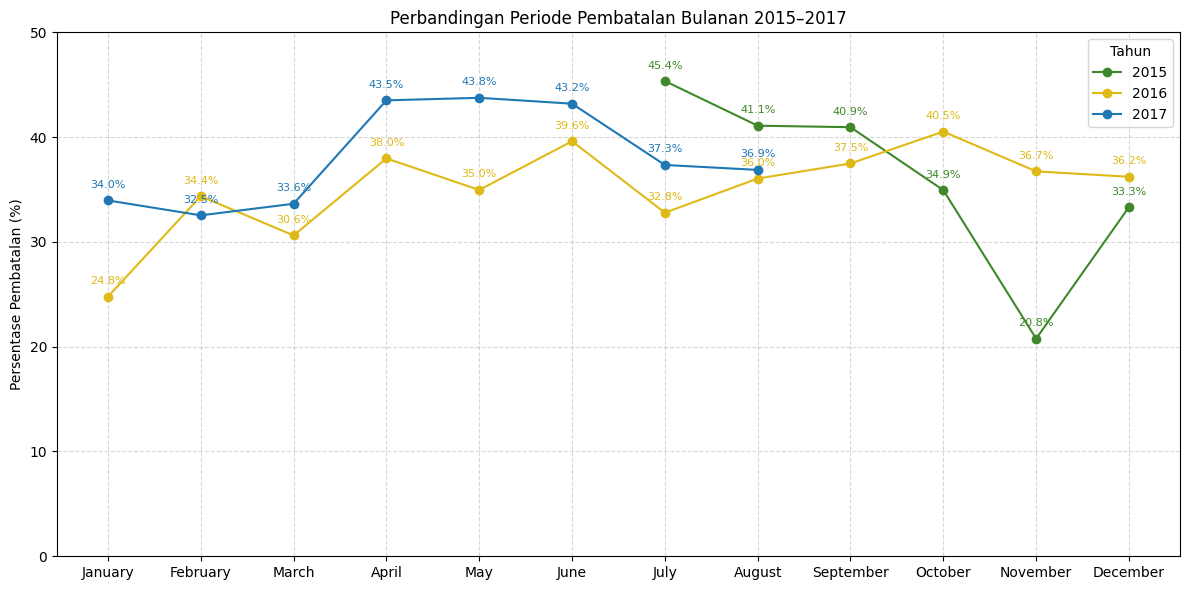

In [65]:
# Urutan bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Hitung cancel rate per bulan per tahun
cancel_rate_year = (
    df.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"]
      .mean()
      .reset_index()
)

# Pastikan bulan sesuai urutan
cancel_rate_year['arrival_date_month'] = pd.Categorical(
    cancel_rate_year['arrival_date_month'], categories=month_order, ordered=True
)

cancel_rate_year = cancel_rate_year.sort_values(["arrival_date_year", "arrival_date_month"])

# Warna line per tahun
colors = {2015:"#3F8829", 2016:"#DFBA17", 2017:"#1F77B4"}

plt.figure(figsize=(12,6))

for year in sorted(cancel_rate_year['arrival_date_year'].unique()):
    data = cancel_rate_year[cancel_rate_year['arrival_date_year'] == year]
    cancel_pct = data.set_index('arrival_date_month')['is_canceled'].reindex(month_order) * 100
    
    # Line chart
    plt.plot(month_order, cancel_pct, marker='o', color=colors[year], label=str(year))
    
    # Tambahkan label pada titik dengan nilai finite
    for month, pct in zip(month_order, cancel_pct):
        if pd.notna(pct):
            plt.text(month, pct + 1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=8, color=colors[year])

plt.title("Perbandingan Periode Pembatalan Bulanan 2015–2017")
plt.xlabel('')
plt.ylabel("Persentase Pembatalan (%)")
plt.ylim(0, 50)  # agar visual nyaman
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tahun')
plt.tight_layout()
plt.show()

**Interactive Line Chart (Cancel Rate by Month) Each Year**

In [66]:
# Bulan lengkap & singkatan
month_order_full = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']
month_order = [m[:3] for m in month_order_full]

# Hitung cancel rate & total cancel per bulan per tahun
cancel_stats = (
    df.groupby(["arrival_date_year", "arrival_date_month"])["is_canceled"]
      .agg(['mean', 'sum'])
      .reset_index()
)

# Bulan jadi 3 huruf
cancel_stats['month_abbr'] = cancel_stats['arrival_date_month'].str[:3]

# Pastikan bulan sesuai urutan
cancel_stats['month_abbr'] = pd.Categorical(
    cancel_stats['month_abbr'], categories=month_order, ordered=True
)

cancel_stats = cancel_stats.sort_values(["arrival_date_year", "month_abbr"])

# Warna per tahun
colors = {2015:"#3F8829", 2016:"#DFBA17", 2017:"#1F77B4"}

fig = go.Figure()

# Line chart per tahun dengan tooltip Cancel Rate + Total Cancel
for year in sorted(cancel_stats['arrival_date_year'].unique()):
    data = cancel_stats[cancel_stats['arrival_date_year'] == year]
    cancel_pct = data.set_index('month_abbr')['mean'].reindex(month_order) * 100
    cancel_sum = data.set_index('month_abbr')['sum'].reindex(month_order)

    fig.add_trace(go.Scatter(
        x=month_order,
        y=cancel_pct,
        mode='lines+markers',
        name=str(year),
        line=dict(color=colors[year], width=3),
        marker=dict(size=8),
        hovertemplate=(
            "Bulan: %{x}<br>"
            "Cancel Rate: %{y:.1f}%<br>"
            "Total Cancel: %{customdata}<extra></extra>"
        ),
        customdata=cancel_sum
    ))

# Marker merah untuk visual bulan high-risk (>40%) dengan legend
added_to_legend = False
for year in sorted(cancel_stats['arrival_date_year'].unique()):
    data = cancel_stats[cancel_stats['arrival_date_year'] == year]
    cancel_pct = data.set_index('month_abbr')['mean'].reindex(month_order) * 100
    high_risk_months = cancel_pct[cancel_pct >= 40].index
    for month in high_risk_months:
        fig.add_trace(go.Scatter(
            x=[month],
            y=[cancel_pct[month]],
            mode='markers',
            marker=dict(color='red', size=12, symbol='diamond'),
            name='High Risk (>40%)' if not added_to_legend else None,  # legend sekali
            hoverinfo='skip',  # tooltip di-skip
            showlegend=not added_to_legend
        ))
        added_to_legend = True

fig.update_layout(
    title="Interactive Line Chart - Monthly Cancel Rate 2015–2017",
    xaxis_title="",
    yaxis_title="Persentase Pembatalan (%)",
    yaxis=dict(range=[0, 50]),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(title="Year & High-Risk Marker")
)

fig.show()

**Summary Periode Pembatalan 2015–2017**

**2015**
- Bulan dengan pembatalan tertinggi: July (45.35%), diikuti August (41.09%) dan September (40.95%).
- Bulan dengan pembatalan terendah: November (20.77%).
- Tren: Pembatalan memuncak pada musim liburan tengah tahun (July–September), menurun menuju akhir tahun.

**2016**
- Pembatalan relatif lebih merata sepanjang tahun dibanding 2015.
- Peak pembatalan: October (40.53%) dan June (39.61%).
- Pembatalan rendah tercatat pada January (24.78%) dan March (30.62%).
- Tren: Ada dua puncak pembatalan, awal musim panas (June) dan akhir musim gugur (October).

**2017**
- Pembatalan meningkat signifikan pada awal hingga pertengahan tahun: April (43.51%), May (43.75%), June (43.19%).
- Bulan dengan pembatalan lebih rendah: July (37.34%), August (36.87%).
- Tren: Puncak pembatalan lebih awal dibanding 2015, menunjukkan shift ke musim semi–awal musim panas.

**Suggestion for Mitigation/Preventive Action**

| **Key Action Area**                         | **Detail / Tindakan**                                                                                                                                                                 |
| ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Optimalkan strategi manajemen kapasitas** | - Fokus pada bulan high-risk: **April–July dan October (2015–2017)**.<br>- Terapkan kebijakan **penalty atau deposit awal** untuk mengurangi pembatalan mendadak.                     |
| **Segmentasi promosi**                      | - Manfaatkan bulan low-risk (misal **November 2015, January 2016**) untuk menarik reservasi tambahan.<br>- Kembangkan **paket menarik** untuk bulan high-risk agar tamu lebih commit. |
| **Analisis faktor pembatalan**              | - Identifikasi apakah **channel, tipe kamar, atau promo tertentu** meningkatkan risiko pembatalan.<br>- Gunakan **predictive model** untuk mendeteksi early cancellation risk.        |
| **Komunikasi proaktif ke tamu**             | - Kirim **reminder, konfirmasi, atau pre-payment** pada bulan high-risk untuk mengurangi pembatalan mendadak.                                                                         |


**Cancel Rate per Month Across Years 2015–2017**

In [67]:
# Urutan bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Hitung rata-rata cancel rate per bulan untuk semua tahun
cancel_rate_all_years = (
    df.groupby("arrival_date_month")["is_canceled"]
      .mean()
      .reindex(month_order)
)

# Tampilkan dengan bar
print("\n" + "="*60)
print(" PERIODE PEMBATALAN RATA-RATA 2015–2017 ".center(60))
print("="*60 + "\n")

for month, rate in cancel_rate_all_years.items():
    percentage = rate * 100
    bar = "█" * int(percentage // 2)  # 1 karakter = 2%
    print(f"{month:12s} : {percentage:5.2f}%  {bar}")


           PERIODE PEMBATALAN RATA-RATA 2015–2017           

January      : 30.48%  ███████████████
February     : 33.42%  ████████████████
March        : 32.15%  ████████████████
April        : 40.80%  ████████████████████
May          : 39.67%  ███████████████████
June         : 41.46%  ████████████████████
July         : 37.45%  ██████████████████
August       : 37.75%  ██████████████████
September    : 39.17%  ███████████████████
October      : 38.05%  ███████████████████
November     : 31.23%  ███████████████
December     : 34.97%  █████████████████


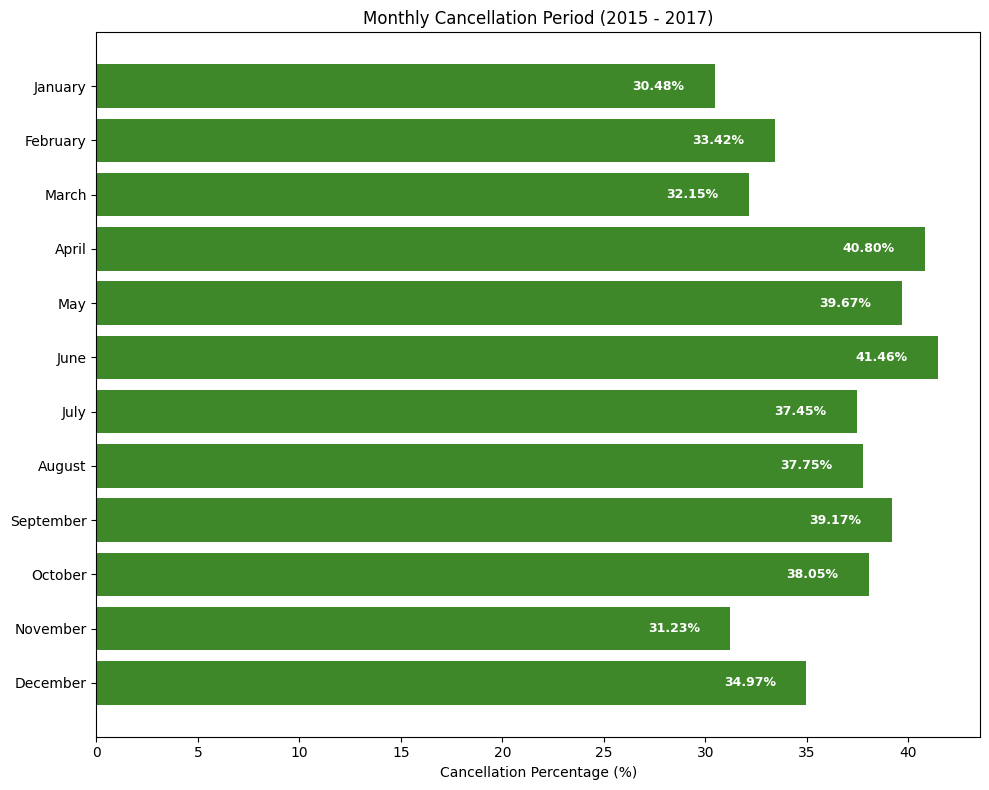

In [68]:
# Urutan bulan
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Hitung cancel rate dan urutkan
cancel_rate = (
    df.groupby("arrival_date_month")["is_canceled"]
      .mean()
      .reindex(month_order)
)

# Ubah ke persen
cancel_pct = cancel_rate * 100

# Buat figure
plt.figure(figsize=(10,8))
bars = plt.barh(month_order, cancel_pct, color="#3F8829")

# Tambahkan label persentase di dalam batang
for bar, pct in zip(bars, cancel_pct):
    x_pos = bar.get_width() - 1.5  # margin dari ujung batang
    plt.text(
        x_pos,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.2f}%',
        va='center',
        ha='right',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

# Judul dan label
plt.title('Monthly Cancellation Period (2015 - 2017)')
plt.xlabel('Cancellation Percentage (%)')
plt.gca().invert_yaxis()  # Januari di atas
plt.grid(False)

plt.tight_layout()
plt.show()

| **Bulan** | **Cancel Rate (%)** | **Risk Level / Insight**                             |
| --------- | ------------------- | ---------------------------------------------------- |
| January   | 30.48               | Low-risk – bisa fokus promosi & paket tambahan       |
| February  | 33.42               | Low–medium risk                                      |
| March     | 32.15               | Low–medium risk                                      |
| April     | 40.80               | High-risk – tingkatkan pengelolaan kapasitas         |
| May       | 39.67               | High-risk – fokus kontrol pembatalan                 |
| June      | 41.46               | High-risk – alokasikan kapasitas & staf optimal      |
| July      | 37.45               | Medium–high risk                                     |
| August    | 37.75               | Medium–high risk                                     |
| September | 39.17               | High-risk – pastikan strategi retention & komunikasi |
| October   | 38.05               | Medium–high risk                                     |
| November  | 31.23               | Low-risk – peluang promosi tambahan                  |
| December  | 34.97               | Medium risk – tetap monitor pembatalan               |

**Key Action/Recommendation**

| **Area Strategi**        | **Tindakan / Insight**                                                                                                               |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------ |
| **Manajemen Kapasitas**  | Fokus pada **April–June & September–October** (high-risk). Terapkan **deposit awal / penalty** untuk mengurangi pembatalan mendadak. |
| **Promosi & Segmentasi** | Manfaatkan bulan **low-risk** (**Jan, Feb, Mar, Nov, Dec**) untuk **promosi tambahan / paket menarik**.                              |
| **Analisis Risiko**      | Identifikasi faktor pembatalan (**channel, tipe kamar, promo**). Gunakan **predictive model** untuk deteksi early cancellation.      |
| **Komunikasi Tamu**      | Kirim **reminder / konfirmasi / pre-payment notice** di bulan high-risk agar tamu lebih berkomitmen.                                 |


## Cancellation Rates by Distribution Channel
Ini untuk menjawab Channel dengan cancel rate terendah (Paling Stabil)

In [69]:
# Hitung cancel rate berdasarkan distribution channel
df['distribution_channel'] = df['distribution_channel'].replace('Undefined', 'Others')
cancel_rate_channel = df.groupby("distribution_channel")["is_canceled"].mean().sort_values()

# Tampilkan dengan format yang rapi
print("\n" + "="*60)
print(" TINGKAT PEMBATALAN BERDASARKAN DISTRIBUTION CHANNEL ".center(60))
print("="*60 + "\n")

for channel, rate in cancel_rate_channel.items():
    percentage = rate * 100
    bar = "█" * int(percentage // 2)  # 1 karakter = 2%
    print(f"{channel:20s} : {percentage:5.2f}%  {bar}")


    TINGKAT PEMBATALAN BERDASARKAN DISTRIBUTION CHANNEL     

Direct               : 17.46%  ████████
GDS                  : 19.17%  █████████
Corporate            : 22.08%  ███████████
TA/TO                : 41.03%  ████████████████████
Others               : 80.00%  ████████████████████████████████████████


**Visualisasi Bar Chart (Cancel Rate by Distribution Channel)**

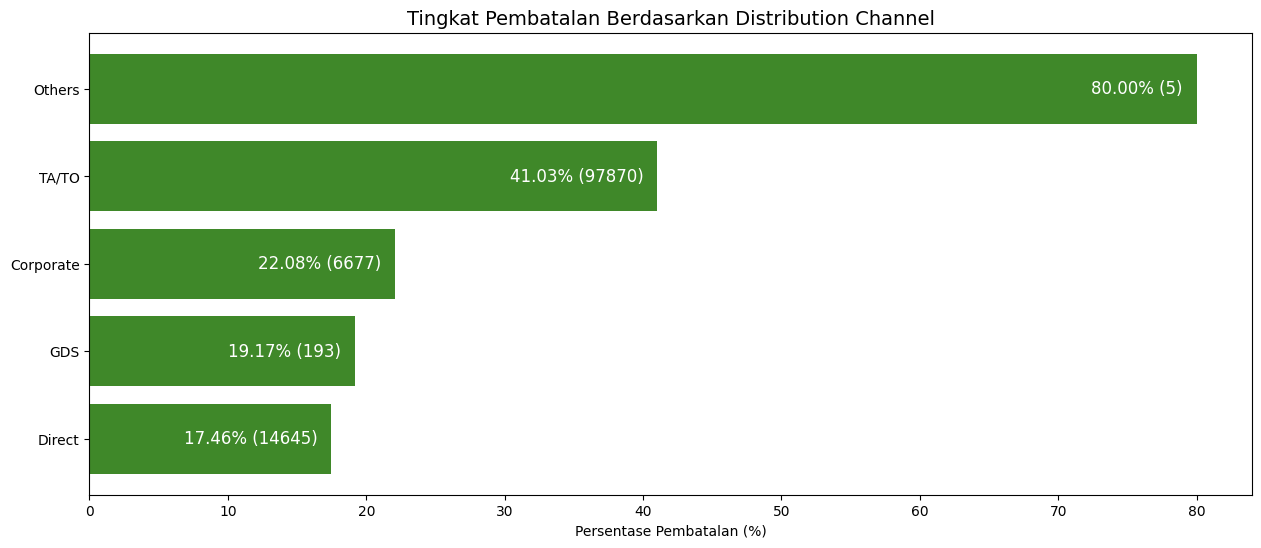

In [70]:
import matplotlib.pyplot as plt

# Ambil data cancel_rate_channel (Series: index=channel, values=cancel rate)
channels = cancel_rate_channel.index.tolist()
rates = cancel_rate_channel.values * 100  # ubah ke persen

# Hitung jumlah booking per channel
counts = df['distribution_channel'].value_counts().reindex(channels).values

# Buat figure
plt.figure(figsize=(15,6))
bars = plt.barh(channels, rates, color='#3F8829')

# Tambahkan label persentase + jumlah booking di dalam batang
for bar, rate, count in zip(bars, rates, counts):
    x_pos = bar.get_width() - 1  # di dalam batang
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, f'{rate:.2f}% ({count})', 
             va='center', ha='right', color='white', fontsize=12)

# Judul dan label
plt.title('Tingkat Pembatalan Berdasarkan Distribution Channel', fontsize=14)
plt.xlabel('Persentase Pembatalan (%)')

# Hilangkan grid
plt.grid(False)

plt.show()

In [71]:
# Ringkas total booking, total cancel, cancel rate (%)
channel_summary = (
    df.groupby('distribution_channel')
    .agg(Total_Booking=('is_canceled', 'count'),
         Total_Cancel=('is_canceled', 'sum'))
    .assign(Total_Cancel=lambda x: x['Total_Cancel'].round(2),
            Cancel_Rate=lambda x: (x['Total_Cancel'] / x['Total_Booking'] * 100)).round(2)
)

print(channel_summary)

                      Total_Booking  Total_Cancel  Cancel_Rate
distribution_channel                                          
Corporate                      6677          1474        22.08
Direct                        14645          2557        17.46
GDS                             193            37        19.17
Others                            5             4        80.00
TA/TO                         97870         40152        41.03


**Interpretasi Channel Distribution**

| Distribution Channel | Total Booking | Total Cancel | Cancel Rate | Interpretasi                                                                                          |
| -------------------- | ------------- | ------------ | ----------- | ----------------------------------------------------------------------------------------------------- |
| **Corporate**        | 6,677         | 1,474        | 22.08%      | Relatif stabil, namun tidak serendah yang diasumsikan sebelumnya. Tetap lebih rendah dibanding TA/TO. |
| **Direct**           | 14,645        | 2,557        | 17.46%      | Paling stabil di antara channel utama. Direct booking menunjukkan komitmen lebih tinggi.              |
| **GDS**              | 193           | 37           | 19.17%      | Risiko menengah. Namun volume sangat kecil sehingga perlu hati-hati dalam generalisasi.               |
| **TA/TO**            | 97,870        | 40,152       | 41.03%      | Channel dengan risiko tinggi dan volume terbesar. Kontributor utama pembatalan secara absolut.        |
| **Others**           | 5             | 4            | 80.00%      | Sangat tinggi, tetapi volume sangat kecil. Tidak representatif secara statistik.                      |

**Implikasi & Rekomendasi Bisnis**

| Kategori Risiko                 | Channel   | Cancel Rate | Karakteristik Utama                                                | Implikasi Bisnis                                                           | Rekomendasi Strategis                                                                                         |
| ------------------------------- | --------- | ----------- | ------------------------------------------------------------------ | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| Paling Stabil                   | Direct    | 17.46%      | Tingkat komitmen tertinggi di antara channel utama                 | Pelanggan lebih committed terhadap booking                                 | Perkuat direct campaign; optimalkan loyalty program; strategi upselling                                       |
| Risiko Menengah                 | Corporate | 22.08%      | Relatif terkendali, namun tidak serendah asumsi awal               | Dipengaruhi perubahan jadwal bisnis dan fleksibilitas kebijakan perusahaan | Monitoring segmentasi; evaluasi kebijakan fleksibilitas                                                       |
| Risiko Menengah                 | GDS       | 19.17%      | Risiko moderat dengan volume kecil                                 | Dampak terhadap total cancel relatif rendah                                | Observasi dan monitoring berkala                                                                              |
| Risiko Tinggi & Berdampak Besar | TA/TO     | 41.03%      | Hampir 2x Direct; kontributor pembatalan terbesar (40.152 booking) | High leverage point terhadap revenue loss                                  | Kebijakan deposit lebih ketat; reminder otomatis; dynamic pricing berbasis risk score; evaluasi kontrak agent |
| Outlier Data                    | Others    | 80.00%      | Volume sangat kecil (5 booking)                                    | Tidak representatif secara statistik                                       | Audit definisi channel; validasi kualitas data                                                                |

**Summary**
- TA/TO adalah sumber utama risiko pembatalan, baik dari sisi rate maupun volume.
- Direct channel paling stabil dan sebaiknya menjadi fokus ekspansi.
- Corporate masih relatif aman, namun tidak se-stabil Direct.
- Channel dengan volume sangat kecil tidak boleh dijadikan dasar keputusan tanpa validasi statistik.


> *TA → Travel Agent: Agen atau perusahaan yang menjual produk perjalanan secara individual kepada pelanggan.*
> *TO → Tour Operator: Perusahaan yang menyusun dan menjual paket perjalanan terintegrasi.*

---
# **SUCCESS METRICS**
---

## ✅ Objective 1: Predict Cancellation Risk

### **Primary Metric**
- Recall (Class = Cancelled) ✅
  - Untuk mengukur seberapa banyak booking yang benar-benar cancel berhasil dideteksi oleh model.
  - *Sangat penting karena missed cancellation = revenue risk.*

### **Supporting Metrics**

  - **F2-Score** ✅
      - Memberi bobot lebih besar pada Recall dibanding Precision (cocok untuk risk mitigation).
  - **AUC-ROC** ✅
      - Mengukur kemampuan model membedakan cancel vs non-cancel secara umum.
  - **Confusion Matrix** ✅
      - Untuk memahami trade-off bisnis (False Positive vs False Negative).

> *Note:* Karena objective-nya adalah **akurasi prediksi risiko**, bukan sekadar klasifikasi biasa.

---

In [72]:
print("--- Baseline vs Tuned Model Comparison ---")
BT_Comparison

--- Baseline vs Tuned Model Comparison ---


,Model,Recall (Test),F1 (Test),F2 (Test),ROC-AUC (Test),PR-AUC (Test),Log Loss (Test)
0,Baseline,0.66,0.73,0.69,0.9,0.86,0.38
1,Tuned,0.89,0.74,0.82,0.9,0.85,0.46


| Metric       | Baseline | Tuned    | Interpretasi                                                    |
| ------------ | -------- | -------- | --------------------------------------------------------------- |
| **Recall**   | 0.66     | **0.89** | Peningkatan signifikan dalam menangkap kasus positif            |
| **F1 Score** | 0.73     | **0.74** | Sedikit meningkat; keseimbangan precision–recall relatif stabil |
| **F2 Score** | 0.69     | **0.82** | Peningkatan kuat pada metrik yang menekankan recall             |
| **ROC-AUC**  | 0.90     | 0.90     | Kemampuan diskriminasi tetap sama                               |
| **PR-AUC**   | **0.86** | 0.85     | Sedikit menurun; indikasi trade-off precision                   |
| **Log Loss** | **0.38** | 0.46     | Kalibrasi probabilitas memburuk                                 |

- Model tuned pada **Recall** jauh lebih efektif menangkap kasus positif. False negative berkurang drastis, sehingga risiko kehilangan kasus penting menurun.
- Karena **F2** menekankan recall, peningkatan ini menegaskan bahwa tuning berhasil mengoptimalkan model untuk skenario recall-oriented.
- **F1 Score relatif stabil**, keseimbangan precision–recall tetap terjaga. Peningkatan recall tidak merusak performa keseluruhan secara signifikan.
- ROC-AUC tetap (0.90). Kemampuan diskriminasi model tidak berubah. Tuning tidak meningkatkan separability.
- Penurunan kecil pada **PR-AUC** menunjukkan trade-off klasik: recall naik dengan sedikit penurunan precision.
- Kalibrasi probabilitas **(Log Loss)** menurun. Model lebih agresif terhadap kelas positif, tetapi estimasi probabilitas menjadi kurang presisi.

### *Executive Summary — Logistic Regression Based on F2–Score*

- Baseline Model (F2 = 0.69): Cukup baik, namun masih menyisakan false negative yang signifikan sehingga kurang optimal untuk mitigasi risiko tinggi.
- Tuned Model (F2 = 0.82): Peningkatan kuat dalam menangkap kasus positif, secara efektif menekan false negative.
- Business Insight: Tuned Model lebih tepat untuk skenario risk-sensitive (misalnya cancellation), karena memberikan proteksi risiko lebih kuat dengan trade-off precision yang masih terkendali.

> Tuned Model unggul dalam skenario mitigasi risiko karena secara signifikan meningkatkan recall tanpa mengorbankan keseimbangan performa secara drastis, sehingga lebih andal untuk intervensi bisnis kritikal.

### *Executive Summary — Logistic Regression Performance Based on ROC-AUC*

1. **ROC Curve Analysis**
    - Model Discrimination: ROC-AUC sebesar 0.90 menunjukkan kemampuan diskriminasi yang sangat kuat; model memiliki probabilitas 90% untuk memberi skor lebih tinggi pada kasus positif dibanding negatif.
    - Interpretasi Teknis: Separability antar kelas tinggi dan konsisten di berbagai threshold.
    - Implikasi: Karena nilai ROC-AUC tidak berubah antara Baseline dan Tuned, peningkatan performa berasal dari optimasi sensitivitas (recall), bukan peningkatan kualitas pemisahan kelas.
    
    > **Kesimpulan:** Model memiliki kemampuan diskriminasi yang kuat, mendekati klasifikasi ideal.

2. **Precision-Recall Curve Analysis**
    - Kualitas Ranking Tetap Kuat: Dengan ROC-AUC tinggi, model menghasilkan ranking risiko yang solid, sehingga booking dengan risiko tertinggi memang cenderung benar-benar lebih berisiko.
    - Relevansi pada Data Imbalance: Dalam konteks pembatalan (data tidak seimbang), ROC-AUC 0.90 menunjukkan model tetap efektif membedakan kelas meskipun proporsi positif lebih kecil.
    - Perbandingan Baseline vs Tuned: Tidak ada peningkatan pada AUC, sehingga tuning lebih berperan dalam menggeser sensitivitas keputusan daripada meningkatkan kualitas pemisahan kelas.

3. **Business Insight**
    - Model memiliki kemampuan diskriminasi yang kuat dan stabil, sehingga dapat diandalkan untuk risk scoring.
    - Cocok digunakan sebagai dasar:
        - Prioritisasi booking berisiko tinggi
        - Segmentasi risiko
        - Sistem early warning
    - Perubahan strategi operasional (misalnya intervensi agresif) dapat dilakukan tanpa khawatir terhadap penurunan kualitas pemisahan kelas, seperti:
        - Deposit Wajib / Non-Refunable
        - Reminder & Reconfirmation


> Dengan ROC-AUC 0.90, model menunjukkan kemampuan diskriminasi yang sangat solid dan layak dijadikan fondasi sistem prediksi risiko. Optimalisasi lebih lanjut sebaiknya difokuskan pada strategi threshold dan cost-sensitive decision, bukan pada peningkatan separability model.

### *Executive Summary — Tuned Logistic Regression (Threshold 0.4)*


--- Matrics ---

Accuracy : 0.729
Precision: 0.583
Recall   : 0.935
F1 Score : 0.718
F2 Score : 0.834


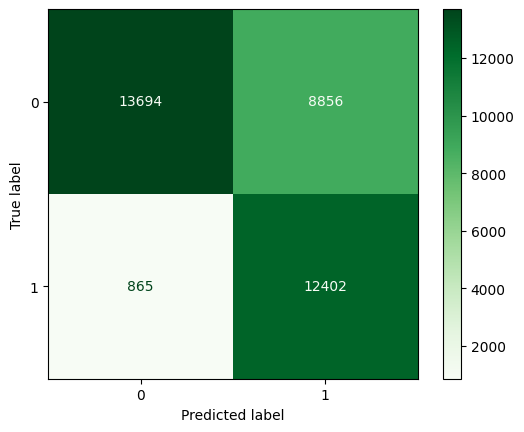

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score, f1_score

# Prediksi dengan threshold 0.4
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.4).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Greens')

# Hitung metrik
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
f2 = (1 + 2**2) * (precision * recall) / ((2**2 * precision) + recall)

# Tampilkan hasil
print("--- Matrics ---\n")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"F2 Score : {f2:.3f}")

- Accuracy: 0.729 → Model memprediksi dengan benar sekitar 73% dari seluruh kasus.
- Precision: 0.583 → Dari semua prediksi cancel, sekitar 60% benar-benar cancel.
- Recall: 0.935 → Sekitar 94% kasus cancel berhasil terdeteksi, sehingga risiko kehilangan kasus kritikal relatif rendah.
- F1 Score: 0.718 → Keseimbangan precision dan recall cukup kuat.
- F2 Score: 0.834 → Model efektif dalam menekan false negative, sesuai untuk skenario yang memprioritaskan deteksi cancel.

**Confusion Matrix**
- False Negatives relatif rendah → Sebagian besar booking yang benar-benar cancel berhasil ditangkap model.
- False Positives masih terkendali → Ada booking yang diprediksi cancel tetapi tidak cancel, namun jumlahnya lebih moderat dibanding threshold lebih rendah.
- Model menunjukkan keseimbangan yang baik antara sensitivitas dan efisiensi intervensi.

**Business Insight**
- Threshold 0.4 memberikan keseimbangan optimal antara proteksi risiko dan efisiensi operasional.
- Cocok untuk strategi mitigasi risiko yang tidak terlalu agresif namun tetap menjaga tingkat deteksi tinggi.
- Strategic Recommendation: Terapkan model untuk risk-based intervention pada booking berisiko.
    - True Positive (TP): Tamu berisiko cancel → kirim reminder, reconfirmation, atau tawarkan insentif.
    - False Positive (FP): Model memprediksi cancel namun tamu tidak cancel → tetap dilakukan tindakan preventif ringan, dengan biaya operasional yang masih dapat dikelola.

> Dengan threshold 0.5, model cukup sensitif terhadap risiko, tetapi tidak terlalu agresif sehingga membebani tim operasional dengan terlalu banyak intervensi yang tidak perlu.

## ✅ Objective 2: Understand Key Drivers

Menggunakan metrik interpretasi dan signifikansi:
  - **Feature Importance Ranking** ✅
> *Note:* Karena tujuannya menjawab *“why it happens”*, bukan *“how accurate the model is”*.

Deliverable-nya adalah:
- Top 5 driver pembatalan ✅

### *Executive Summary – Top 5 importance Feature Drive Cancellation*

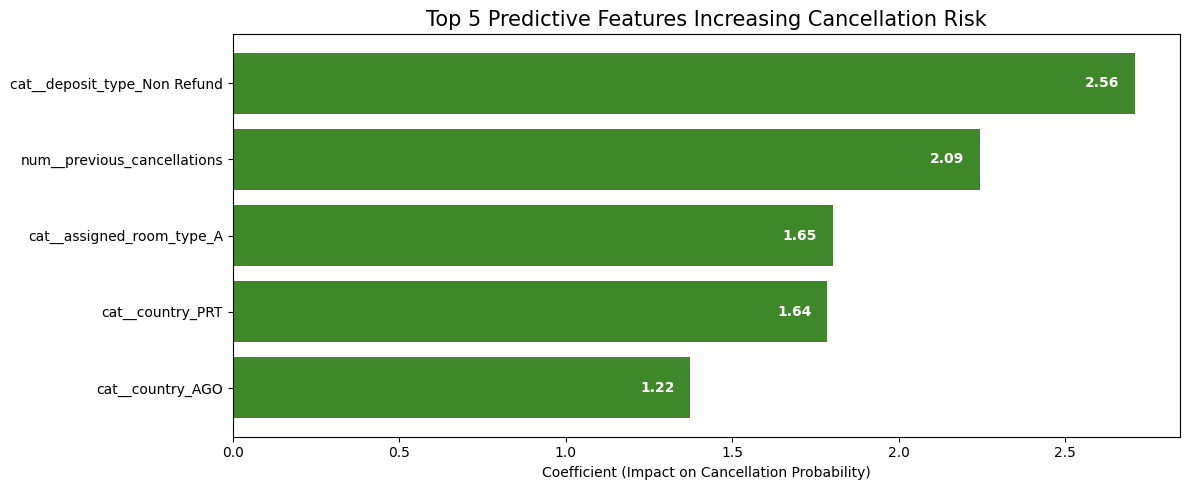

In [74]:
logreg = model.named_steps['classifier']
preprocessor = model.named_steps['preprocessor']

# Ambil nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out(X_train.columns)

# Ambil koefisien
coefficients = logreg.coef_[0]

# Buat DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Filter fitur dengan koefisien positif
positive_features = feature_importance[feature_importance["Coefficient"] > 0]

# Ambil Top 5 terbesar
top5_cancel = positive_features.sort_values(
    by="Coefficient", ascending=False
).head(5)

# Hitung Odds Ratio
top5_cancel["Odds_Ratio"] = np.exp(top5_cancel["Coefficient"])

# ========================
# Visualisasi Bar Chart
# ========================

plt.figure(figsize=(12,5))
bars = plt.barh(top5_cancel["Feature"], top5_cancel["Coefficient"], color='#3F8829')

plt.xlabel("Coefficient (Impact on Cancellation Probability)")
plt.title("Top 5 Predictive Features Increasing Cancellation Risk", fontsize=15)
plt.gca().invert_yaxis()

# Tambahkan label nilai koefisien
for bar in bars:
    width = bar.get_width() - 0.15
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

In [75]:
top5_cancel

,Feature,Coefficient,Odds_Ratio
239,cat__deposit_type_Non Refund,2.709649,15.023999
10,num__previous_cancellations,2.243909,9.430120
226,cat__assigned_room_type_A,1.802217,6.063075
163,cat__country_PRT,1.785667,5.963554
39,cat__country_AGO,1.374429,3.952818


**Interpretasi Top 5 Predictive Drivers of Cancellation**

| Feature                        | Coefficient | Interpretasi                                                                                                                                                                                                                                                                                                                     |
| ------------------------------ | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `cat__deposit_type_Non Refund` | 2.71        | Booking dengan deposit **Non-Refund** memiliki risiko cancel sangat tinggi (Odds Ratio ≈ 15x lebih besar dibanding kategori referensi). Ini kontra-intuitif dan mengindikasikan kemungkinan adanya segmentasi tamu tertentu yang tetap membatalkan meskipun deposit hangus. Perlu evaluasi kebijakan deposit dan profiling tamu. |
| `num__previous_cancellations`  | 2.24        | Riwayat pernah membatalkan sebelumnya adalah prediktor sangat kuat (≈ 9.4x lebih berisiko). Pola perilaku historis terbukti menjadi indikator utama risiko cancel di masa depan.                                                                                                                                                 |
| `cat__assigned_room_type_A`    | 1.80        | Tamu yang mendapat tipe kamar A memiliki risiko cancel ≈ 6x lebih tinggi dibanding tipe referensi. Bisa berkaitan dengan fleksibilitas, harga, atau profil tamu tertentu pada tipe kamar ini.                                                                                                                                    |
| `cat__country_PRT`             | 1.79        | Tamu dari Portugal memiliki risiko cancel ≈ 6x lebih tinggi. Mengindikasikan pola perilaku berbasis geografis yang signifikan secara prediktif.                                                                                                                                                                                  |
| `cat__country_AGO`             | 1.37        | Tamu dari Angola memiliki risiko cancel ≈ 4x lebih tinggi dibanding referensi. Segmentasi negara menjadi faktor penting dalam risk modeling.                                                                                                                                                                                     |

- Deposit Type (Non Refund) adalah driver paling kuat: Ini temuan kritikal karena secara teori deposit non-refundable seharusnya menurunkan cancelation. Perlu investigasi lebih lanjut (pricing strategy, market segment, atau korelasi tersembunyi).
- Previous Cancellations adalah faktor perilaku paling konsisten: Customer dengan riwayat cancel merupakan segmen risiko tinggi dan layak dimonitor secara khusus.
- Room Type & Country menunjukkan pola segmentasi yang jelas: Risiko tidak hanya berasal dari perilaku historis, tetapi juga karakteristik demografis dan produk.

**Strategi Bisnis:**
1. *Target Segmen Risiko Tinggi*
    - Booking dengan Non-Refund Deposit
    - Customer dengan riwayat cancel
    - Tamu dari Portugal dan Angola
    - Booking dengan assigned_room_type_A
2. *Intervensi Preventif*
    - Reminder H-7 / H-3 sebelum check-in
    - Personalized confirmation outreach
    - Dynamic overbooking buffer berdasarkan risk score
    - Review ulang kebijakan deposit
3. Efisiensi Operasional, untuk forecasting cancelation, sehingga manajemen inventaris kamar lebih optimal, seperti:
    - Forecast cancellation rate lebih presisi
    - Optimasi inventory kamar
    - Pengaturan strategi overbooking berbasis risiko

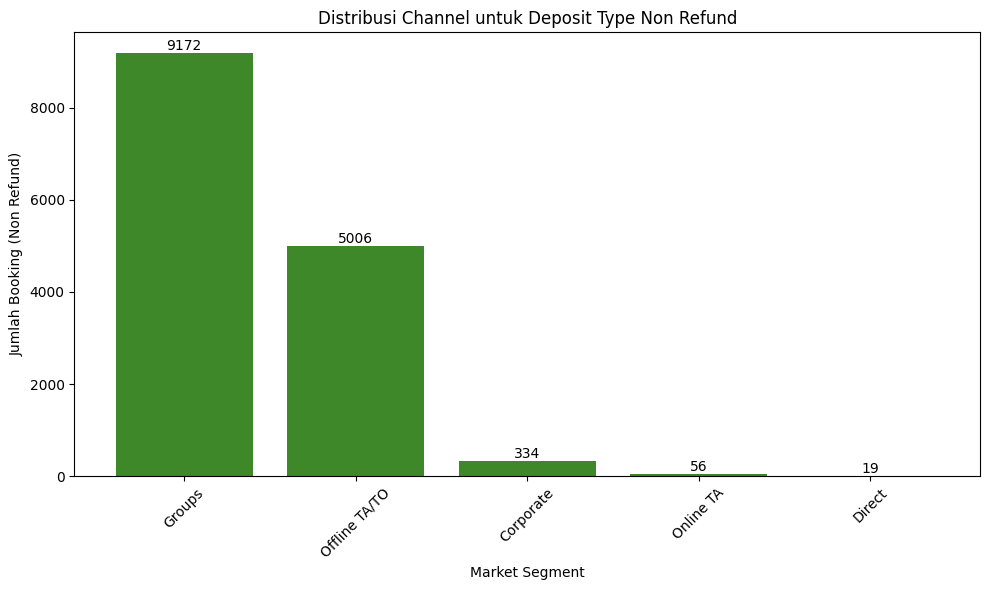

In [76]:
# Filter hanya untuk deposit_type Non Refund
non_refund_df = df[df['deposit_type'] == 'Non Refund']

# Hitung jumlah booking per market segment
channel_counts = non_refund_df['market_segment'].value_counts()

# Hitung jumlah booking per market segment
channel_counts = non_refund_df['market_segment'].value_counts()
total_non_refund = channel_counts.sum()

# Hitung persentase
channel_percent = channel_counts / total_non_refund * 100

# Plot bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(channel_counts.index, channel_counts.values, color='#3F8829')

plt.xlabel("Market Segment")
plt.ylabel("Jumlah Booking (Non Refund)")
plt.title("Distribusi Channel untuk Deposit Type Non Refund")
plt.xticks(rotation=45)

# Tambahkan label jumlah di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [77]:
# Filter untuk deposit_type Non Refund
non_refund_df = df[df['deposit_type'] == 'Non Refund']

# Hitung jumlah booking per market segment
channel_counts = non_refund_df['market_segment'].value_counts()

# Hitung persentase
channel_percent = channel_counts / channel_counts.sum() * 100

# Tampilkan hasil
print("--- Channel to Canncellation (%) ---")
print(channel_percent.round(2))

--- Channel to Canncellation (%) ---
market_segment
Groups           62.88
Offline TA/TO    34.32
Corporate         2.29
Online TA         0.38
Direct            0.13
Name: count, dtype: float64


In [78]:
pd.crosstab(df['deposit_type'], df['market_segment'], normalize='index')

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
deposit_type,,,,,,,,
No Deposit,0.002265,0.0071,0.047371,0.120230,0.100429,0.183570,0.539014,0.000019
Non Refund,0.000000,0.0000,0.022897,0.001303,0.628779,0.343182,0.003839,0.000000
Refundable,0.000000,0.0000,0.024691,0.037037,0.802469,0.024691,0.111111,0.000000


**Berdasarkan data distribusi:**
- Deposit type Non Refund tinggi karena sebagian besar pemesan cancel meskipun deposit seharusnya tidak bisa dikembalikan. Ini menjelaskan mengapa fitur ini menjadi driver kuat untuk prediksi pembatalan.
- Segmen penyebab utama:
    - 62.88% dari Non Refund booking berasal dari **Groups**
    - 34.32% berasal dari **Offline TA/TO**.

> Kesimpulan singkat: Deposit Non Refund tinggi terutama didorong oleh pemesanan dari Groups dan Offline TA/TO, yang menunjukkan pelanggan dari segmen ini lebih cenderung membatalkan meski deposit hangus, sehingga menjadi faktor risiko pembatalan yang signifikan.

## ✅ Objective 3: Revenue Protection Analysis from Booking Cancellations

  - Expected Revenue Without Model ✅
  - Expected Revenue With Model ✅
  - Revenue Uplift % ✅

**Business Impact Metrics – Revenue at Risk and 20% Cancellation Recovery Impact Analysis (2015–2017)**
  - **Revenue Loss Reduction (%)** ✅
  - **Incremental Revenue Secured** ✅
  - **Occupancy Rate Improvement** ✅
  - **RevPAR Improvement** ✅
  - **Cancellation Rate Reduction (%)** ✅

*Note:* Karena ini mengukur apakah model benar-benar menghasilkan dampak finansial.

---

### *Executive Summary – Expected Revenue with/without Model & Revenue Uplift %*

In [79]:
# 1. Probabilitas cancel dari tuned model
y_proba_tuned = tuned_model.predict_proba(X_test)[:,1]

# 2. Gabungkan X_test + y_test + probabilitas cancel
data_test = X_test.copy()
data_test['is_canceled'] = y_test.values
data_test['predicted_cancel_prob'] = y_proba_tuned

# 3. Pastikan total_stay ada
data_test['total_stay'] = data_test['stays_in_weekend_nights'] + data_test['stays_in_week_nights']

# 4. Hitung revenue per booking
data_test['revenue'] = data_test['adr'] * data_test['total_stay']

# 5. Expected Revenue Without Model (rata-rata cancel rate global)
overall_cancel_rate = y.mean()  # dari dataset penuh
data_test['expected_revenue_no_model'] = data_test['revenue'] * (1 - overall_cancel_rate)

# 6. Expected Revenue With Model
data_test['expected_revenue_with_model'] = data_test['revenue'] * (1 - data_test['predicted_cancel_prob'])

# 7. Total Revenue
total_rev_no_model = data_test['expected_revenue_no_model'].sum()
total_rev_with_model = data_test['expected_revenue_with_model'].sum()

# 8. Revenue Uplift %
revenue_uplift_pct = (
    (total_rev_with_model - total_rev_no_model) 
    / total_rev_no_model
) * 100

# Hasil
print("Total Expected Revenue Without Model: €", round(total_rev_no_model,2))
print("Total Expected Revenue With Model: €", round(total_rev_with_model,2))
print("Revenue Uplift (%): ", round(revenue_uplift_pct,2), "%")

# Cek beberapa baris pertama
display(
    data_test[['adr','total_stay','revenue','is_canceled',
               'predicted_cancel_prob',
               'expected_revenue_no_model',
               'expected_revenue_with_model']].head(5)
)

Total Expected Revenue Without Model: € 8100156.38
Total Expected Revenue With Model: € 5869718.63
Revenue Uplift (%):  -27.54 %


,adr,total_stay,revenue,is_canceled,predicted_cancel_prob,expected_revenue_no_model,expected_revenue_with_model
55182,98.00,1,98.00,1,0.235126,61.699204,74.957683
67477,120.00,2,240.00,1,0.998494,151.100092,0.361358
39472,212.58,7,1488.06,0,0.962106,936.858346,56.389149
97473,96.88,7,678.16,0,0.403787,426.958494,404.327492
91290,139.00,2,278.00,0,0.098909,175.024273,250.503181


- Tottal Expected Revenue With Model lebih rendah 27.54% dibandingkan tanpa model.
- Penurunan ini menunjukkan bahwa model memberikan koreksi terhadap overestimation revenue dengan menggunakan probabilitas cancel individual, sehingga estimasi menjadi lebih realistis.

| Komponen                       | Sumber Data                             | Perbedaan                           |
| ------------------------------ | --------------------------------------- | ----------------------------------- |
| Expected Revenue Without Model | `Revenue × (1 - overall_cancel_rate)`   | Menggunakan rata-rata global        |
| Expected Revenue With Model    | `Revenue × (1 - predicted_cancel_prob)` | Menggunakan probabilitas individual |


Perbandingan ini fair comparison karena:
- Basis booking sama
- Periode sama
- Observasi sama
- Hanya metode estimasi risiko yang berbeda

> *Jadi uplift yang muncul benar-benar mencerminkan dampak penggunaan model, bukan perbedaan data.*

**Berdasarkan display data:**
- Booking dengan predicted_cancel_prob ≥ 0.7 mengalami penurunan expected revenue signifikan.
- Tanpa model, revenue tetap dihitung tinggi, sehingga terdapat risiko overestimation.
- Dengan model, revenue menjadi risk-adjusted, mencerminkan potensi realisasi sebenarnya.

> *Model prediksi cancel meningkatkan akurasi forecasting pendapatan dan membantu manajemen hotel mengurangi bias optimisme dalam proyeksi revenue.*

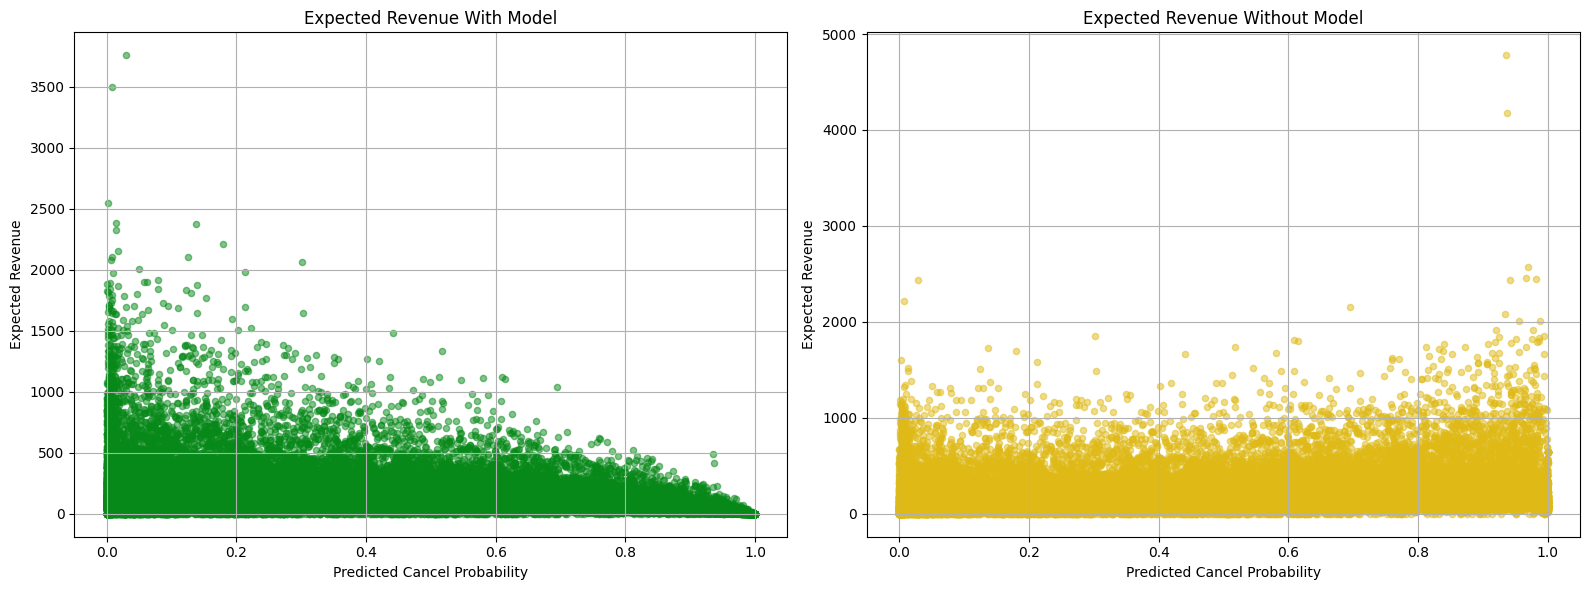

In [80]:
# Scatter plot Revenue Expected (Predictive)

plt.figure(figsize=(16,6))

# Scatter With Model
plt.subplot(1,2,1)
plt.scatter(data_test['predicted_cancel_prob'], data_test['expected_revenue_with_model'], 
            alpha=0.5, c="#078919", s=20)
plt.title('Expected Revenue With Model')
plt.xlabel('Predicted Cancel Probability')
plt.ylabel('Expected Revenue')
plt.grid(True)

# Scatter Without Model
plt.subplot(1,2,2)
plt.scatter(data_test['predicted_cancel_prob'], data_test['expected_revenue_no_model'], 
            alpha=0.5, c="#DFBA17", s=20)
plt.title('Expected Revenue Without Model')
plt.xlabel('Predicted Cancel Probability')
plt.ylabel('Expected Revenue')
plt.grid(True)

plt.tight_layout()
plt.show()

**Interpretasi Scatter Revenue Expected (Predicted Cancel Probability)**

| **Aspek**             | **With Model (Kiri)**                                                                                 | **Without Model (Kanan)**                                                                           |
| --------------------- | ----------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| **Bentuk Plot**       | Semakin tinggi peluang orang untuk batal ($P_{cancel} \to 1$), maka nilai ekspektasi uang yang masuk seharusnya mendekati nol. Grafik ini mengikuti rumus tersebut dengan sempurna. | Grafik ini menunjukkan sebaran data yang acak, ini menunjukkan bahwa nilai transaksi asli tidak berhubungan langsung dengan probabilitas pembatalan.               |
| **Akurasi Finansial** | Lebih realistis karena sudah memperhitungkan risiko pembatalan per booking.                           | Cenderung berbahaya karena terlalu optimis dan tidak mempertimbangkan risiko cancel.                |
| **Bentuk Data**       | Terorganisir dengan pola korelasi negatif yang jelas antara probabilitas cancel dan expected revenue. | Sebaran acak (random/uniform) tanpa hubungan jelas antara probabilitas cancel dan estimasi revenue. |
| **Kegunaan Bisnis**   | Dapat digunakan untuk prioritas strategi retention dan manajemen risiko revenue.                      | Hanya merepresentasikan nilai kontrak kotor tanpa insight risiko.                                   |

- > Model cancel prediction mengubah revenue forecasting dari static estimation menjadi probabilistic risk-adjusted forecasting.
    - Tanpa model → bisnis menghitung gross contract value.
    - Dengan model → bisnis menghitung expected realized revenue.

**Business Insight**

1. **With Model (Risk-Adjusted Revenue)**
- Revenue forecast menjadi **risk-adjusted**, bukan sekadar contract value.
- Booking high ADR dengan risiko tinggi tidak lagi dianggap sebagai kontribusi penuh.
- **Business Impact:**
  - Forecasting yang lebih realistis
  - Strategi overbooking berbasis risiko
  - Prioritisasi retention untuk high-value & low-risk guests

> *Key Insight: Pola yang terlihat “rapi” mencerminkan konsistensi penerapan model dalam revenue estimation, bukan kelemahan analisis.*

2. **Without Model (Historical Average Approach)**
- Semua booking diasumsikan memiliki risiko cancel yang sama (historical average).
- Tidak ada hubungan antara cancel probability dan expected revenue.
- Forecast cenderung **optimistic bias**.
- Booking berisiko tinggi tetap dihitung hampir penuh.
- Risiko yang muncul:
**Business Impact:**
  - Overestimation revenue
  - Budgeting tidak akurat
  - Strategi alokasi kamar kurang optimal

### *Executive Summary – Revenue at Risk and Cancellation Recovery Impact Analysis (2015–2017)*

In [81]:
# 1. Reconstruct arrival_date
data_test['arrival_date'] = pd.to_datetime(
    data_test['arrival_date_year'].astype(str) + '-' +
    data_test['arrival_date_month'] + '-' +
    data_test['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

min_date = data_test['arrival_date'].min()
max_date = data_test['arrival_date'].max()
total_days = (max_date - min_date).days + 1


# 2. Available Room Nights
rooms_per_hotel = {
    "Resort Hotel": 400,
    "City Hotel": 300
}

total_available_room_nights = 0

for h, rooms in rooms_per_hotel.items():
    total_available_room_nights += rooms * total_days

recovery_rate = 0.20

print("Data Period:", min_date.date(), "to", max_date.date())
print("Total Days:", total_days)
print("Total Available Room Nights:", total_available_room_nights)
print()


# 3. LOST REVENUE DARI CANCELLATION
data_test['potential_revenue'] = data_test['total_stay'] * data_test['adr']

lost_revenue = data_test.loc[
    data_test['is_canceled'] == 1,
    'potential_revenue'
].sum()

incremental_revenue = lost_revenue * recovery_rate


# 4. OCCUPANCY
room_nights_sold_actual = data_test.loc[
    data_test['is_canceled'] == 0,
    'total_stay'
].sum()

room_nights_canceled = data_test.loc[
    data_test['is_canceled'] == 1,
    'total_stay'
].sum()

occupancy_before = room_nights_sold_actual / total_available_room_nights

recovered_room_nights = room_nights_canceled * recovery_rate

occupancy_after = (
    room_nights_sold_actual + recovered_room_nights
) / total_available_room_nights

occupancy_uplift_pct = (
    (occupancy_after - occupancy_before) / occupancy_before
) * 100


# 5. REVPAR
actual_revenue = data_test['revenue'].sum()

revpar_before = actual_revenue / total_available_room_nights
revpar_after = (actual_revenue + incremental_revenue) / total_available_room_nights

revpar_uplift_pct = (
    (revpar_after - revpar_before) / revpar_before
) * 100


# 6. CANCELLATION RATE (SIMULASI)
cancel_rate_before = data_test['is_canceled'].mean()
cancel_rate_after = cancel_rate_before * (1 - recovery_rate)
cancel_reduction_pct = (
    (cancel_rate_before - cancel_rate_after) / cancel_rate_before
) * 100


# OUTPUT
print("===== Revenue at Risk and 20% Cancellation Recovery Impact Analysis (2015–2017) =====")
print("Lost Revenue from Cancellation (€):", round(lost_revenue,2))
print("Incremental Revenue Secured (€):", round(incremental_revenue,2))
print()

print("Occupancy Before (%):", round(occupancy_before*100,2))
print("Occupancy After (%):", round(occupancy_after*100,2))
print("Occupancy Uplift (%):", round(occupancy_uplift_pct,2))
print()

print("RevPAR Before (€):", round(revpar_before,2))
print("RevPAR After (€):", round(revpar_after,2))
print("RevPAR Uplift (%):", round(revpar_uplift_pct,2))
print()

print("Cancellation Rate Before (%):", round(cancel_rate_before*100,2))
print("Cancellation Rate After (%):", round(cancel_rate_after*100,2))
print("Cancellation Reduction (%):", round(cancel_reduction_pct,2))

Data Period: 2015-07-01 to 2017-08-31
Total Days: 793
Total Available Room Nights: 555100

===== Revenue at Risk and 20% Cancellation Recovery Impact Analysis (2015–2017) =====
Lost Revenue from Cancellation (€): 5008807.78
Incremental Revenue Secured (€): 1001761.56

Occupancy Before (%): 13.85
Occupancy After (%): 15.51
Occupancy Uplift (%): 11.98

RevPAR Before (€): 23.18
RevPAR After (€): 24.98
RevPAR Uplift (%): 7.79

Cancellation Rate Before (%): 37.04
Cancellation Rate After (%): 29.63
Cancellation Reduction (%): 20.0


**Interpretasi Executive:**
Selama periode 2015–2017:
- Total Lost Revenue akibat pembatalan: €5.01M
- Dengan strategi 20% recovery, hotel berhasil mengamankan tambahan ±€1.00M
- Occupancy meningkat dari 13.85% menjadi 15.51% → uplift 11.98%
- RevPAR meningkat dari €23.18 menjadi €24.98 → uplift 7.79%
- Cancellation Rate menurun dari 37.04% menjadi 29.63% → penurunan 20%

> *Strategi mitigasi pembatalan yang efektif dapat meningkatkan pendapatan, mengoptimalkan okupansi, dan memperbaiki performa RevPAR secara signifikan.*

**Perhitungan Uplift**

Kamu bisa tulis ulang rumus uplift dalam format LaTeX Python-friendly atau Markdown lebih rapi seperti ini:

$$
\text{Uplift (\%)} = \frac{\text{After} - \text{Before}}{\text{Before}} \times 100
$$

Occupancy:
-  Before = 13.85
-  After = 15.51

$$
\text{Uplift} = \frac{15.51 - 13.85}{13.85} \times 100
= \frac{1.66}{13.85} \times 100
\approx 11.98%
$$

---
# **Business Insight & Strategic Recommendation – Hotel Booking Cancellation Prediction**
---

## **1. Conclusion With or Without Model**

| Aspek                            | Tanpa Model                                                                    | Dengan Model                                                                                |
| -------------------------------- | ------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------- |
| **Deteksi Pembatalan**           | Intervensi bersifat umum → tidak spesifik per booking → banyak cancel terlewat | Prediksi probabilitas cancel per booking → hampir semua high-risk terdeteksi (Recall 0.935) |
| **Strategi Intervensi**          | Sama untuk semua booking → deposit & reminder seragam                          | Deposit/prepayment selektif → hanya untuk high-risk, efisien & tidak mengganggu low-risk    |
| **Revenue Protection**           | Occupancy rendah → 13.85%, RevPAR €23.18                                       | Occupancy naik → 15.51% (+11.98%), RevPAR €24.98 (+7.79%)                                   |
| **Cancellation Rate**            | 37.04% → banyak lost revenue & kamar kosong                                    | 29.63% → berkurang 20%, efisiensi operasional meningkat                                     |
| **Operational Efficiency**       | Overbooking & alokasi kamar kurang optimal                                     | Overbooking berbasis probabilitas cancel → kapasitas dimanfaatkan optimal                   |
| **Strategi Marketing & Pricing** | Uniform, tidak ada segmentasi risiko                                           | Dynamic pricing & channel optimization berdasarkan risiko → ROI lebih tinggi                |

- > Tanpa model → strategi general → revenue loss tinggi.
- > Dengan model → intervensi tepat sasaran → revenue terlindungi, efisiensi operasional meningkat, pengalaman low-risk tetap optimal.

## **2. Strategic Recommendations**

**A. Implement Risk-Based Prepayment & Deposit**
- Terapkan deposit/prepayment untuk booking probabilitas cancel tinggi (≥0.4–0.6).
- Reminder otomatis untuk meningkatkan kepatuhan pelanggan.

**B. Dynamic Pricing & Segmentation**
- Sesuaikan harga: premium untuk high-risk saat room availability tinggi, diskon untuk low-risk.
- Optimalkan alokasi kamar dan overbooking berbasis probabilitas cancel.

**C. Optimasi Marketing & Channel**
- Fokus promosi untuk channel low-risk → ROI marketing meningkat.
- High-risk channel → tawarkan insentif cancel protection untuk mengurangi dampak cancel.

**D. Operational Efficiency**
- Monitor probabilitas cancel secara real-time → sesuaikan staffing, housekeeping, dan alokasi kamar.

**E. Data-Driven Culture**
- Gunakan probabilitas cancel untuk mendukung keputusan manajerial: pricing, allocation, marketing campaigns.
- Evaluasi model secara periodik → adaptasi terhadap tren musiman atau perilaku pelanggan baru.

## **3. Implementation of Cancellation Prediction Model**

**A. Workflow Implementasi**

1. Data Pipeline & Monitoring
    - Booking real-time → pre-processing → prediksi probabilitas cancel.
    - Integrasi dengan PMS & Channel Manager untuk update ketersediaan kamar.

2. Decision Engine
    - Threshold probabilitas cancel (misal ≥0.4 → high-risk).
    - Low-risk → intervensi minimal; High-risk → deposit, prepayment, reminder khusus, atau promo cancel protection.

3. Revenue & Operations Alignment
    - Probabilitas cancel digunakan untuk dynamic pricing & allocation kamar → optimalkan overbooking.
    - Koordinasi housekeeping & front office → mengurangi idle room akibat no-show.

4. Marketing & Customer Engagement
    - Channel low-risk → promosi/loyalty fokus.
    - Channel high-risk → insentif cancel protection.

5. Monitoring & Feedback Loop
    - Evaluasi KPI: recall, precision, uplift revenue, reduction cancel.
    - Update model sesuai pola cancel baru.

**B. Deployment Options**
    - Batch Prediction: Harian → strategi harian.
    - Real-Time Prediction: Saat booking → keputusan deposit/prepayment otomatis.
    - Tools: Python/scikit-learn untuk model, PMS/Booking Engine API untuk integrasi, Dashboard BI (Tableau / Power BI / Looker) untuk monitoring KPI.

# **Closing**

- **Value Business:** Intervensi berbasis probabilitas cancel mengubah strategi revenue management dari reactive → predictive, meningkatkan revenue & efisiensi operasional.
- **Customer Experience:** Low-risk guest tetap nyaman; high-risk guest ditangani selektif → mitigasi risiko revenue tanpa mengurangi konversi.
- **Continuous Improvement:** Tambahkan fitur baru seperti historical behavior, seasonal trends, channel-specific patterns untuk meningkatkan akurasi prediksi.

    > Dengan predictive model, hotel dapat mengubah strategi dari general → targeted, meningkatkan occupancy dan RevPAR, menurunkan cancellation rate, serta menjalankan intervensi selektif untuk melindungi revenue dan pengalaman pelanggan.

    > Integrasi model ke sistem booking & PMS memungkinkan decision-making real-time, sementara monitoring KPI memastikan strategi tetap efektif dan adaptif.

---

**Source Collectively:**
- Tableu: [Hotel Booking – Tableu](https://public.tableau.com/app/profile/muhammad.arief.munazat/viz/HotelBookingAnalysis_17720479259720/ExecutiveDashboard?publish=yes)
- Dataset Spreadsheet: [dataset_spreadsheet](https://docs.google.com/spreadsheets/d/1l8nidordotAE827Hxk3SPyhEnZ24liKXGCrRxm7ua0Q/edit?pli=1&gid=1259976032#gid=1259976032)